# Busy Airports: Predicting TSA Traffic at Major U.S. Airports

**Team members**: [David Friedenberg](https://github.com/friedenberg12), [Agniva Dasgupta](https://github.com/adg1016), [Charuhas Shiveshwarkar](https://github.com/SChars), [Ivan Caro Terrazas](https://github.com/icaromx), [Ahmad Shamloumehr](https://github.com/)

This notebook uses the TSA hourly passenger throughput dataset to build a machine learning workflow for short-term load forecasting.

## Workflow
1. Load and preprocess the dataset

## Pipeline overview

Raw data → Preprocessing → Train/Test Split → Model Training → Evaluation

## Models compared
- SARIMA
- Harmonic Regression
- STL decomposition

The goal is not only to obtain strong predictive performance, but also to keep the pipeline clear, modular, and reproducible.

## Imports

In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Import custom module from src/ directory
from busy_airports.preprocessing import load_data, retrieve_airport_data

## Data loading and preprocessing

The TSA dataset is loaded and column names are renamed to an easier way to parse them.

In [2]:
tsa_data = load_data("data/tsa-throughput-data-complete.csv")
print('Rows:', len(tsa_data), 'Columns:', tsa_data.shape[1])
mem = tsa_data.memory_usage(deep=True).sum() / (1024**2)
print(f'Memory MB: {mem:.2f}')
display(tsa_data.head(3))
display(tsa_data.tail(3))
display(tsa_data.describe(include='all').T)

Rows: 11054590 Columns: 10
Memory MB: 1658.81


,datetime,airport_code,airport_name,city,state,checkpoint,total_passenger_throughput,date,month,week
0,2022-01-01,ANC,Ted Stevens Anchorage International,Anchorage,AK,South Checkpoint,62,2022-01-01,1,52
1,2022-01-01,ATL,Hartsfield Atlanta International,Atlanta,GA,Main Checkpoint,17,2022-01-01,1,52
2,2022-01-01,BFL,"Meadows Field, Bakersfield",Bakersfield,CA,BFL01,0,2022-01-01,1,52


,datetime,airport_code,airport_name,city,state,checkpoint,total_passenger_throughput,date,month,week
11054587,2025-12-31 23:00:00,SMF,Sacramento International,Sacramento,CA,Central B,23,2025-12-31,12,1
11054588,2025-12-31 23:00:00,SMF,Sacramento International,Sacramento,CA,Terminal A,106,2025-12-31,12,1
11054589,2025-12-31 23:00:00,TPA,Tampa International,Tampa,FL,TPA A,28,2025-12-31,12,1


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
datetime,11054590,NaN,NaN,NaN,2024-01-07 05:16:40.525789,2022-01-01 00:00:00,2023-01-07 05:00:00,2024-01-09 19:00:00,2025-01-07 10:00:00,2025-12-31 23:00:00,NaN
airport_code,11054590,434,DFW,385638,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airport_name,11054590,688,Los Angeles International,317481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,11054590,422,Chicago,403015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,11054590,55,CA,1240223,NaN,NaN,NaN,NaN,NaN,NaN,NaN
checkpoint,11054590,544,Main Checkpoint,372359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_passenger_throughput,11054590.0,NaN,NaN,NaN,300.817651,0.0,49.0,173.0,416.0,4405.0,370.153141
date,11054590,1461,2025-07-10,8190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,11054590.0,NaN,NaN,NaN,6.53834,1.0,4.0,7.0,10.0,12.0,3.430813
week,11054590.0,NaN,NaN,NaN,26.544966,1.0,14.0,27.0,39.0,52.0,14.980496


Before working further with this dataset, we remove the holdout data until the very end

In [3]:
tsa_data_test = tsa_data[tsa_data['datetime'] >= '2025-07-01']
tsa_data_test.head()

,datetime,airport_code,airport_name,city,state,checkpoint,total_passenger_throughput,date,month,week
9636155,2025-07-01,ABQ,Albuquerque International Sunport,Albuquerque,NM,Checkpoint for A/B Gates,38,2025-07-01,7,27
9636156,2025-07-01,ANC,Ted Stevens Anchorage International,Anchorage,AK,South Checkpoint,117,2025-07-01,7,27
9636157,2025-07-01,ATL,Hartsfield - Jackson Atlanta International,Atlanta,GA,F Arrival Checkpoint,10,2025-07-01,7,27
9636158,2025-07-01,ATL,Hartsfield - Jackson Atlanta International,Atlanta,GA,Main Checkpoint,0,2025-07-01,7,27
9636159,2025-07-01,ATL,Hartsfield - Jackson Atlanta International,Atlanta,GA,New T North Checkpoint,76,2025-07-01,7,27


In [4]:
tsa_data = tsa_data[tsa_data['datetime'] <= '2025-06-30']


# Exploratory Data Analysis

## Time Series Plots

In [5]:
from busy_airports.eda import plot_airport_data

We start by plotting the airport data for a particular checkpoint in Chicago International Airport

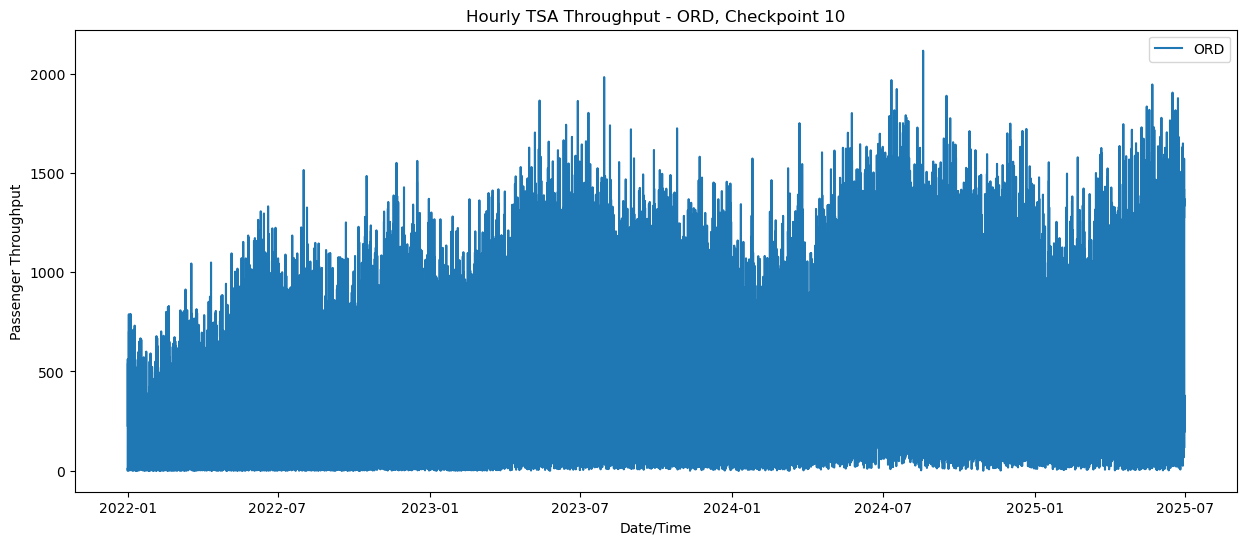

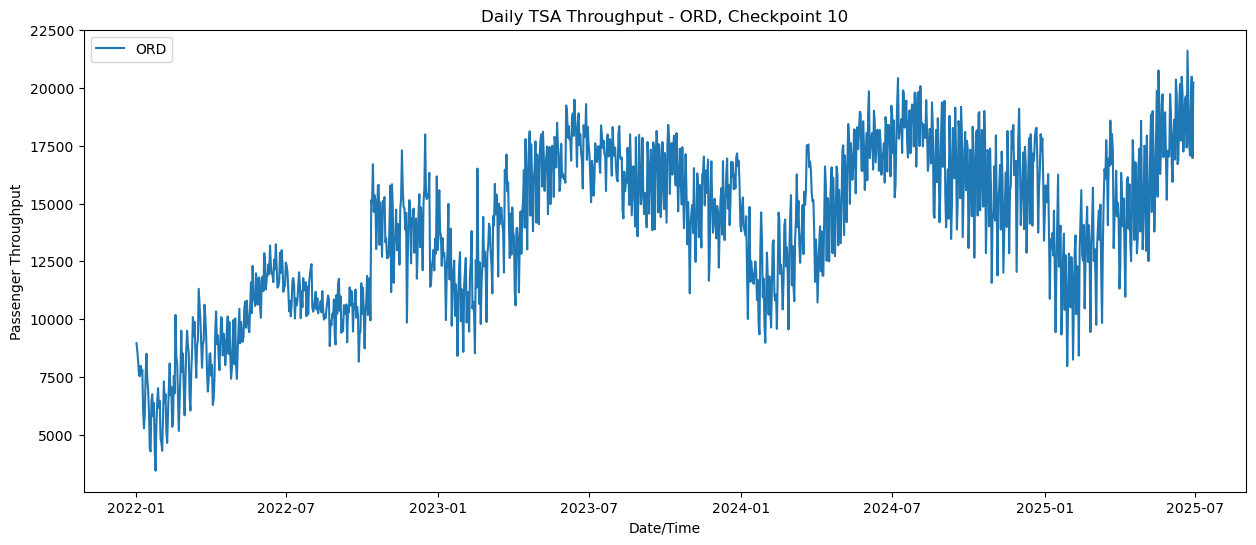

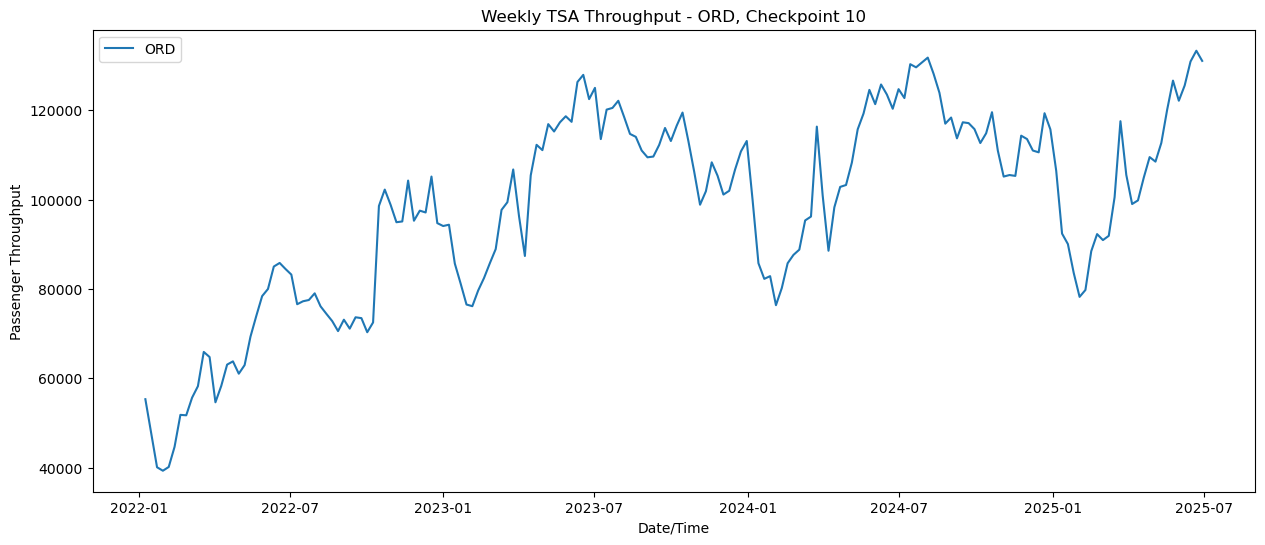

In [6]:
plot_airport_data(tsa_data, airport='ORD', frequency='H', checkpoint='10')
plot_airport_data(tsa_data, airport='ORD', frequency='D', checkpoint='10')
plot_airport_data(tsa_data, airport='ORD', frequency='W', checkpoint='10')

There are a few useful observations to make about this dataset. First of all, notice that the hourly data appears to be less useful than the daily and weekly data. Also notice that it is hard to observe a trend for the data from a single checkpoint, since this checkpoint may only be opened and closed during certain hours.

Next we can look at the airport as a whole:

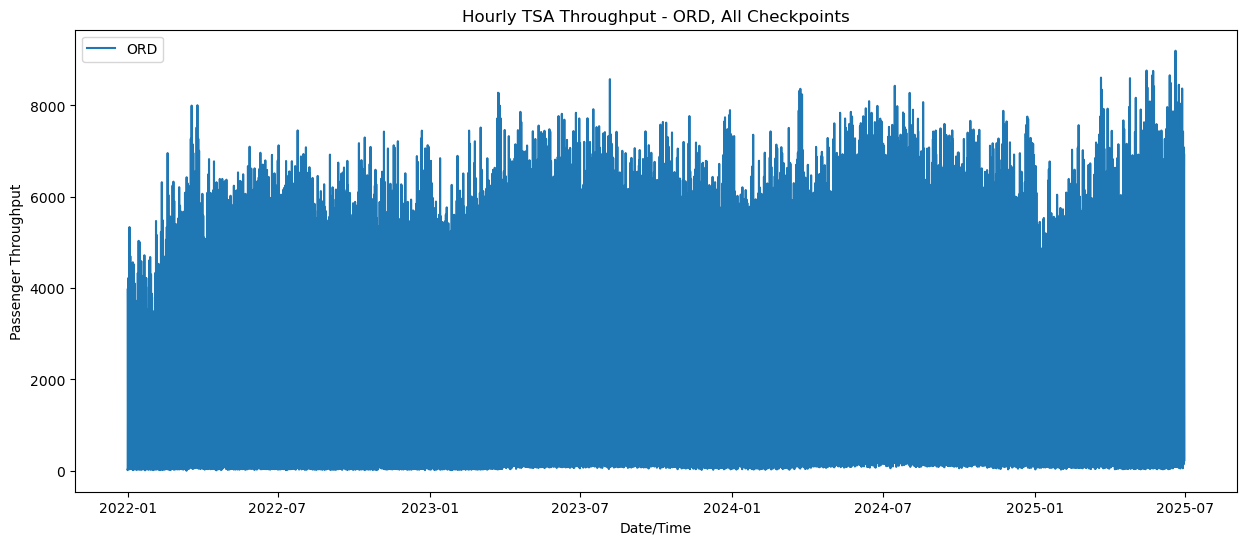

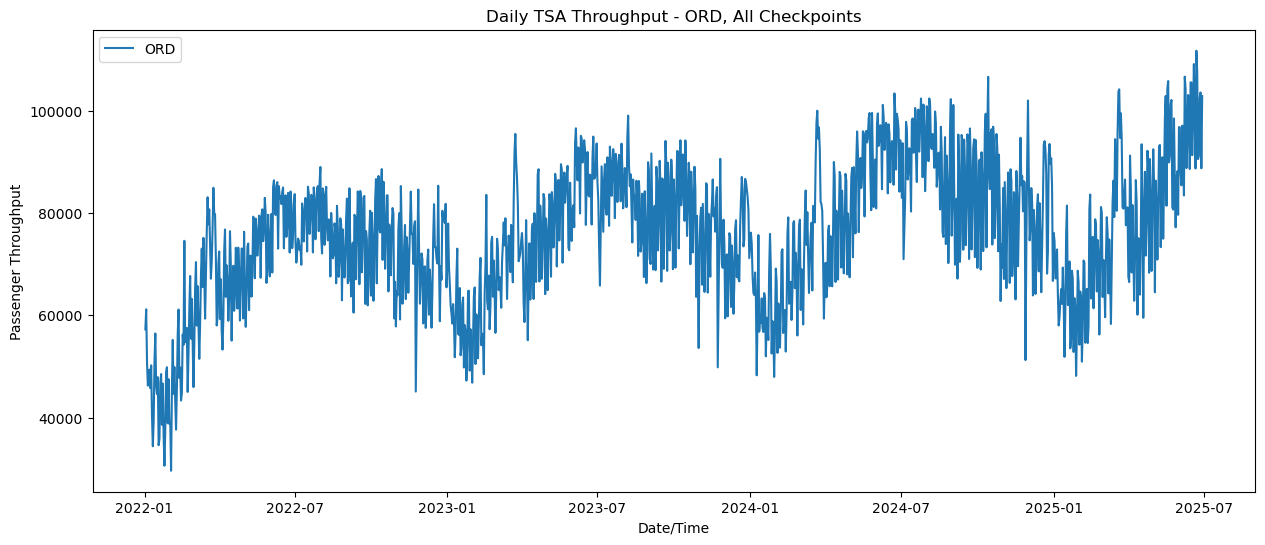

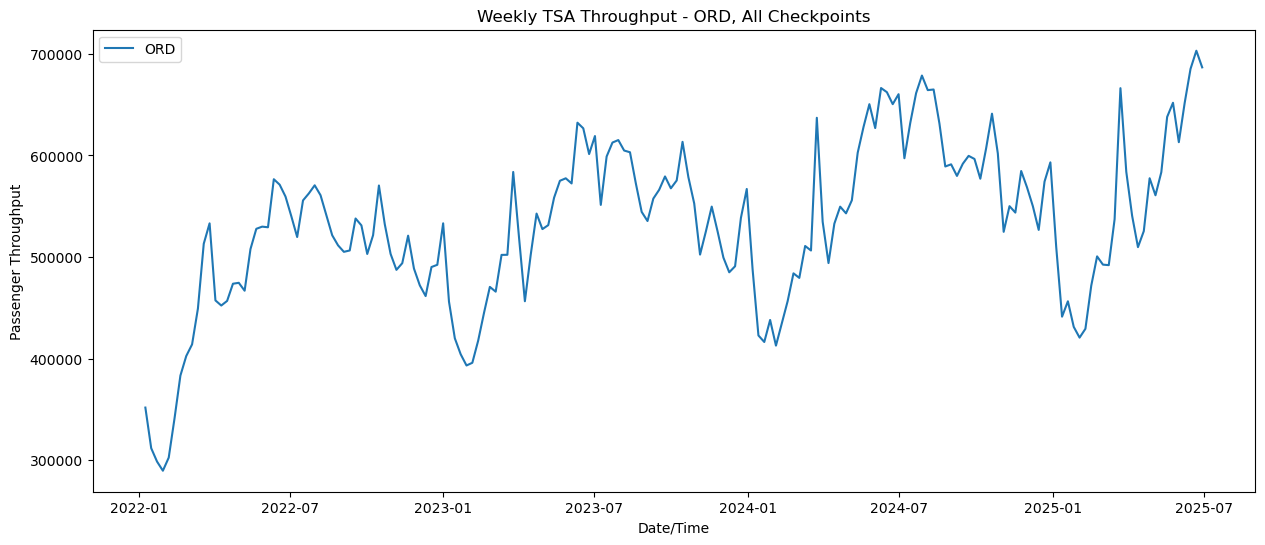

In [7]:
plot_airport_data(tsa_data, airport='ORD', frequency='H')
plot_airport_data(tsa_data, airport='ORD', frequency='D')
plot_airport_data(tsa_data, airport='ORD', frequency='W')

These plots clearly show that when considering all of the checkpoints, the throughput in an airport clearly shows annual seasonality and a linear trend. This can be further confirmed by looking at the autocorrelation and partial autocorrelation functions for the daily and weekly data.

We can also compare across multiple airports to verify that they carry the same trends.

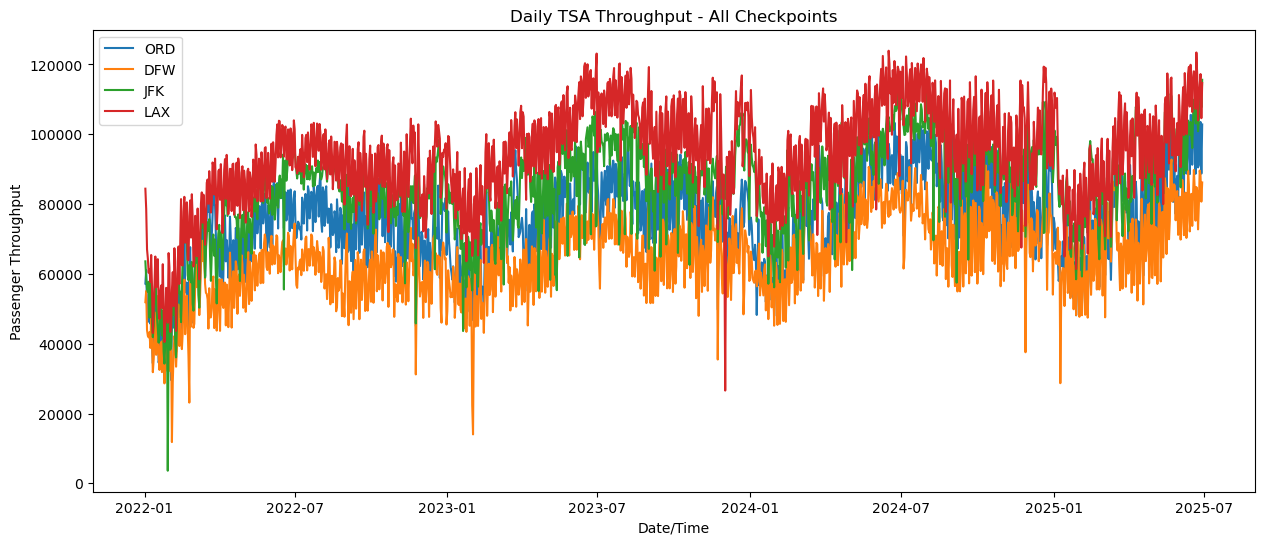

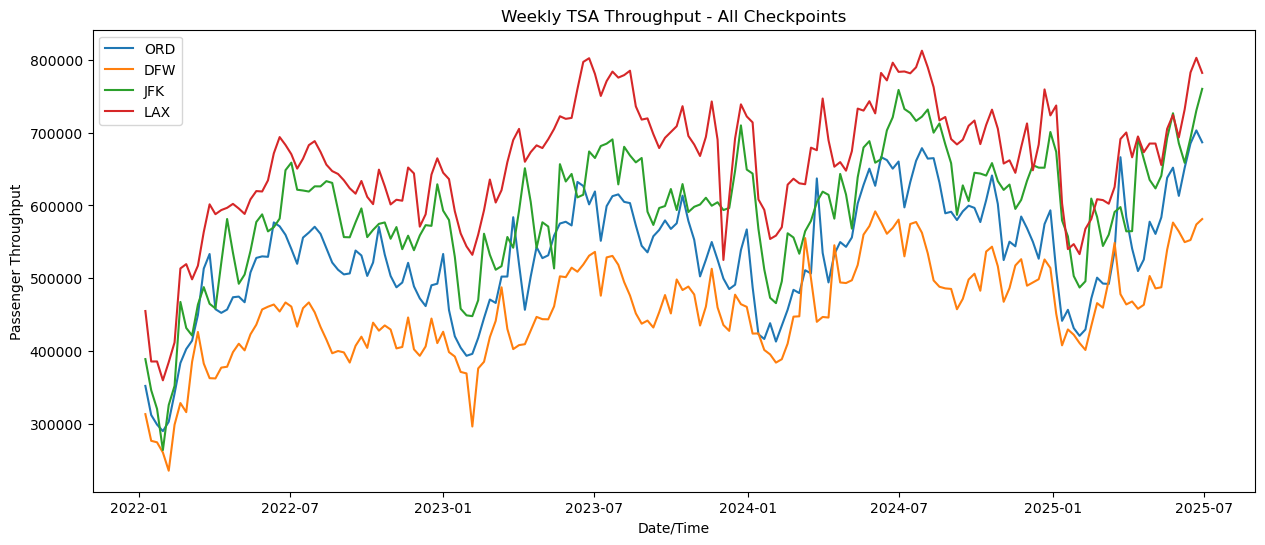

In [8]:
plot_airport_data(tsa_data, airport=['ORD','DFW','JFK','LAX'], frequency='D')
plot_airport_data(tsa_data, airport=['ORD','DFW','JFK','LAX'], frequency='W')

## ACF and PACF Plots

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [10]:
ord_daily = retrieve_airport_data(tsa_data, airport="ORD", frequency="D")
ord_weekly = retrieve_airport_data(tsa_data, airport="ORD", frequency="W")

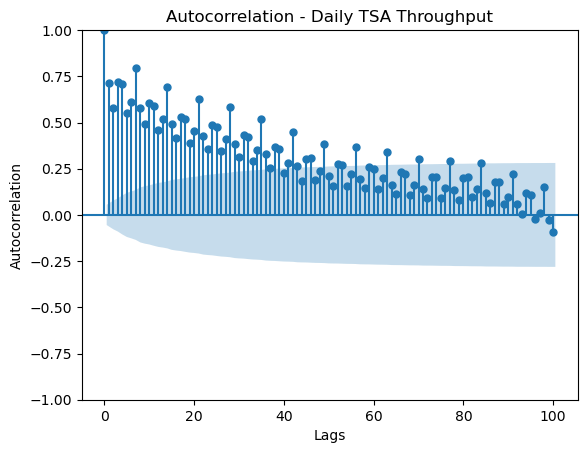

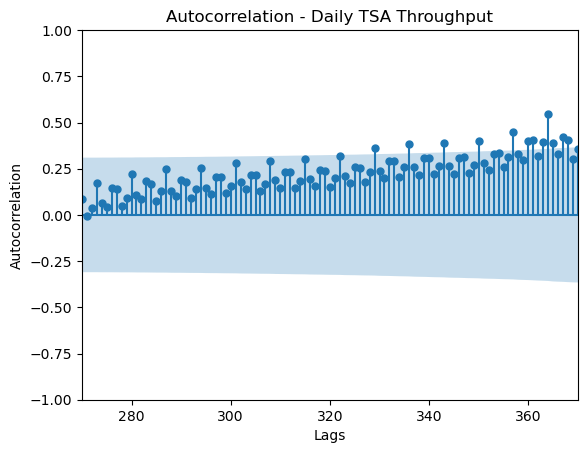

In [11]:
plot_acf(ord_daily.total_passenger_throughput, lags=100)
plt.title("Autocorrelation - Daily TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()
plot_acf(ord_daily.total_passenger_throughput, lags=370)
plt.title("Autocorrelation - Daily TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.xlim(270,370)
plt.show()

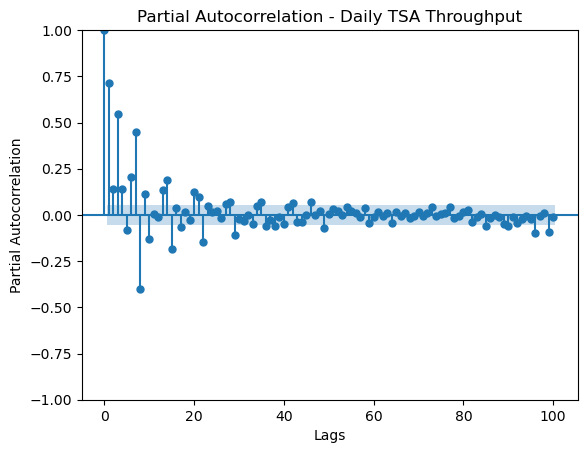

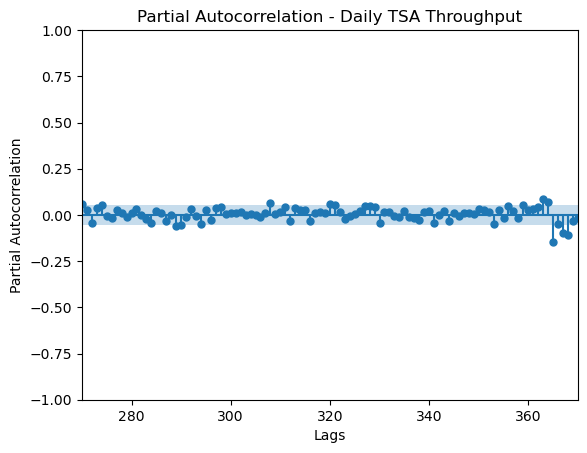

In [12]:
plot_pacf(ord_daily.total_passenger_throughput, lags=100)
plt.title("Partial Autocorrelation - Daily TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()
plot_pacf(ord_daily.total_passenger_throughput, lags=370)
plt.title("Partial Autocorrelation - Daily TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.xlim(270,370)
plt.show()

Here note from the autocorrelation that there is a large spike at every 7 lags and another large spike after 365 lags. This indicates both a weekly and annual seasonality in the daily data.

We can also look at the ACF and PACF for the weekly data.

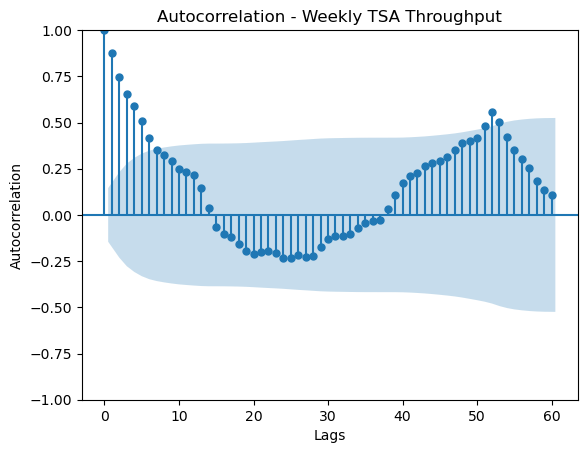

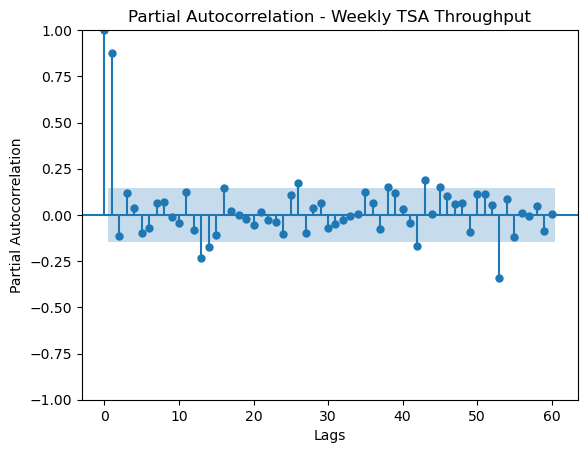

In [13]:
plot_acf(ord_weekly.total_passenger_throughput, lags=60)
plt.title("Autocorrelation - Weekly TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()
plot_pacf(ord_weekly.total_passenger_throughput, lags=60)
plt.title("Partial Autocorrelation - Weekly TSA Throughput")
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.show()

Here we observe that the dominant lags are the small lags (below about 5-6) and again there is annual seasonality indicated by a spike at lag 52.

Even though these models are clearly note stationary, we can model the seasonailty using either STL decomposition or SARIMA model, leaving the remaining residuals to be approximately stationary.

## Baseline Models

For our baseline models, we chose to use the Naive Seasonal Model with Drift and the Triple Exponential Smoothing model. These are simple enough models that are able to capture the annual seasonality and overall trend that we see in the throughput data.

In [14]:
from busy_airports.baselines import NaiveSeasonalWithDrift, TripleExponentialSmoothing
from busy_airports.metrics import evaluate_forecast

As a simple test of these models, we will create a train-test split with the last six months of data used to test the baseline models.

In [15]:
# daily train-test split
ord_daily_train = ord_daily[ord_daily['datetime'] < "2025-01-01"]
ord_daily_test  = ord_daily[ord_daily['datetime'] >= "2025-01-01"]
# weekly train-test split
ord_weekly_train = ord_weekly[ord_weekly['datetime'] < "2025-01-01"]
ord_weekly_test  = ord_weekly[ord_weekly['datetime'] >= "2025-01-01"]


Naive Seasonal with Drift:
  MAE: 11,626
  MAPE: 14.64%
  RMSE: 14,035


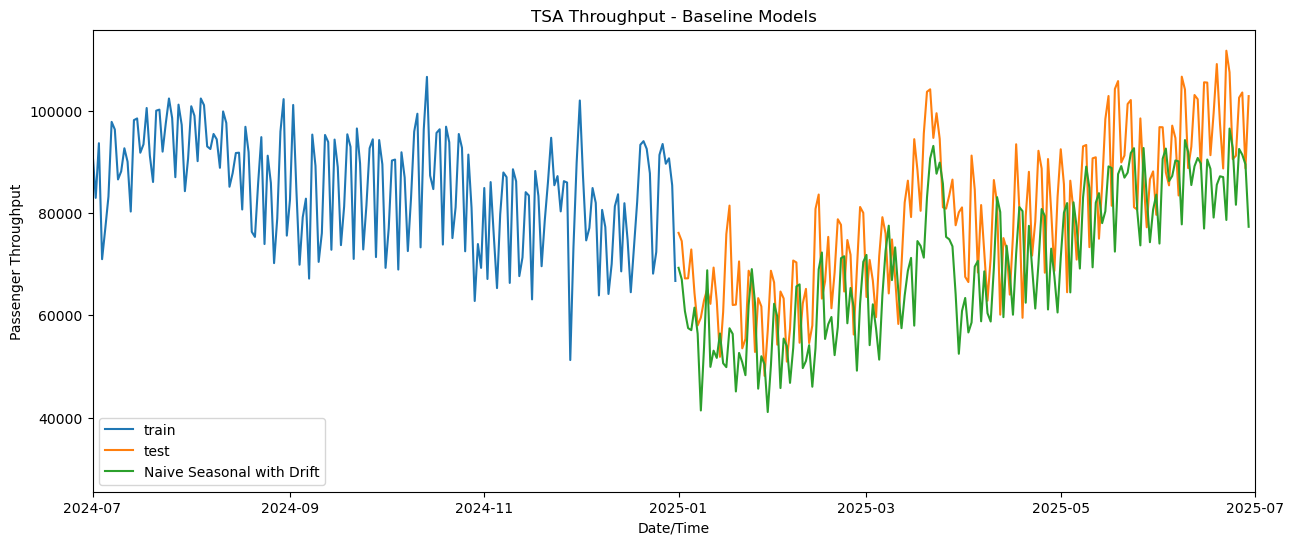

In [16]:
# Apply the Naive Seasonal model with Drift to the daily data and calculate metrics
nswd_model = NaiveSeasonalWithDrift(season_length=365)
nswd_model.fit(ord_daily_train.total_passenger_throughput)
nswd_forecast = nswd_model.forecast(h=len(ord_daily_test))
nswd_metrics = evaluate_forecast(ord_daily_test.total_passenger_throughput,
                                 nswd_forecast,
                                 "Naive Seasonal with Drift")
# Print metrics
print(f"\nNaive Seasonal with Drift:")
print(f"  MAE: {nswd_metrics['mae']:,.0f}")
print(f"  MAPE: {nswd_metrics['mape']*100:.2f}%")
print(f"  RMSE: {nswd_metrics['rmse']:,.0f}")
# Plot results
plt.figure(figsize=(15, 6))
plt.plot(ord_daily_train.datetime, ord_daily_train.total_passenger_throughput, label="train")
plt.plot(ord_daily_test.datetime, ord_daily_test.total_passenger_throughput, label="test")
plt.plot(ord_daily_test.datetime, nswd_forecast, label="Naive Seasonal with Drift")
plt.title("TSA Throughput - Baseline Models")
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.xlim(pd.Timestamp("2024-07-01"), pd.Timestamp("2025-07-01"))
plt.legend()
plt.show()


Triple Exponential Smoothing:
  MAE: 9,070
  MAPE: 12.31%
  RMSE: 11,372


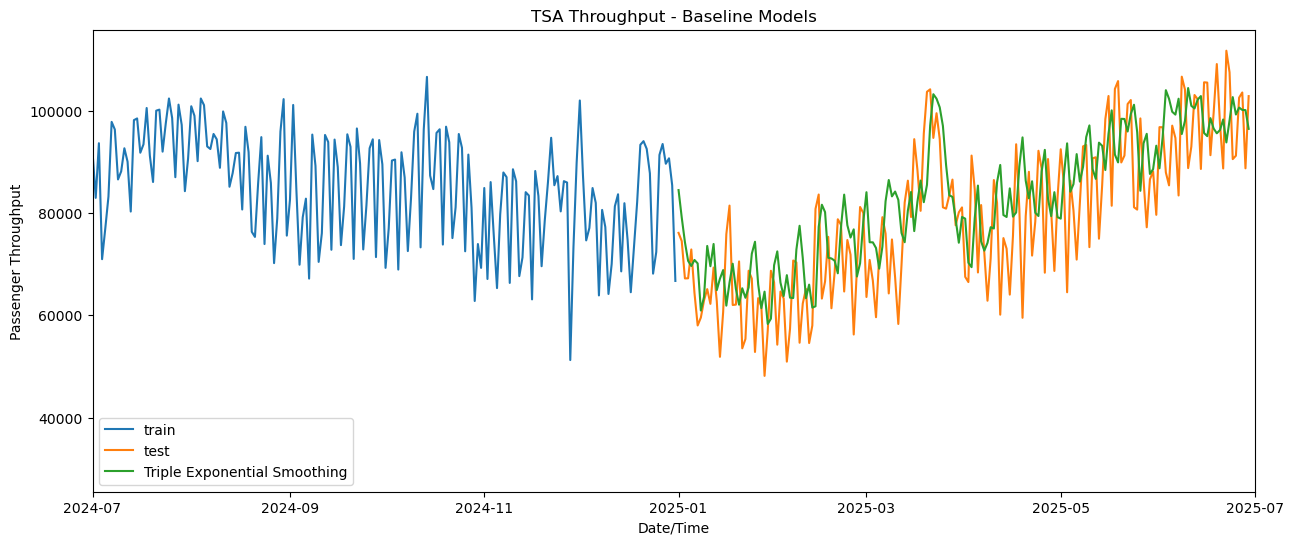

In [17]:
# Apply the Triple Exponential smoothing model to the daily data and calculate metrics
exps_model = TripleExponentialSmoothing(season_length=365)
exps_model.fit(ord_daily_train.total_passenger_throughput)
exps_forecast = exps_model.forecast(h=len(ord_daily_test))
exps_metrics = evaluate_forecast(ord_daily_test.total_passenger_throughput,
                                 exps_forecast,
                                 "Triple Exponential Smoothing")
# Print metrics
print(f"\nTriple Exponential Smoothing:")
print(f"  MAE: {exps_metrics['mae']:,.0f}")
print(f"  MAPE: {exps_metrics['mape']*100:.2f}%")
print(f"  RMSE: {exps_metrics['rmse']:,.0f}")
# Plot results
plt.figure(figsize=(15, 6))
plt.plot(ord_daily_train.datetime, ord_daily_train.total_passenger_throughput, label="train")
plt.plot(ord_daily_test.datetime, ord_daily_test.total_passenger_throughput, label="test")
plt.plot(ord_daily_test.datetime, exps_forecast, label="Triple Exponential Smoothing")
plt.title("TSA Throughput - Baseline Models")
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.xlim(pd.Timestamp("2024-07-01"), pd.Timestamp("2025-07-01"))
plt.legend()
plt.show()

It looks like the Triple Exponential model did slightly better on this testing set. This is the model that our custom model will need to beat.

Next let's repeat this process with the weekly throughput data.


Naive Seasonal with Drift:
  MAE: 21,719
  MAPE: 4.06%
  RMSE: 26,658


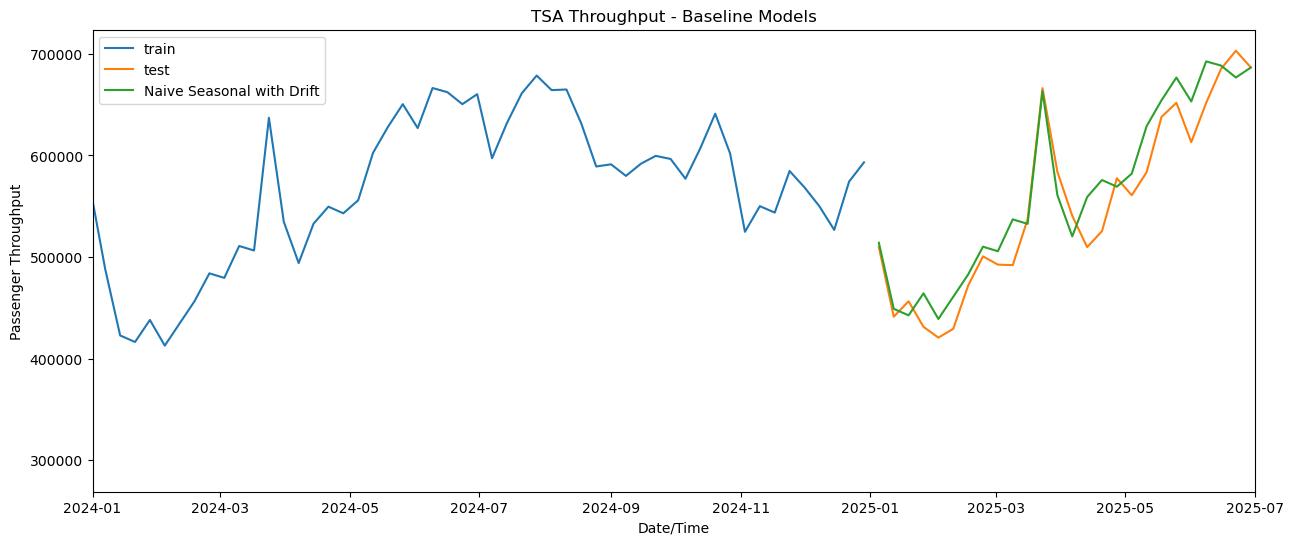

In [18]:
# Apply the Naive Seasonal model with Drift to the weekly data and calculate metrics
nswd_model = NaiveSeasonalWithDrift(season_length=52)
nswd_model.fit(ord_weekly_train.total_passenger_throughput)
nswd_forecast = nswd_model.forecast(h=len(ord_weekly_test))
nswd_metrics = evaluate_forecast(ord_weekly_test.total_passenger_throughput,
                                 nswd_forecast,
                                 "Naive Seasonal with Drift")
# Print metrics
print(f"\nNaive Seasonal with Drift:")
print(f"  MAE: {nswd_metrics['mae']:,.0f}")
print(f"  MAPE: {nswd_metrics['mape']*100:.2f}%")
print(f"  RMSE: {nswd_metrics['rmse']:,.0f}")
# Plot results
plt.figure(figsize=(15, 6))
plt.plot(ord_weekly_train.datetime, ord_weekly_train.total_passenger_throughput, label="train")
plt.plot(ord_weekly_test.datetime, ord_weekly_test.total_passenger_throughput, label="test")
plt.plot(ord_weekly_test.datetime, nswd_forecast, label="Naive Seasonal with Drift")
plt.title("TSA Throughput - Baseline Models")
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-07-01"))
plt.legend()
plt.show()


Triple Exponential Smoothing:
  MAE: 26,783
  MAPE: 5.15%
  RMSE: 32,443


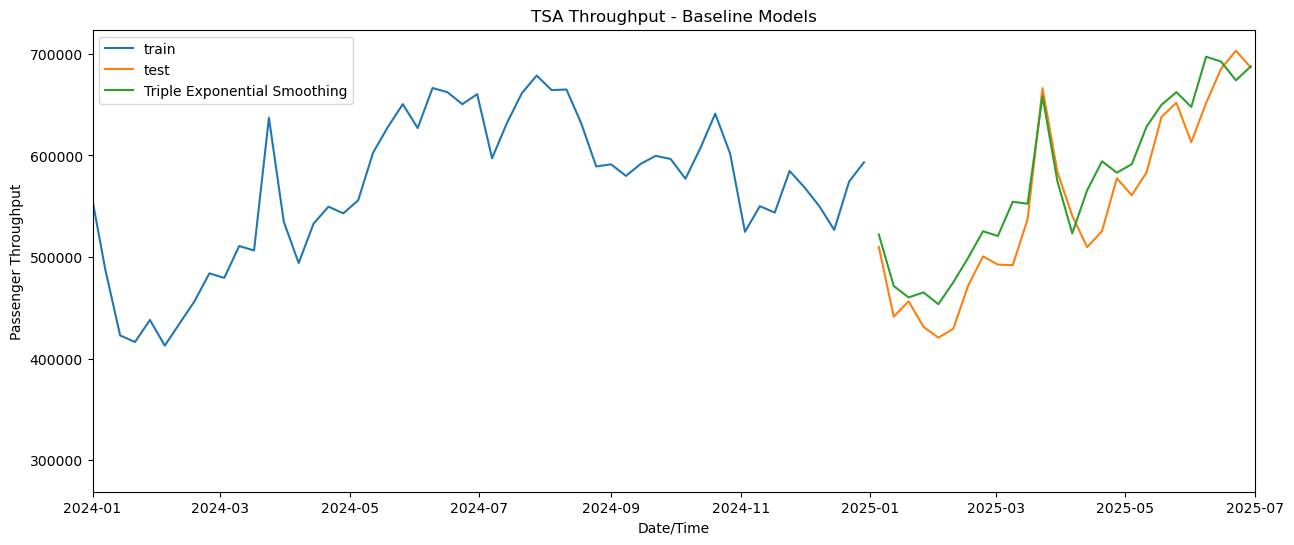

In [19]:
# Apply the Triple Exponential smoothing model to the daily data and calculate metrics
exps_model = TripleExponentialSmoothing(season_length=52)
exps_model.fit(ord_weekly_train.total_passenger_throughput)
exps_forecast = exps_model.forecast(h=len(ord_weekly_test))
exps_metrics = evaluate_forecast(ord_weekly_test.total_passenger_throughput,
                                 exps_forecast,
                                 "Triple Exponential Smoothing")
# Print metrics
print(f"\nTriple Exponential Smoothing:")
print(f"  MAE: {exps_metrics['mae']:,.0f}")
print(f"  MAPE: {exps_metrics['mape']*100:.2f}%")
print(f"  RMSE: {exps_metrics['rmse']:,.0f}")
# Plot results
plt.figure(figsize=(15, 6))
plt.plot(ord_weekly_train.datetime, ord_weekly_train.total_passenger_throughput, label="train")
plt.plot(ord_weekly_test.datetime, ord_weekly_test.total_passenger_throughput, label="test")
plt.plot(ord_weekly_test.datetime, exps_forecast, label="Triple Exponential Smoothing")
plt.title("TSA Throughput - Baseline Models")
plt.xlabel('Date/Time')
plt.ylabel('Passenger Throughput')
plt.xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-07-01"))
plt.legend()
plt.show()

Clearly with the weekly data the baseline models do a much better job of matching the trend. Here, the naive Seasonal with Drift model performs a bit better. This is the model we need to try to beat.

# Modelling Approach

## Data Splits

In [20]:
from busy_airports.data_splits import make_rolling_splits, make_rolling_splits_weekly

# Creating Daily Splits
print("\nDaily Splits:")
splits_d = make_rolling_splits(ord_daily, date_col='datetime', n_splits=5, step_days=90)
# Creating Weekly Splits
print("\nWeekly Splits:")
splits_w = make_rolling_splits_weekly(ord_weekly, date_col='datetime', n_splits=5, step_weeks=13)

## Baselines - Daily

Before evaluating our models, we must start by establishing the metrics for the baseline models across our time series splits.

In [21]:
# Daily Baseline - Naive Seasonal with Drift
results_nswd_d = []

for i, (train_idx, test_idx) in enumerate(splits_d, start=1):
        train = ord_daily.iloc[train_idx]
        test  = ord_daily.iloc[test_idx]

        model = NaiveSeasonalWithDrift(season_length=365)
        model.fit(train.total_passenger_throughput)
        forecasts = model.forecast(h=len(test))

        metrics = evaluate_forecast(test.total_passenger_throughput, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_nswd_d.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")
        
results_nswd_d_df = pd.DataFrame(results_nswd_d).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_nswd_d_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_nswd_d_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_nswd_d_df['rmse'].mean():,.0f}")

Split 1 - MAE: 20708, MAPE: 23.64%, RMSE: 22981
Split 2 - MAE: 9248, MAPE: 10.88%, RMSE: 11511
Split 3 - MAE: 14555, MAPE: 19.38%, RMSE: 17957
Split 4 - MAE: 16882, MAPE: 23.29%, RMSE: 19221
Split 5 - MAE: 14919, MAPE: 16.93%, RMSE: 17854

CV Average:
  MAE:  15,263
  MAPE: 18.82%
  RMSE: 17,905


In [22]:
# Daily Baseline - Triple Exponential Smoothing
results_exps_d = []

for i, (train_idx, test_idx) in enumerate(splits_d, start=1):
        train = ord_daily.iloc[train_idx]
        test  = ord_daily.iloc[test_idx]

        model = TripleExponentialSmoothing(season_length=365)
        model.fit(train.total_passenger_throughput)
        forecasts = model.forecast(h=len(test))

        metrics = evaluate_forecast(test.total_passenger_throughput, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_exps_d.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")
        
results_exps_d_df = pd.DataFrame(results_exps_d).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_exps_d_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_exps_d_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_exps_d_df['rmse'].mean():,.0f}")

Split 1 - MAE: 8690, MAPE: 10.38%, RMSE: 10283
Split 2 - MAE: 9933, MAPE: 11.70%, RMSE: 11626
Split 3 - MAE: 10609, MAPE: 13.82%, RMSE: 12786
Split 4 - MAE: 8558, MAPE: 12.83%, RMSE: 10457
Split 5 - MAE: 9530, MAPE: 11.50%, RMSE: 11713

CV Average:
  MAE:  9,464
  MAPE: 12.05%
  RMSE: 11,373


## STLArima - Daily

In [23]:
from busy_airports.models import STLArima
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

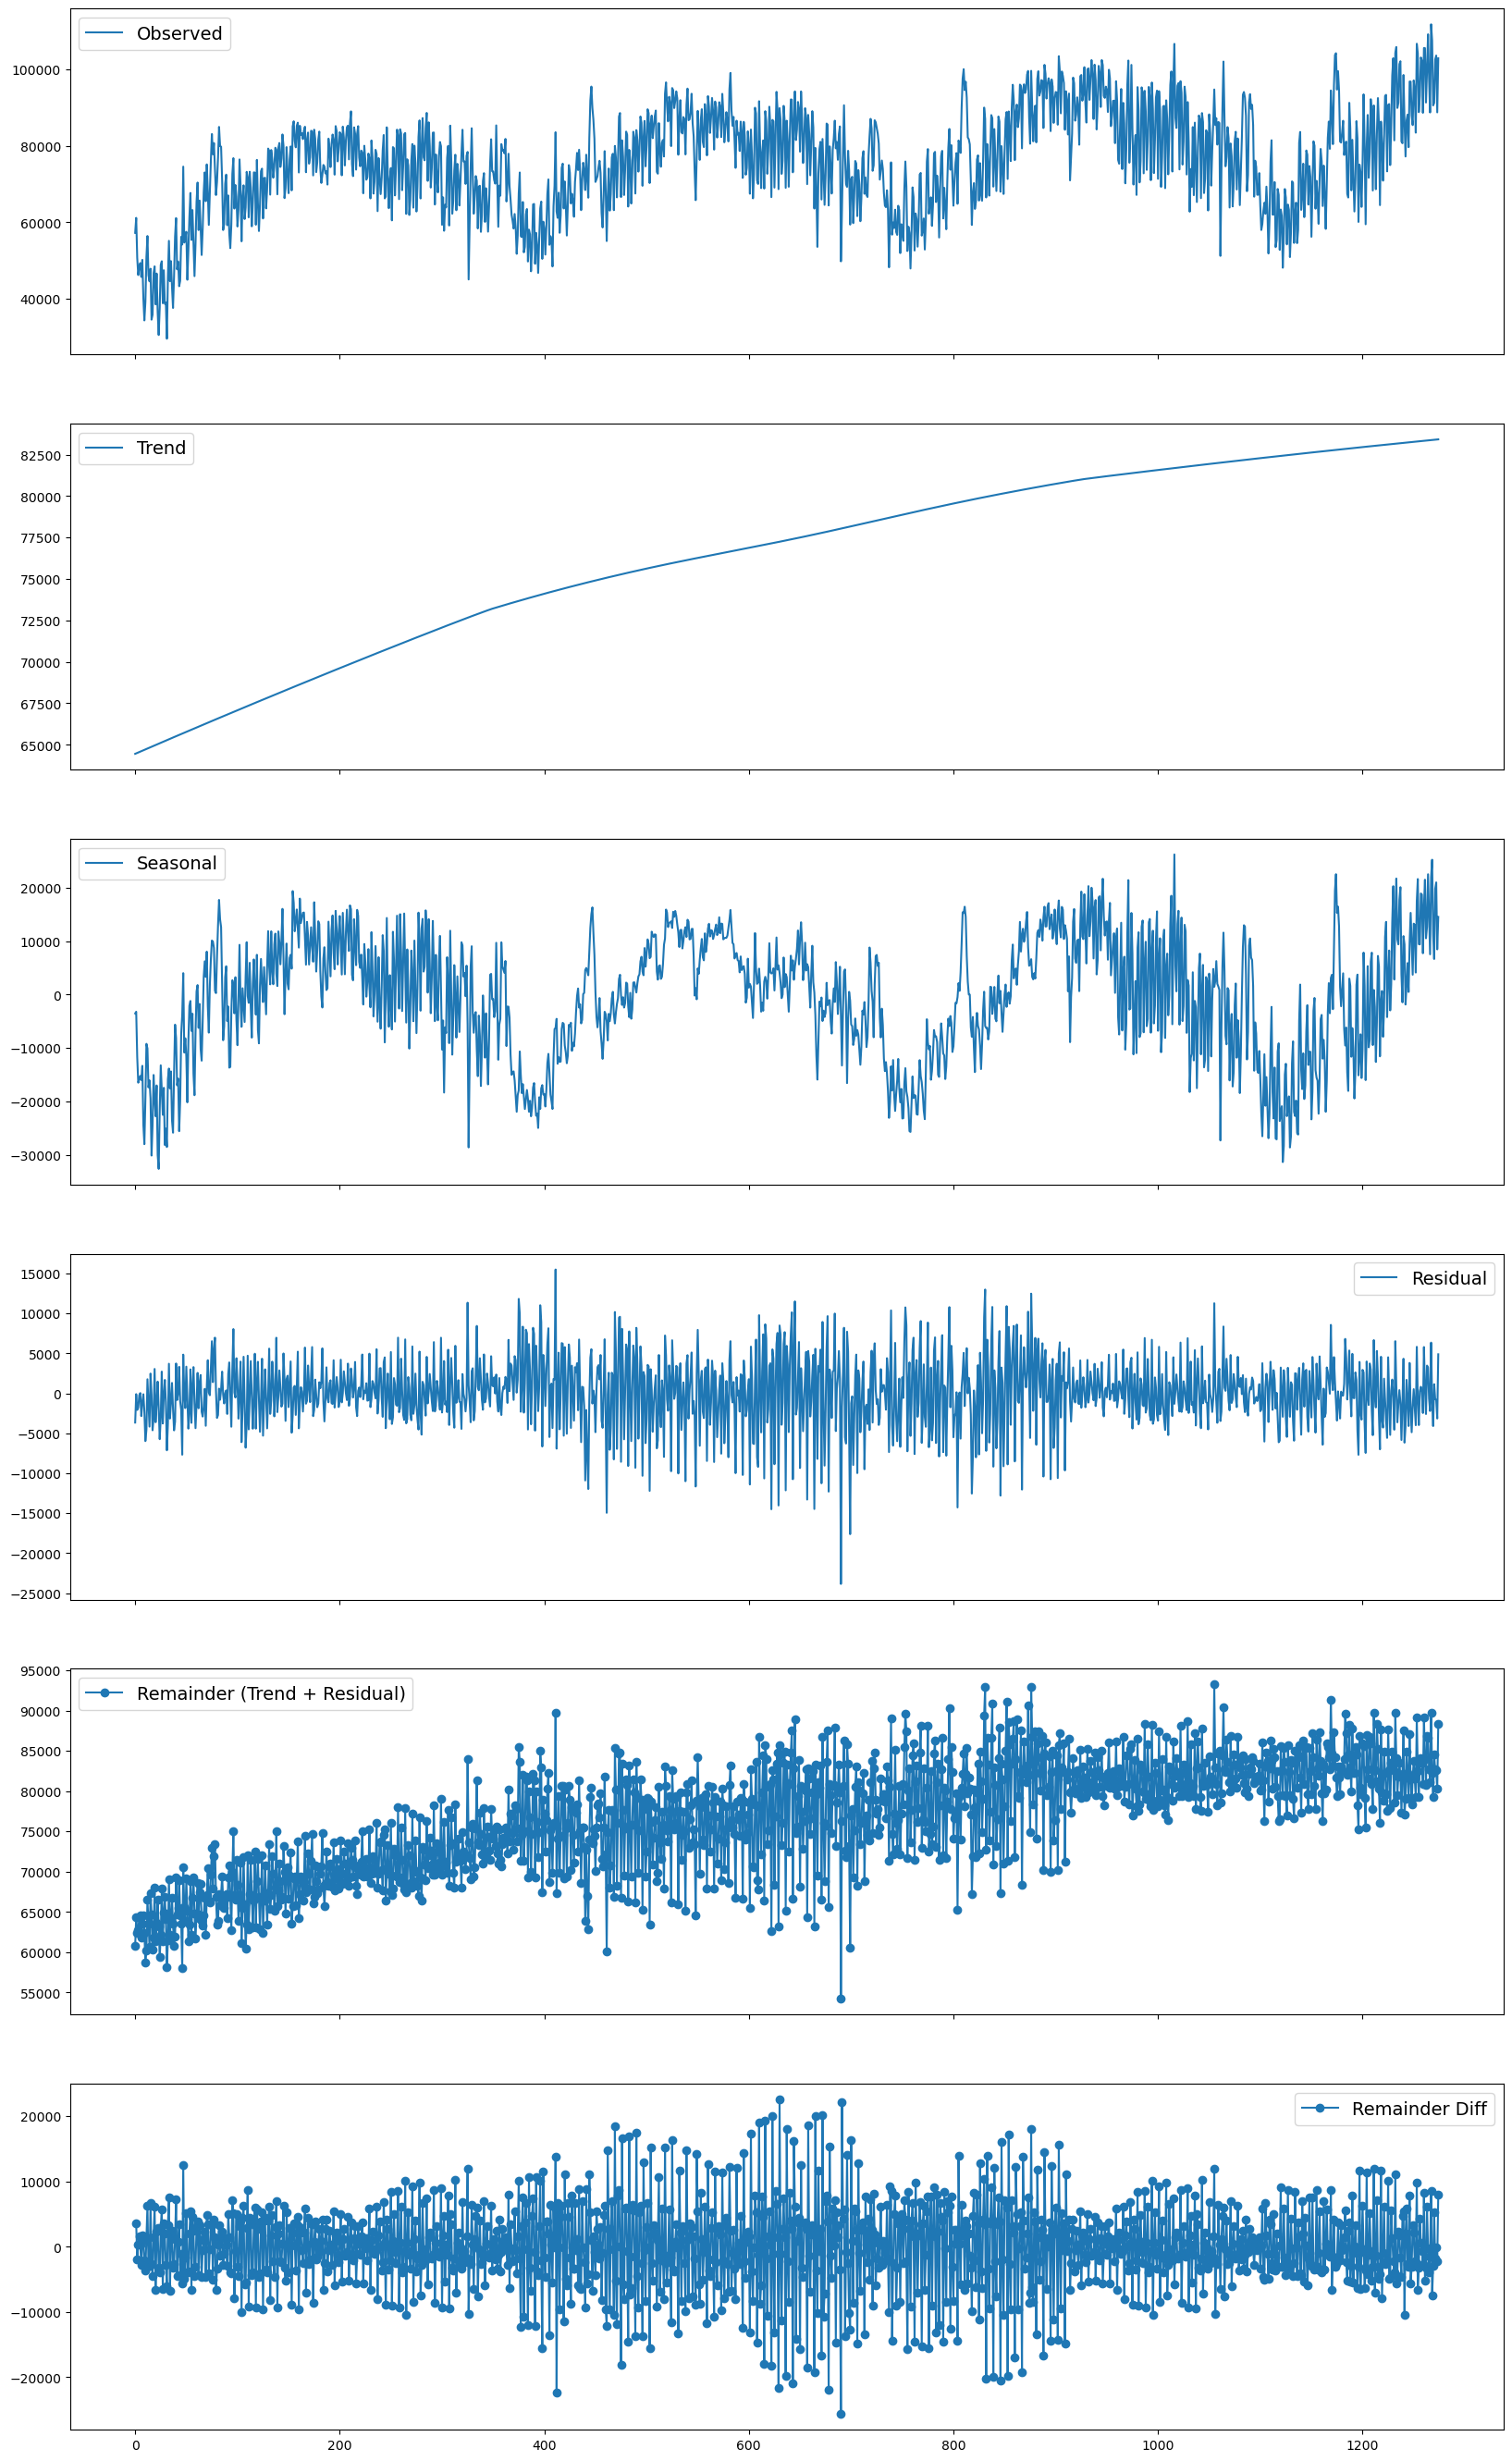

In [24]:
# Perform STL decomposition on the training set
stl_daily = STL(ord_daily['total_passenger_throughput'], period=365)
stl_daily_results = stl_daily.fit()

stl_daily_trend = stl_daily_results.trend
stl_daily_seasonal = stl_daily_results.seasonal
stl_daily_resid = stl_daily_results.resid
stl_daily_base = stl_daily_results.observed

stl_daily_trend_diff = stl_daily_trend.diff()
stl_daily_remainder = stl_daily_trend + stl_daily_resid
stl_daily_remainder_diff = stl_daily_remainder.diff()

fig, ax = plt.subplots(6, 1, figsize=(20, 34), sharex=True)
ax[0].plot(stl_daily_base, label='Observed')
ax[0].legend(fontsize=14)
ax[1].plot(stl_daily_trend, label='Trend')
ax[1].legend(fontsize=14)
ax[2].plot(stl_daily_seasonal, label='Seasonal')
ax[2].legend(fontsize=14)
ax[3].plot(stl_daily_resid, label='Residual')
ax[3].legend(fontsize=14)
ax[4].plot(stl_daily_remainder, label='Remainder (Trend + Residual)', marker='o')
ax[4].legend(fontsize=14)
ax[5].plot(stl_daily_remainder_diff, label='Remainder Diff', marker='o')
ax[5].legend(fontsize=14)
plt.show()

In [ ]:
# Obtain the auto arima model fitted to the STL remainder (trend + residuals)
# The autoarima method effectively does cross validation to select optimal hyperparameters
auto_arima(stl_daily_remainder, 
           seasonal=True,
           m=7,
           trace = True,
           stepwise=True)

```
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=24351.476, Time=2.22 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=26020.041, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=24937.798, Time=0.46 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=24789.986, Time=0.80 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=26018.055, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=24699.575, Time=1.61 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=24572.788, Time=0.57 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=24349.613, Time=4.79 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=24416.067, Time=3.90 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=5.21 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=24350.795, Time=5.08 sec
 ARIMA(1,1,2)(2,0,1)[7] intercept   : AIC=24648.010, Time=3.42 sec
 ARIMA(2,1,1)(2,0,1)[7] intercept   : AIC=24333.825, Time=4.27 sec
 ARIMA(2,1,1)(1,0,1)[7] intercept   : AIC=24337.144, Time=1.25 sec
 ARIMA(2,1,1)(2,0,0)[7] intercept   : AIC=24407.989, Time=3.57 sec
 ARIMA(2,1,1)(2,0,2)[7] intercept   : AIC=inf, Time=4.42 sec
 ARIMA(2,1,1)(1,0,0)[7] intercept   : AIC=24479.604, Time=1.22 sec
 ARIMA(2,1,1)(1,0,2)[7] intercept   : AIC=24335.267, Time=3.76 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=24545.581, Time=2.61 sec
 ARIMA(2,1,0)(2,0,1)[7] intercept   : AIC=24483.959, Time=2.89 sec
 ARIMA(3,1,1)(2,0,1)[7] intercept   : AIC=24311.666, Time=5.69 sec
 ARIMA(3,1,1)(1,0,1)[7] intercept   : AIC=24309.046, Time=1.89 sec
 ARIMA(3,1,1)(0,0,1)[7] intercept   : AIC=24672.842, Time=1.03 sec
 ARIMA(3,1,1)(1,0,0)[7] intercept   : AIC=24474.010, Time=1.23 sec
 ARIMA(3,1,1)(1,0,2)[7] intercept   : AIC=24311.177, Time=4.94 sec
 ARIMA(3,1,1)(0,0,0)[7] intercept   : AIC=24879.076, Time=0.45 sec
 ARIMA(3,1,1)(0,0,2)[7] intercept   : AIC=24550.816, Time=3.07 sec
 ARIMA(3,1,1)(2,0,0)[7] intercept   : AIC=24382.040, Time=4.18 sec
 ARIMA(3,1,1)(2,0,2)[7] intercept   : AIC=inf, Time=5.10 sec
 ARIMA(3,1,0)(1,0,1)[7] intercept   : AIC=24330.213, Time=1.30 sec
 ARIMA(4,1,1)(1,0,1)[7] intercept   : AIC=24373.909, Time=1.83 sec
 ARIMA(3,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.87 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   : AIC=24391.945, Time=0.95 sec
 ARIMA(4,1,0)(1,0,1)[7] intercept   : AIC=24328.189, Time=1.59 sec
 ARIMA(4,1,2)(1,0,1)[7] intercept   : AIC=24276.164, Time=1.78 sec
 ARIMA(4,1,2)(0,0,1)[7] intercept   : AIC=24686.456, Time=1.60 sec
 ARIMA(4,1,2)(1,0,0)[7] intercept   : AIC=inf, Time=1.79 sec
 ARIMA(4,1,2)(2,0,1)[7] intercept   : AIC=inf, Time=7.60 sec
 ARIMA(4,1,2)(1,0,2)[7] intercept   : AIC=24276.449, Time=5.20 sec
 ARIMA(4,1,2)(0,0,0)[7] intercept   : AIC=24930.083, Time=0.84 sec
 ARIMA(4,1,2)(0,0,2)[7] intercept   : AIC=24540.263, Time=5.17 sec
 ARIMA(4,1,2)(2,0,0)[7] intercept   : AIC=inf, Time=7.10 sec
 ARIMA(4,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=9.10 sec
 ARIMA(5,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=3.23 sec
 ARIMA(4,1,3)(1,0,1)[7] intercept   : AIC=24313.955, Time=2.47 sec
 ARIMA(3,1,3)(1,0,1)[7] intercept   : AIC=24274.121, Time=2.29 sec
 ARIMA(3,1,3)(0,0,1)[7] intercept   : AIC=24476.137, Time=1.80 sec
 ARIMA(3,1,3)(1,0,0)[7] intercept   : AIC=24474.347, Time=1.75 sec
 ARIMA(3,1,3)(2,0,1)[7] intercept   : AIC=24297.508, Time=5.48 sec
 ARIMA(3,1,3)(1,0,2)[7] intercept   : AIC=24272.110, Time=7.47 sec
 ARIMA(3,1,3)(0,0,2)[7] intercept   : AIC=24434.133, Time=6.10 sec
 ARIMA(3,1,3)(2,0,2)[7] intercept   : AIC=inf, Time=7.20 sec
 ARIMA(2,1,3)(1,0,2)[7] intercept   : AIC=24403.417, Time=6.19 sec
 ARIMA(3,1,2)(1,0,2)[7] intercept   : AIC=24327.924, Time=6.11 sec
 ARIMA(4,1,3)(1,0,2)[7] intercept   : AIC=24315.049, Time=9.30 sec
 ARIMA(3,1,4)(1,0,2)[7] intercept   : AIC=24266.117, Time=7.32 sec
 ARIMA(3,1,4)(0,0,2)[7] intercept   : AIC=24384.044, Time=7.20 sec
 ARIMA(3,1,4)(1,0,1)[7] intercept   : AIC=24268.429, Time=3.08 sec
 ARIMA(3,1,4)(2,0,2)[7] intercept   : AIC=24242.805, Time=8.29 sec
 ARIMA(3,1,4)(2,0,1)[7] intercept   : AIC=24258.992, Time=6.50 sec
 ARIMA(2,1,4)(2,0,2)[7] intercept   : AIC=24441.630, Time=7.99 sec
 ARIMA(4,1,4)(2,0,2)[7] intercept   : AIC=24206.465, Time=9.10 sec
 ARIMA(4,1,4)(1,0,2)[7] intercept   : AIC=24221.406, Time=10.51 sec
 ARIMA(4,1,4)(2,0,1)[7] intercept   : AIC=24214.268, Time=9.00 sec
 ARIMA(4,1,4)(1,0,1)[7] intercept   : AIC=24223.934, Time=3.32 sec
 ARIMA(4,1,3)(2,0,2)[7] intercept   : AIC=24302.671, Time=9.48 sec
 ARIMA(5,1,4)(2,0,2)[7] intercept   : AIC=24206.195, Time=9.61 sec
 ARIMA(5,1,4)(1,0,2)[7] intercept   : AIC=24221.360, Time=8.69 sec
 ARIMA(5,1,4)(2,0,1)[7] intercept   : AIC=24213.310, Time=8.70 sec
 ARIMA(5,1,4)(1,0,1)[7] intercept   : AIC=24240.309, Time=3.38 sec
 ARIMA(5,1,3)(2,0,2)[7] intercept   : AIC=inf, Time=8.91 sec
 ARIMA(5,1,5)(2,0,2)[7] intercept   : AIC=24190.677, Time=13.30 sec
 ARIMA(5,1,5)(1,0,2)[7] intercept   : AIC=24212.738, Time=13.20 sec
 ARIMA(5,1,5)(2,0,1)[7] intercept   : AIC=24220.629, Time=10.50 sec
 ARIMA(5,1,5)(1,0,1)[7] intercept   : AIC=24213.155, Time=4.09 sec
 ARIMA(4,1,5)(2,0,2)[7] intercept   : AIC=24187.118, Time=12.30 sec
 ARIMA(4,1,5)(1,0,2)[7] intercept   : AIC=24205.909, Time=12.28 sec
 ARIMA(4,1,5)(2,0,1)[7] intercept   : AIC=24201.141, Time=9.41 sec
 ARIMA(4,1,5)(1,0,1)[7] intercept   : AIC=24214.130, Time=3.50 sec
 ARIMA(3,1,5)(2,0,2)[7] intercept   : AIC=24233.948, Time=12.00 sec
 ARIMA(4,1,5)(2,0,2)[7]             : AIC=24149.766, Time=11.78 sec
 ARIMA(4,1,5)(1,0,2)[7]             : AIC=24148.627, Time=12.11 sec
 ARIMA(4,1,5)(0,0,2)[7]             : AIC=24258.104, Time=11.50 sec
 ARIMA(4,1,5)(1,0,1)[7]             : AIC=24146.923, Time=3.10 sec
 ARIMA(4,1,5)(0,0,1)[7]             : AIC=24255.306, Time=2.91 sec
 ARIMA(4,1,5)(1,0,0)[7]             : AIC=24260.105, Time=2.18 sec
 ARIMA(4,1,5)(2,0,1)[7]             : AIC=24148.574, Time=8.11 sec
 ARIMA(4,1,5)(0,0,0)[7]             : AIC=24246.408, Time=1.12 sec
 ARIMA(4,1,5)(2,0,0)[7]             : AIC=24274.130, Time=7.60 sec
 ARIMA(3,1,5)(1,0,1)[7]             : AIC=24196.732, Time=2.91 sec
 ARIMA(4,1,4)(1,0,1)[7]             : AIC=24182.032, Time=2.56 sec
 ARIMA(5,1,5)(1,0,1)[7]             : AIC=24142.117, Time=3.05 sec
 ARIMA(5,1,5)(0,0,1)[7]             : AIC=24214.329, Time=3.07 sec
 ARIMA(5,1,5)(1,0,0)[7]             : AIC=24215.346, Time=3.53 sec
 ARIMA(5,1,5)(2,0,1)[7]             : AIC=24138.493, Time=9.38 sec
 ARIMA(5,1,5)(2,0,0)[7]             : AIC=24266.904, Time=8.78 sec
 ARIMA(5,1,5)(2,0,2)[7]             : AIC=24137.858, Time=12.42 sec
 ARIMA(5,1,5)(1,0,2)[7]             : AIC=24138.168, Time=11.40 sec
 ARIMA(5,1,4)(2,0,2)[7]             : AIC=24141.754, Time=7.93 sec
 ARIMA(4,1,4)(2,0,2)[7]             : AIC=24179.770, Time=8.07 sec

Best model:  ARIMA(5,1,5)(2,0,2)[7]          
Total fit time: 532.122 seconds
```

In [25]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Arima orders for the remainder component of the STL decomposition
# OLD: Best model:  ARIMA(5,1,2)(2,0,1)[7] 
# NEW: Best model:  ARIMA(5,1,4)(1,0,2)[7]
# NEWEST: Best model: ARIMA(5,1,5)(2,0,2)[7]
p, d, q = 5, 1, 5
P, D, Q, s = 2, 0, 2, 7

results_stl_d = []
# Running STL + ARIMA on daily data using the splits created above.
for i, (train_idx, test_idx) in enumerate(splits_d, start=1):
        train = ord_daily.iloc[train_idx]
        test  = ord_daily.iloc[test_idx]
        n_forecast = len(test_idx)

        model = STLArima(season_length=365, arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
        model.fit(train['total_passenger_throughput'])
        forecasts, lower_bound, upper_bound = model.forecast(n_forecast)
        
        actuals  = test['total_passenger_throughput']
        metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_stl_d.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")

results_stl_d_df = pd.DataFrame(results_stl_d).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_stl_d_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_stl_d_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_stl_d_df['rmse'].mean():,.0f}")

Split 1 - MAE: 8688, MAPE: 10.46%, RMSE: 10339
Split 2 - MAE: 9185, MAPE: 10.66%, RMSE: 11411
Split 3 - MAE: 10356, MAPE: 13.36%, RMSE: 13366
Split 4 - MAE: 7961, MAPE: 11.88%, RMSE: 9933
Split 5 - MAE: 9765, MAPE: 11.97%, RMSE: 12156

CV Average:
  MAE:  9,191
  MAPE: 11.67%
  RMSE: 11,441


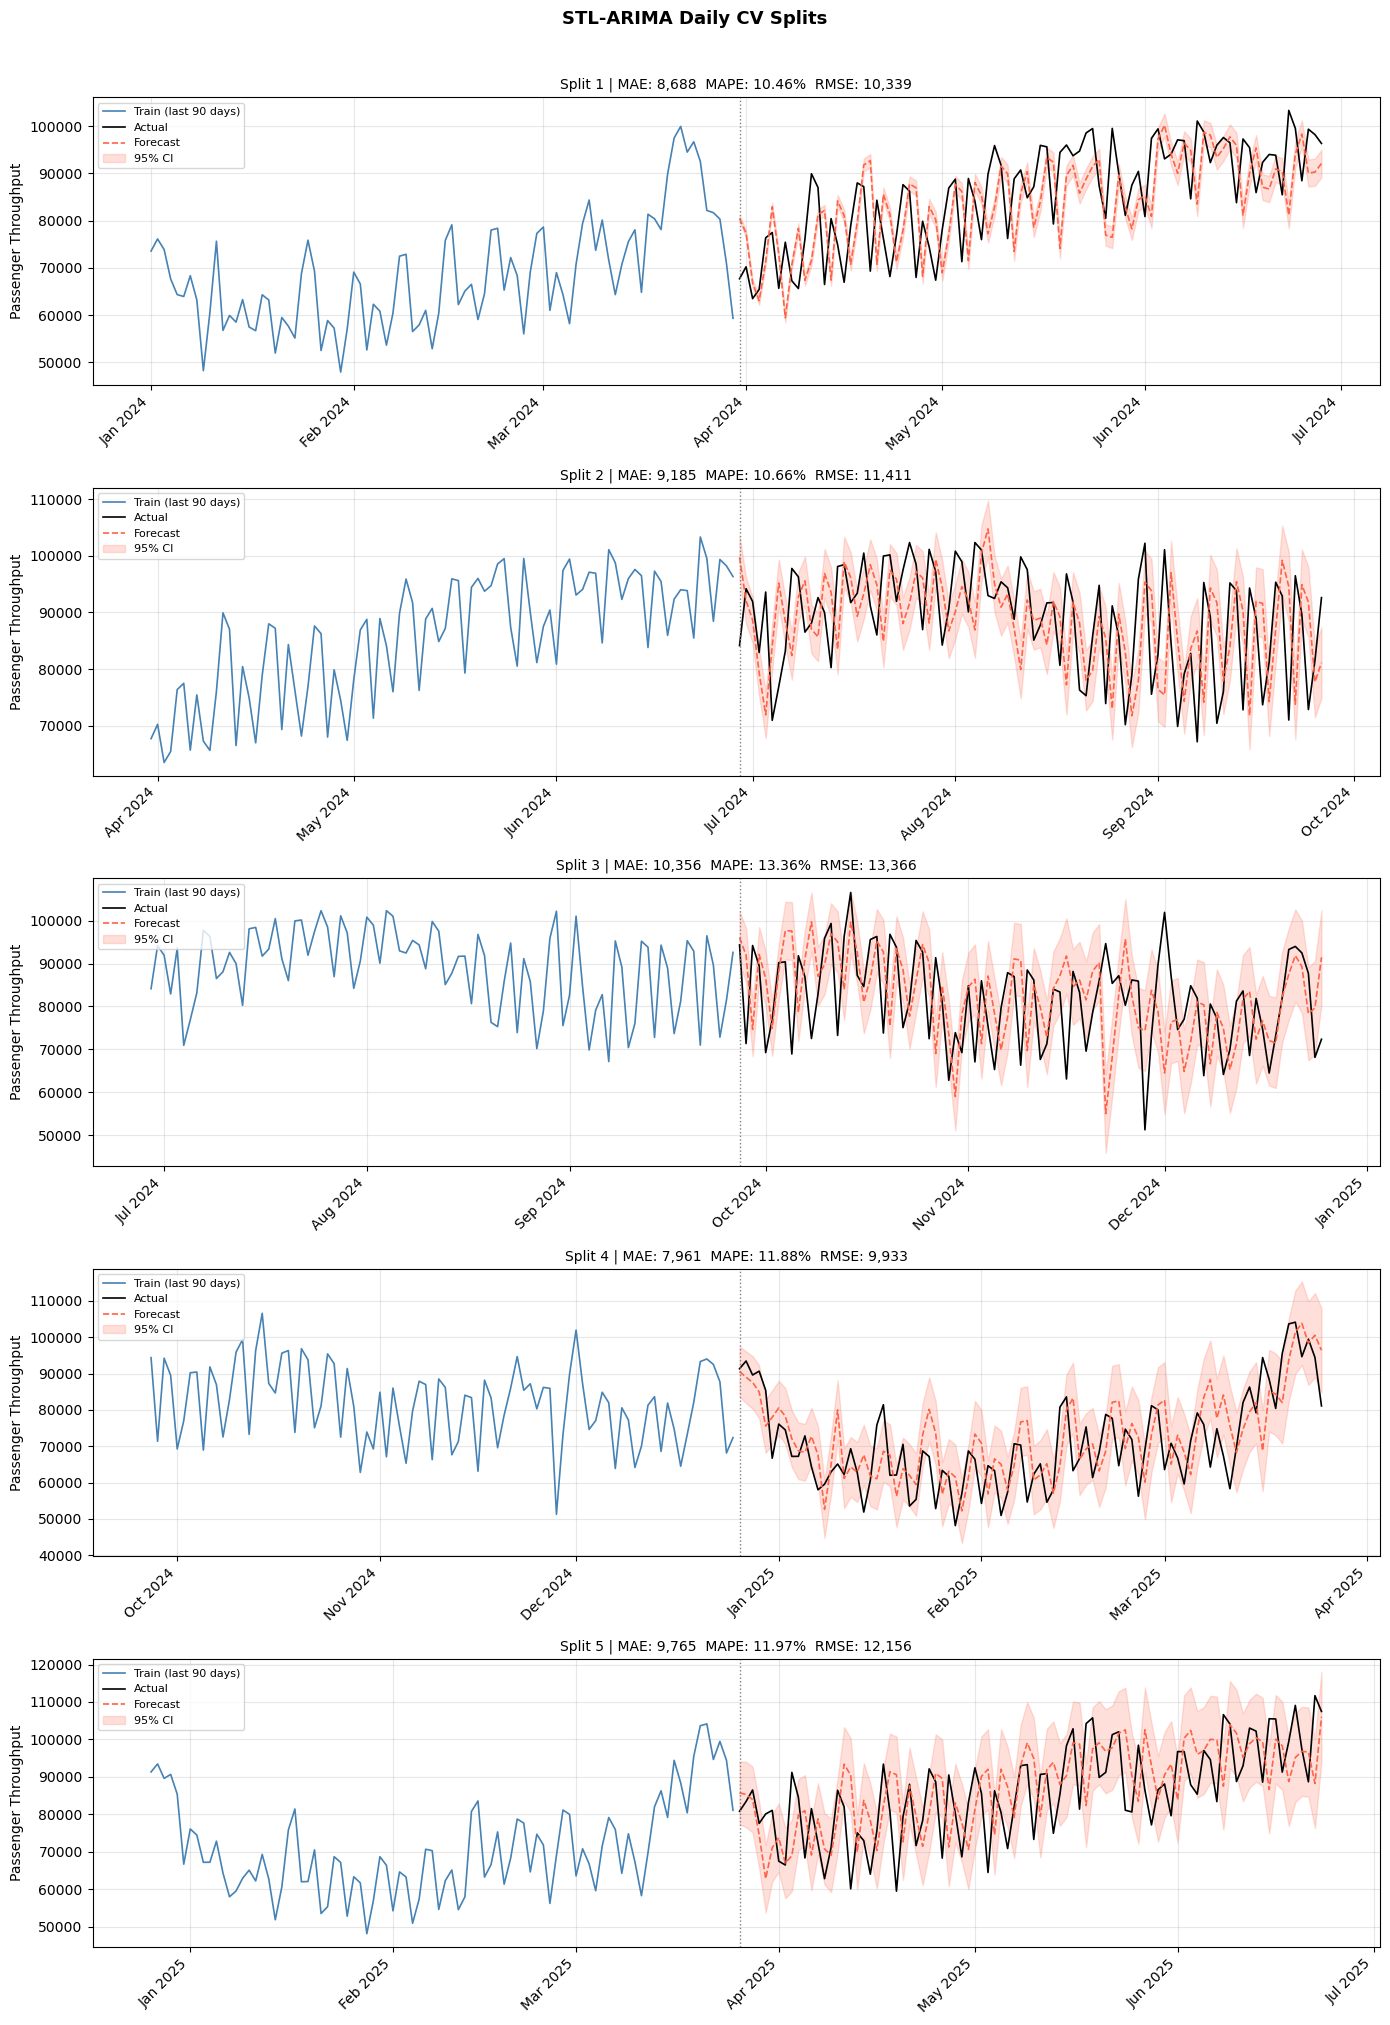

In [26]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(splits_d), 1, figsize=(14, 4 * len(splits_d)))
axes = axes if hasattr(axes, '__len__') else [axes]  # handle single split edge case

for i, (train_idx, test_idx) in enumerate(splits_d):
    ax = axes[i]

    train = ord_daily.iloc[train_idx]
    test  = ord_daily.iloc[test_idx]
    n_forecast = len(test_idx)

    model = STLArima(season_length=365, arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
    model.fit(train['total_passenger_throughput'])
    forecasts, lower_bound, upper_bound = model.forecast(n_forecast)

    actuals = test['total_passenger_throughput']
    metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_stl_d.append(metrics)

    # --- Plotting ---
    train_dates = train.datetime
    test_dates  = test.datetime

    # Plot last N days of training data for context
    context_window = min(90, len(train))
    ax.plot(train_dates.iloc[-context_window:],
            train['total_passenger_throughput'].iloc[-context_window:],
            color='steelblue', label='Train (last 90 days)', linewidth=1.2)

    # Actuals in test window
    ax.plot(test_dates, actuals,
            color='black', label='Actual', linewidth=1.2)

    # Forecast
    ax.plot(test_dates, forecasts,
            color='tomato', label='Forecast', linewidth=1.2, linestyle='--')

    # 95% Confidence interval
    ax.fill_between(test_dates, lower_bound, upper_bound,
                    color='tomato', alpha=0.2, label='95% CI')

    # Vertical line separating train/test
    ax.axvline(x=test_dates.iloc[0], color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f"Split {i+1} | MAE: {metrics['mae']:,.0f}  "
        f"MAPE: {100*metrics['mape']:.2f}%  "
        f"RMSE: {metrics['rmse']:,.0f}",
        fontsize=10
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Passenger Throughput')
    ax.grid(True, alpha=0.3)

plt.suptitle('STL-ARIMA Daily CV Splits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Harmonic ARIMA - Daily

In [27]:
from busy_airports.models import fourier_features, HarmonicARIMA
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

For Harmonic ARIMA, first we must determine the optimal number of frequencies to use in the Harmonic part of the model. We do so by modeling the data using Linear Regression with the Fourier features.

In [28]:
from sklearn.linear_model import LinearRegression


Minimum metrics:
  MAE:  (18, 9,944)
  MAPE: (18, 0.12%)
  RMSE: (18, 11,796)


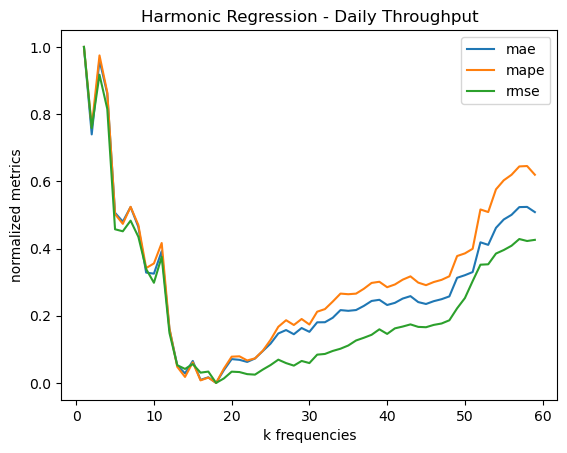

In [29]:
# Average the metrics over all folds for each choice of k_frequency
results = []

for k_freq in range(1, 60):
    # Determine Fourier features for the given number of frequencies
    ord_daily_X = fourier_features(ord_daily['day'], m=365, k=k_freq)
    
    k_metrics = []

    for i, (train_idx, test_idx) in enumerate(splits_d, start = 1):
        X_train = ord_daily_X[train_idx]
        X_test  = ord_daily_X[test_idx]
        y_train = ord_daily.iloc[train_idx].total_passenger_throughput
        y_test  = ord_daily.iloc[test_idx].total_passenger_throughput

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = evaluate_forecast(y_test, y_pred, f"Split {i}")
        metrics['split'] = i
        k_metrics.append(metrics)
    
    metrics_df = pd.DataFrame(k_metrics).set_index('split')
    mean_metrics = {}
    mean_metrics['k_freq'] = k_freq
    mean_metrics['mae']  = metrics_df['mae'].mean()
    mean_metrics['mape'] = metrics_df['mape'].mean()
    mean_metrics['rmse'] = metrics_df['rmse'].mean()
    results.append(mean_metrics)

results_df = pd.DataFrame(results).set_index('k_freq')

print(f"\nMinimum metrics:")
print(f"  MAE:  ({results_df['mae'].idxmin()}, {results_df['mae'].min():,.0f})")
print(f"  MAPE: ({results_df['mape'].idxmin()}, {results_df['mape'].min():.2f}%)")
print(f"  RMSE: ({results_df['rmse'].idxmin()}, {results_df['rmse'].min():,.0f})")

# Normalize all metrics between 0 and 1 for comparison
results_df = (results_df - results_df.min()) / (results_df.max() - results_df.min())
results_df.plot()
plt.title('Harmonic Regression - Daily Throughput')
plt.xlabel('k frequencies')
plt.ylabel('normalized metrics')
plt.legend()
plt.show()

These results demonstrate that the optimal choice of `k_frequencies` for capturing the annual trend appears to be about 18.

We can now apply `autoarima` using the optimal number of Fourier features and the largest set of training data. This will allow us to determine the optimal SARIMA model to use to capture the weekly trend and the errors in the data.

**Note**: This cell can take a very long time. Run at your own peril.

In [ ]:
# Create optimal number of Fourier features to model annual trend
ord_daily_X = fourier_features(ord_daily['day'], m=365, k=18)
# Take largest split for determining optimal SARIMA model
X_train = ord_daily_X[splits_d[-1][0]]
X_test  = ord_daily_X[splits_d[-1][1]]
y_train = ord_daily.iloc[splits_d[-1][0]].total_passenger_throughput
y_test  = ord_daily.iloc[splits_d[-1][1]].total_passenger_throughput

arima_model = auto_arima(
    y_train,
    X=X_train,
    seasonal=True, m=7,
    d=1, D=0, # d = 1 captures linear trend, D = 0 for simplicity (no observed week-by-week trend)
    stepwise=True,
    trace=True
)

```
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=16516.956, Time=219.82 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=17333.498, Time=0.60 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=16856.580, Time=88.77 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=16800.379, Time=146.52 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=22000.712, Time=0.63 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=16711.257, Time=96.32 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=16619.793, Time=188.92 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=inf, Time=284.26 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=16517.340, Time=264.22 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=16811.825, Time=13.61 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=16640.669, Time=128.55 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=16559.234, Time=232.64 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=259.51 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=16549.225, Time=237.22 sec
 ARIMA(2,1,1)(1,0,1)[7] intercept   : AIC=16523.737, Time=200.78 sec
 ARIMA(3,1,2)(1,0,1)[7] intercept   : AIC=16468.958, Time=238.60 sec
 ARIMA(3,1,2)(0,0,1)[7] intercept   : AIC=16689.594, Time=94.26 sec
 ARIMA(3,1,2)(1,0,0)[7] intercept   : AIC=16584.472, Time=207.48 sec
 ARIMA(3,1,2)(2,0,1)[7] intercept   : AIC=16470.243, Time=299.33 sec
 ARIMA(3,1,2)(1,0,2)[7] intercept   : AIC=16475.914, Time=277.73 sec
 ARIMA(3,1,2)(0,0,0)[7] intercept   : AIC=16783.784, Time=16.18 sec
 ARIMA(3,1,2)(0,0,2)[7] intercept   : AIC=16609.874, Time=135.62 sec
 ARIMA(3,1,2)(2,0,0)[7] intercept   : AIC=16516.541, Time=274.54 sec
 ARIMA(3,1,2)(2,0,2)[7] intercept   : AIC=inf, Time=274.71 sec
...
 ARIMA(5,1,1)(1,0,1)[7] intercept   : AIC=16484.386, Time=265.53 sec
 ARIMA(5,1,3)(1,0,1)[7] intercept   : AIC=inf, Time=289.63 sec
 ARIMA(4,1,2)(1,0,1)[7]             : AIC=16371.907, Time=146.01 sec
 ARIMA(4,1,2)(0,0,1)[7]             : AIC=16671.967, Time=94.53 sec

Best model:  ARIMA(4,1,2)(1,0,1)[7]
```

After running the `autoarima`, we find that the optimal SARIMA model is `ARIMA(4,1,2)(1,0,1)[7]` with no intercept.

Finally, we can apply this model across all the splits and see what metrics we obtain.

In [30]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

results_harm_arima_d = []

for i, (train_idx, test_idx) in enumerate(splits_d, start=1):
        train = ord_daily.iloc[train_idx]
        test  = ord_daily.iloc[test_idx]

        model = HarmonicARIMA(harmonic_m=365,
                              harmonic_k=18,
                              arima_order=(4,1,2), 
                              seasonal_order=(1,0,1,7),
                              with_intercept=False)
        model.fit(train.day, train.total_passenger_throughput)
        forecasts, lower_bound, upper_bound = model.forecast(test.day)

        metrics = evaluate_forecast(test.total_passenger_throughput, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_harm_arima_d.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")
        
results_harm_arima_d_df = pd.DataFrame(results_harm_arima_d).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_harm_arima_d_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_harm_arima_d_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_harm_arima_d_df['rmse'].mean():,.0f}")

Split 1 - MAE: 10986, MAPE: 12.36%, RMSE: 12278
Split 2 - MAE: 4874, MAPE: 5.94%, RMSE: 6692
Split 3 - MAE: 6092, MAPE: 8.06%, RMSE: 8064
Split 4 - MAE: 4771, MAPE: 6.46%, RMSE: 6161
Split 5 - MAE: 5436, MAPE: 6.33%, RMSE: 6723

CV Average:
  MAE:  6,432
  MAPE: 7.83%
  RMSE: 7,984


The metrics here are much lower than the STL + ARIMA model from earlier, and they beat the baseline models. This model appears to be the best candidate for forecasting the daily throughput data!

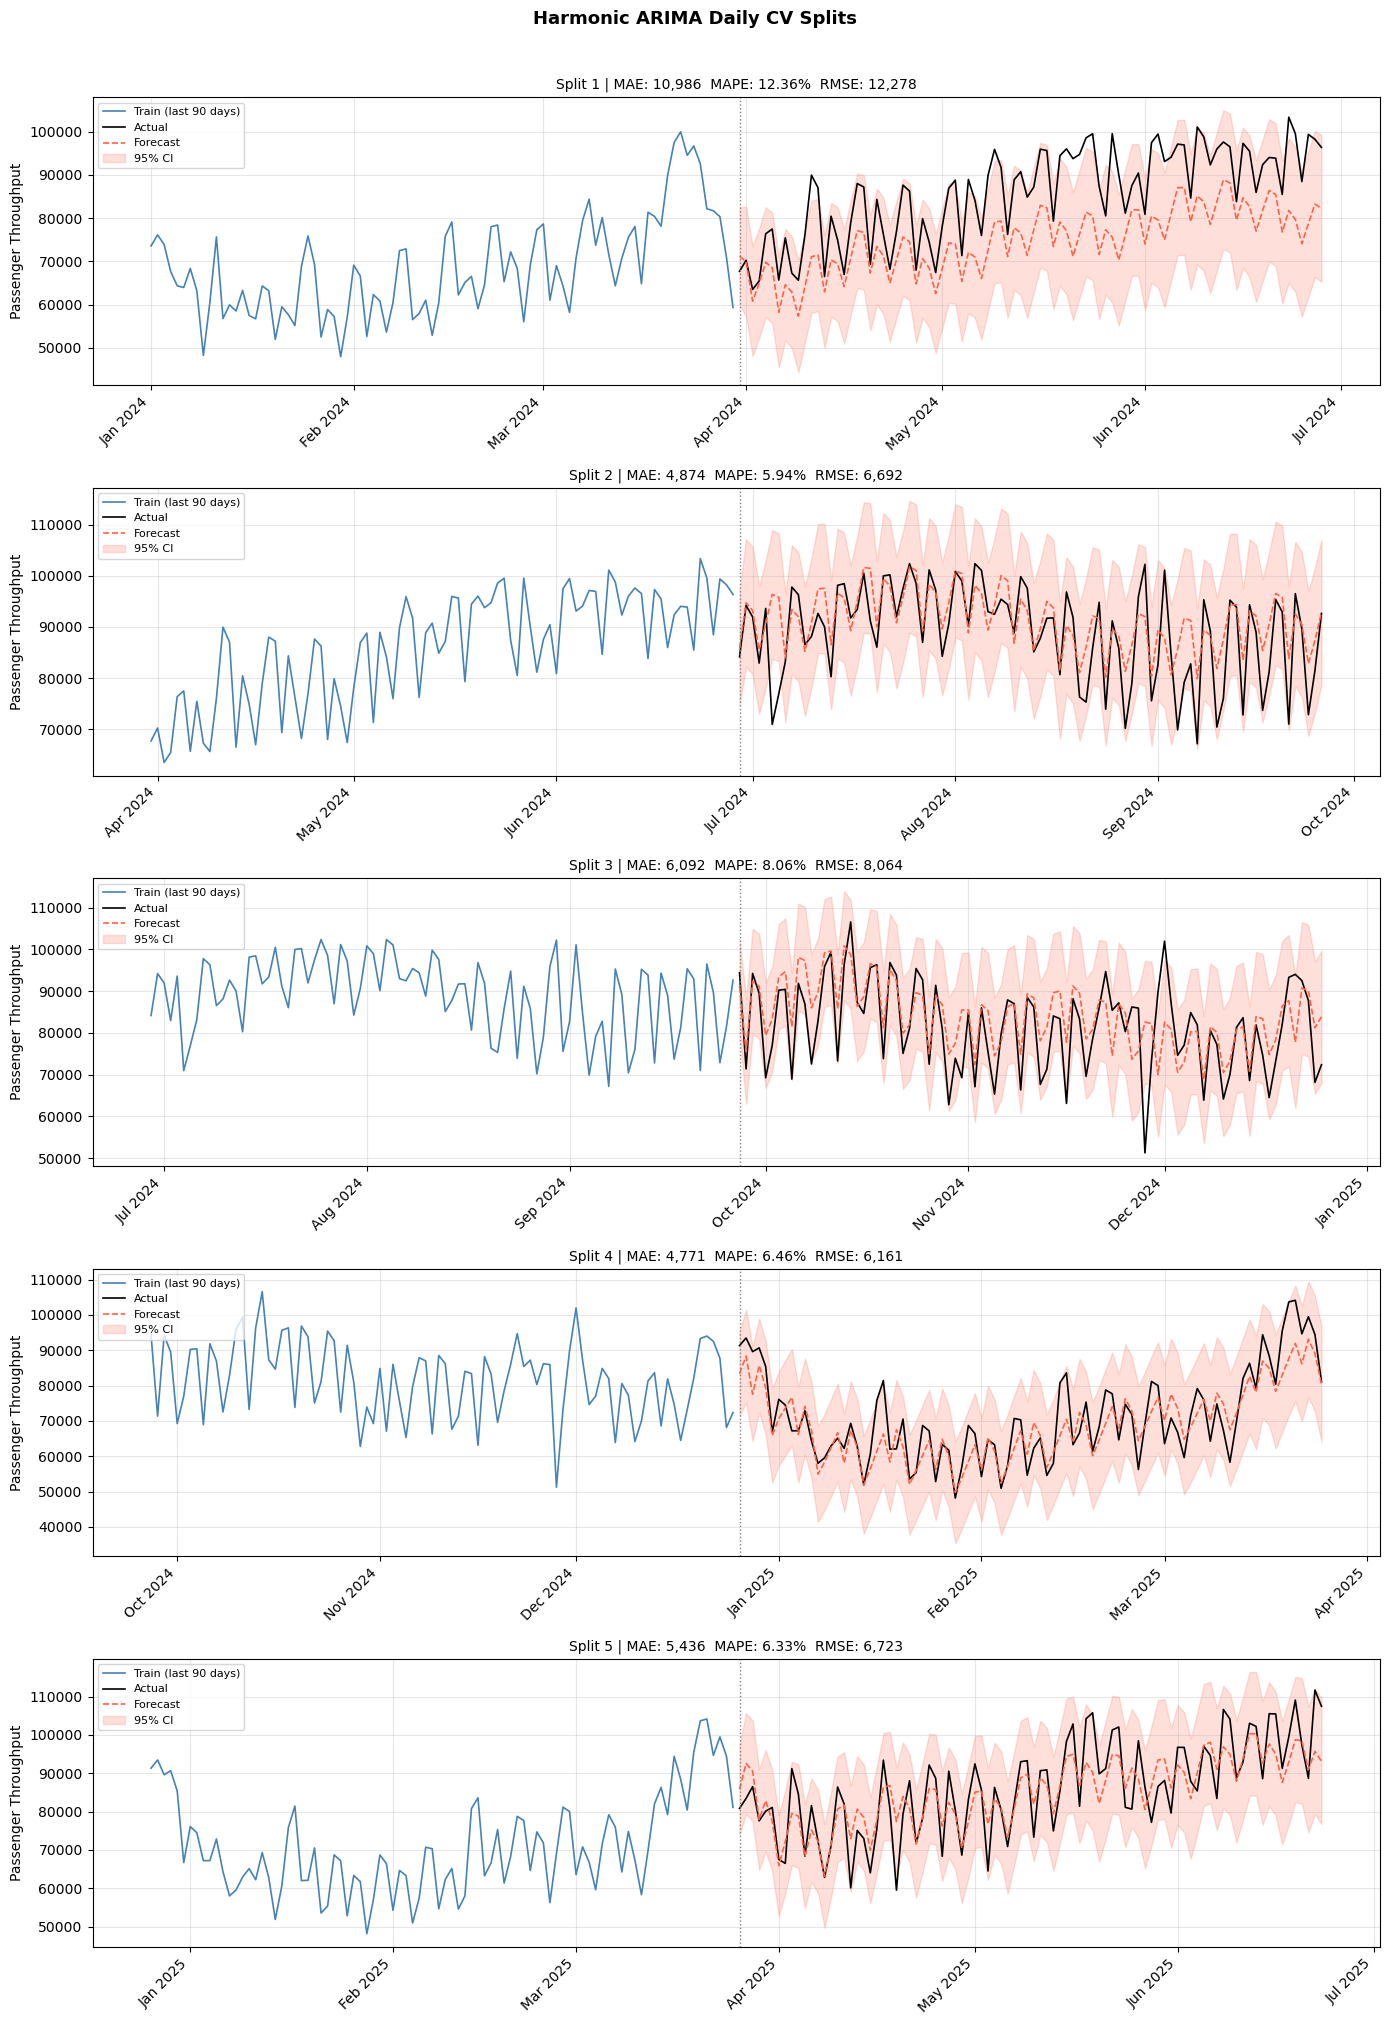

In [31]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(splits_d), 1, figsize=(14, 4 * len(splits_d)))
axes = axes if hasattr(axes, '__len__') else [axes]  # handle single split edge case

for i, (train_idx, test_idx) in enumerate(splits_d):
    ax = axes[i]

    train = ord_daily.iloc[train_idx]
    test  = ord_daily.iloc[test_idx]

    model = HarmonicARIMA(harmonic_m=365,
                              harmonic_k=18,
                              arima_order=(4,1,2), 
                              seasonal_order=(1,0,1,7),
                              with_intercept=False)
    model.fit(train.day, train.total_passenger_throughput)
    forecasts, lower_bound, upper_bound = model.forecast(test.day)

    actuals = test.total_passenger_throughput
    metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")

    # --- Plotting ---
    train_dates = train.datetime
    test_dates  = test.datetime

    # Plot last N days of training data for context
    context_window = min(90, len(train))
    ax.plot(train_dates.iloc[-context_window:],
            train['total_passenger_throughput'].iloc[-context_window:],
            color='steelblue', label='Train (last 90 days)', linewidth=1.2)

    # Actuals in test window
    ax.plot(test_dates, actuals,
            color='black', label='Actual', linewidth=1.2)

    # Forecast
    ax.plot(test_dates, forecasts,
            color='tomato', label='Forecast', linewidth=1.2, linestyle='--')

    # 95% Confidence interval
    ax.fill_between(test_dates, lower_bound, upper_bound,
                    color='tomato', alpha=0.2, label='95% CI')

    # Vertical line separating train/test
    ax.axvline(x=test_dates.iloc[0], color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f"Split {i+1} | MAE: {metrics['mae']:,.0f}  "
        f"MAPE: {100*metrics['mape']:.2f}%  "
        f"RMSE: {metrics['rmse']:,.0f}",
        fontsize=10
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Passenger Throughput')
    ax.grid(True, alpha=0.3)

plt.suptitle('Harmonic ARIMA Daily CV Splits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Baselines - Weekly

Before evaluating our weekly models, we must start by establishing the metrics for the baseline models across our time series splits.

In [32]:
# Weekly Baseline - Naive Seasonal with Drift
results_nswd_w = []

for i, (train_idx, test_idx) in enumerate(splits_w, start=1):
        train = ord_weekly.iloc[train_idx]
        test  = ord_weekly.iloc[test_idx]

        model = NaiveSeasonalWithDrift(season_length=52)
        model.fit(train.total_passenger_throughput)
        forecasts = model.forecast(h=len(test))

        metrics = evaluate_forecast(test.total_passenger_throughput, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_nswd_w.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")
        
results_nswd_w_df = pd.DataFrame(results_nswd_w).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_nswd_w_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_nswd_w_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_nswd_w_df['rmse'].mean():,.0f}")

Split 1 - MAE: 24071, MAPE: 3.90%, RMSE: 28144
Split 2 - MAE: 14224, MAPE: 2.28%, RMSE: 15503
Split 3 - MAE: 21894, MAPE: 3.79%, RMSE: 25913
Split 4 - MAE: 16755, MAPE: 3.56%, RMSE: 20865
Split 5 - MAE: 41694, MAPE: 7.08%, RMSE: 48477

CV Average:
  MAE:  23,728
  MAPE: 4.12%
  RMSE: 27,781


In [33]:
# Weekly Baseline - Triple Exponential Smoothing
results_exps_w = []

for i, (train_idx, test_idx) in enumerate(splits_w, start=1):
        train = ord_weekly.iloc[train_idx]
        test  = ord_weekly.iloc[test_idx]

        model = TripleExponentialSmoothing(season_length=52)
        model.fit(train.total_passenger_throughput)
        forecasts = model.forecast(h=len(test))

        metrics = evaluate_forecast(test.total_passenger_throughput, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_exps_w.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")
        
results_exps_w_df = pd.DataFrame(results_exps_w).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_exps_w_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_exps_w_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_exps_w_df['rmse'].mean():,.0f}")

Split 1 - MAE: 15358, MAPE: 2.48%, RMSE: 18814
Split 2 - MAE: 16350, MAPE: 2.60%, RMSE: 18889
Split 3 - MAE: 26545, MAPE: 4.69%, RMSE: 29978
Split 4 - MAE: 25659, MAPE: 5.47%, RMSE: 30143
Split 5 - MAE: 25691, MAPE: 4.43%, RMSE: 32148

CV Average:
  MAE:  21,921
  MAPE: 3.94%
  RMSE: 25,994


Clearly these baselines perform much better than they did when applied to the daily data. The annual seasonality is much clearer in the weekly data and is essentially the only seasonality in the data. This is much simpler than the two seasonalities that occured in the daily data. These baselines will inevitably be much harder to beat.

## STLArima - Weekly

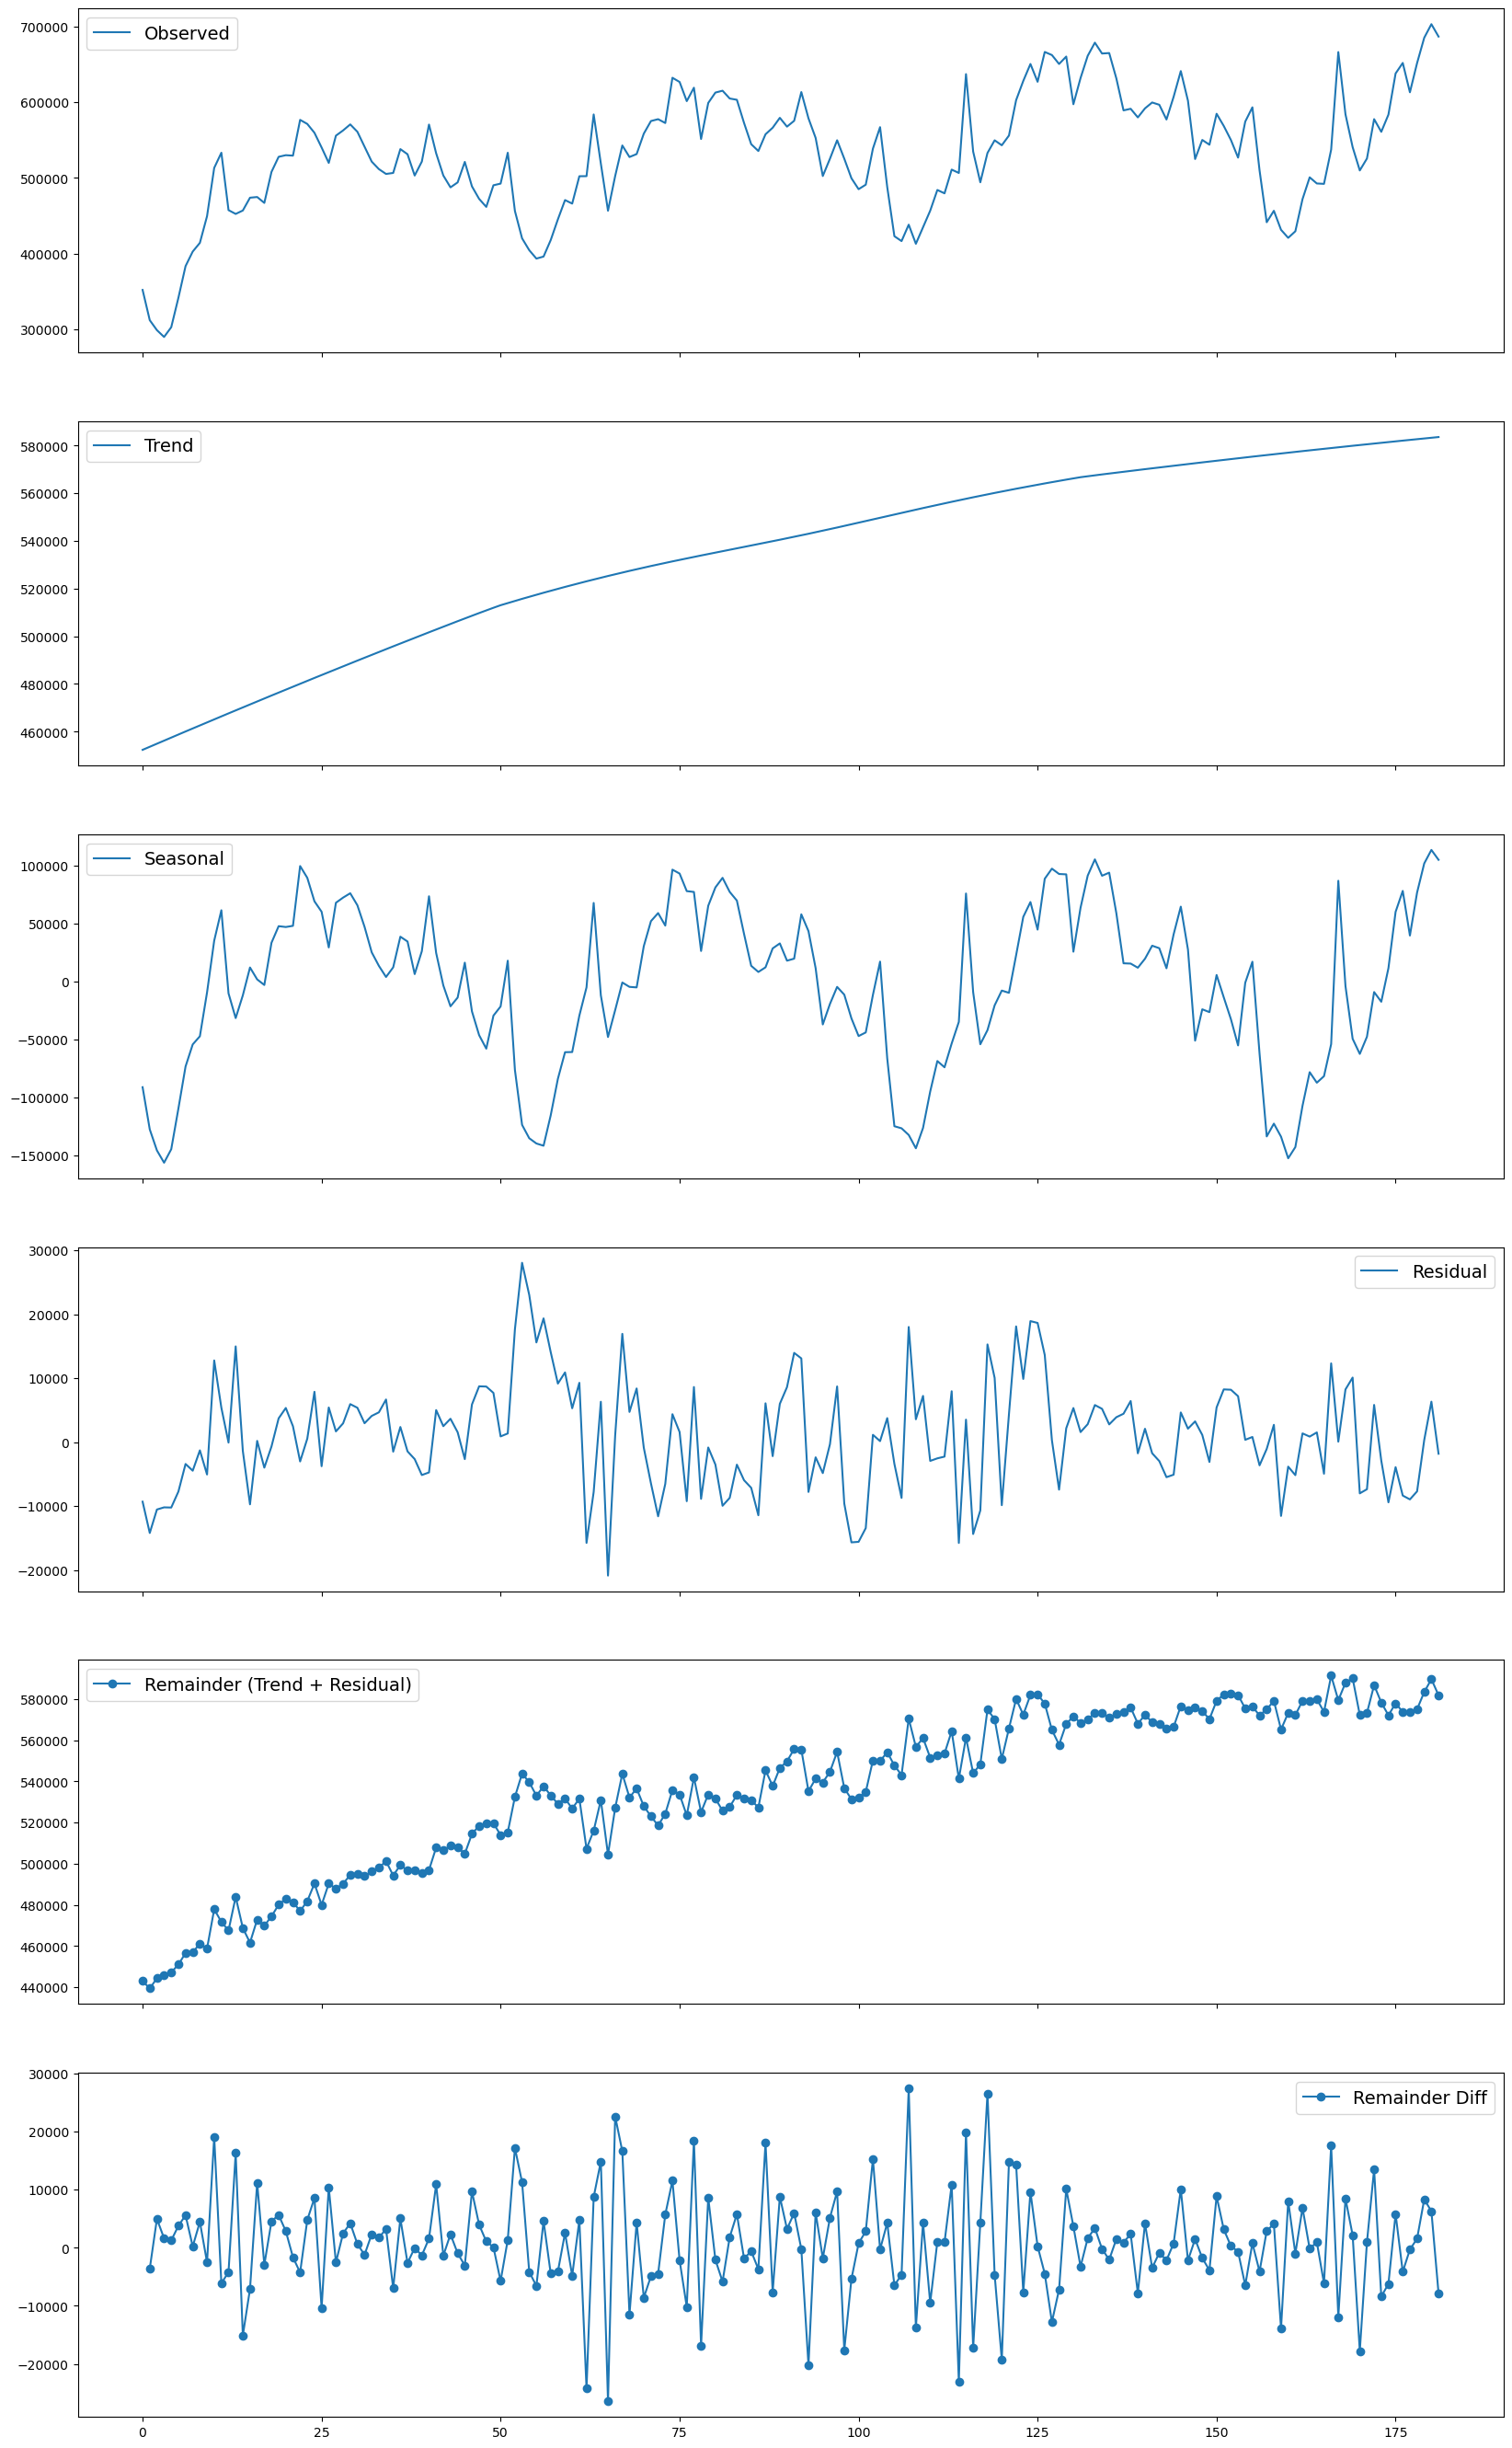

In [34]:
# Perform STL decomposition on the training set
stl_weekly = STL(ord_weekly['total_passenger_throughput'], period=52)
stl_weekly_results = stl_weekly.fit()

stl_weekly_trend = stl_weekly_results.trend
stl_weekly_seasonal = stl_weekly_results.seasonal
stl_weekly_resid = stl_weekly_results.resid
stl_weekly_base = stl_weekly_results.observed

stl_weekly_trend_diff = stl_weekly_trend.diff()
stl_weekly_remainder = stl_weekly_trend + stl_weekly_resid
stl_weekly_remainder_diff = stl_weekly_remainder.diff()

fig, ax = plt.subplots(6, 1, figsize=(20, 34), sharex=True)
ax[0].plot(stl_weekly_base, label='Observed')
ax[0].legend(fontsize=14)
ax[1].plot(stl_weekly_trend, label='Trend')
ax[1].legend(fontsize=14)
ax[2].plot(stl_weekly_seasonal, label='Seasonal')
ax[2].legend(fontsize=14)
ax[3].plot(stl_weekly_resid, label='Residual')
ax[3].legend(fontsize=14)
ax[4].plot(stl_weekly_remainder, label='Remainder (Trend + Residual)', marker='o')
ax[4].legend(fontsize=14)
ax[5].plot(stl_weekly_remainder_diff, label='Remainder Diff', marker='o')
ax[5].legend(fontsize=14)
plt.show()

In [37]:
# Obtain the auto arima model fitted to the STL remainder (trend + residuals)
# The autoarima method effectively does cross validation to select optimal hyperparameters
auto_arima(stl_weekly_remainder,
           seasonal=False,
           trace = True,
           stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3812.198, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3812.501, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3814.612, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3811.519, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3816.477, Time=0.09 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.371 seconds


,order,"(0, ...)"
,seasonal_order,"(0, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,False


In [35]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Arima orders for the remainder component of the STL decomposition
# Best model:  ARIMA(0,1,0)(0,0,0)[0]

p, d, q = 0, 1, 0
P, D, Q, s = 0, 0, 0, 0

results_stl_w = []
# Running STL + ARIMA on weekly data using the splits created above.
for i, (train_idx, test_idx) in enumerate(splits_w, start=1):
        train = ord_weekly.iloc[train_idx]
        test  = ord_weekly.iloc[test_idx]
        n_forecast = len(test_idx)

        model = STLArima(season_length=52, arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
        model.fit(train['total_passenger_throughput'])
        forecasts, lower_bound, upper_bound = model.forecast(n_forecast)
        
        actuals  = test['total_passenger_throughput']
        metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_stl_w.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")

results_stl_w_df = pd.DataFrame(results_stl_w).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_stl_w_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_stl_w_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_stl_w_df['rmse'].mean():,.0f}")

Split 1 - MAE: 15545, MAPE: 2.56%, RMSE: 19029
Split 2 - MAE: 13794, MAPE: 2.19%, RMSE: 15848
Split 3 - MAE: 22343, MAPE: 3.89%, RMSE: 26690
Split 4 - MAE: 22879, MAPE: 4.91%, RMSE: 27775
Split 5 - MAE: 30219, MAPE: 5.17%, RMSE: 36578

CV Average:
  MAE:  20,956
  MAPE: 3.74%
  RMSE: 25,184


This model ever so slightly beats the best baseline model (exponential smoothing). Looking at individual splits, it seems like the models perform about the same.

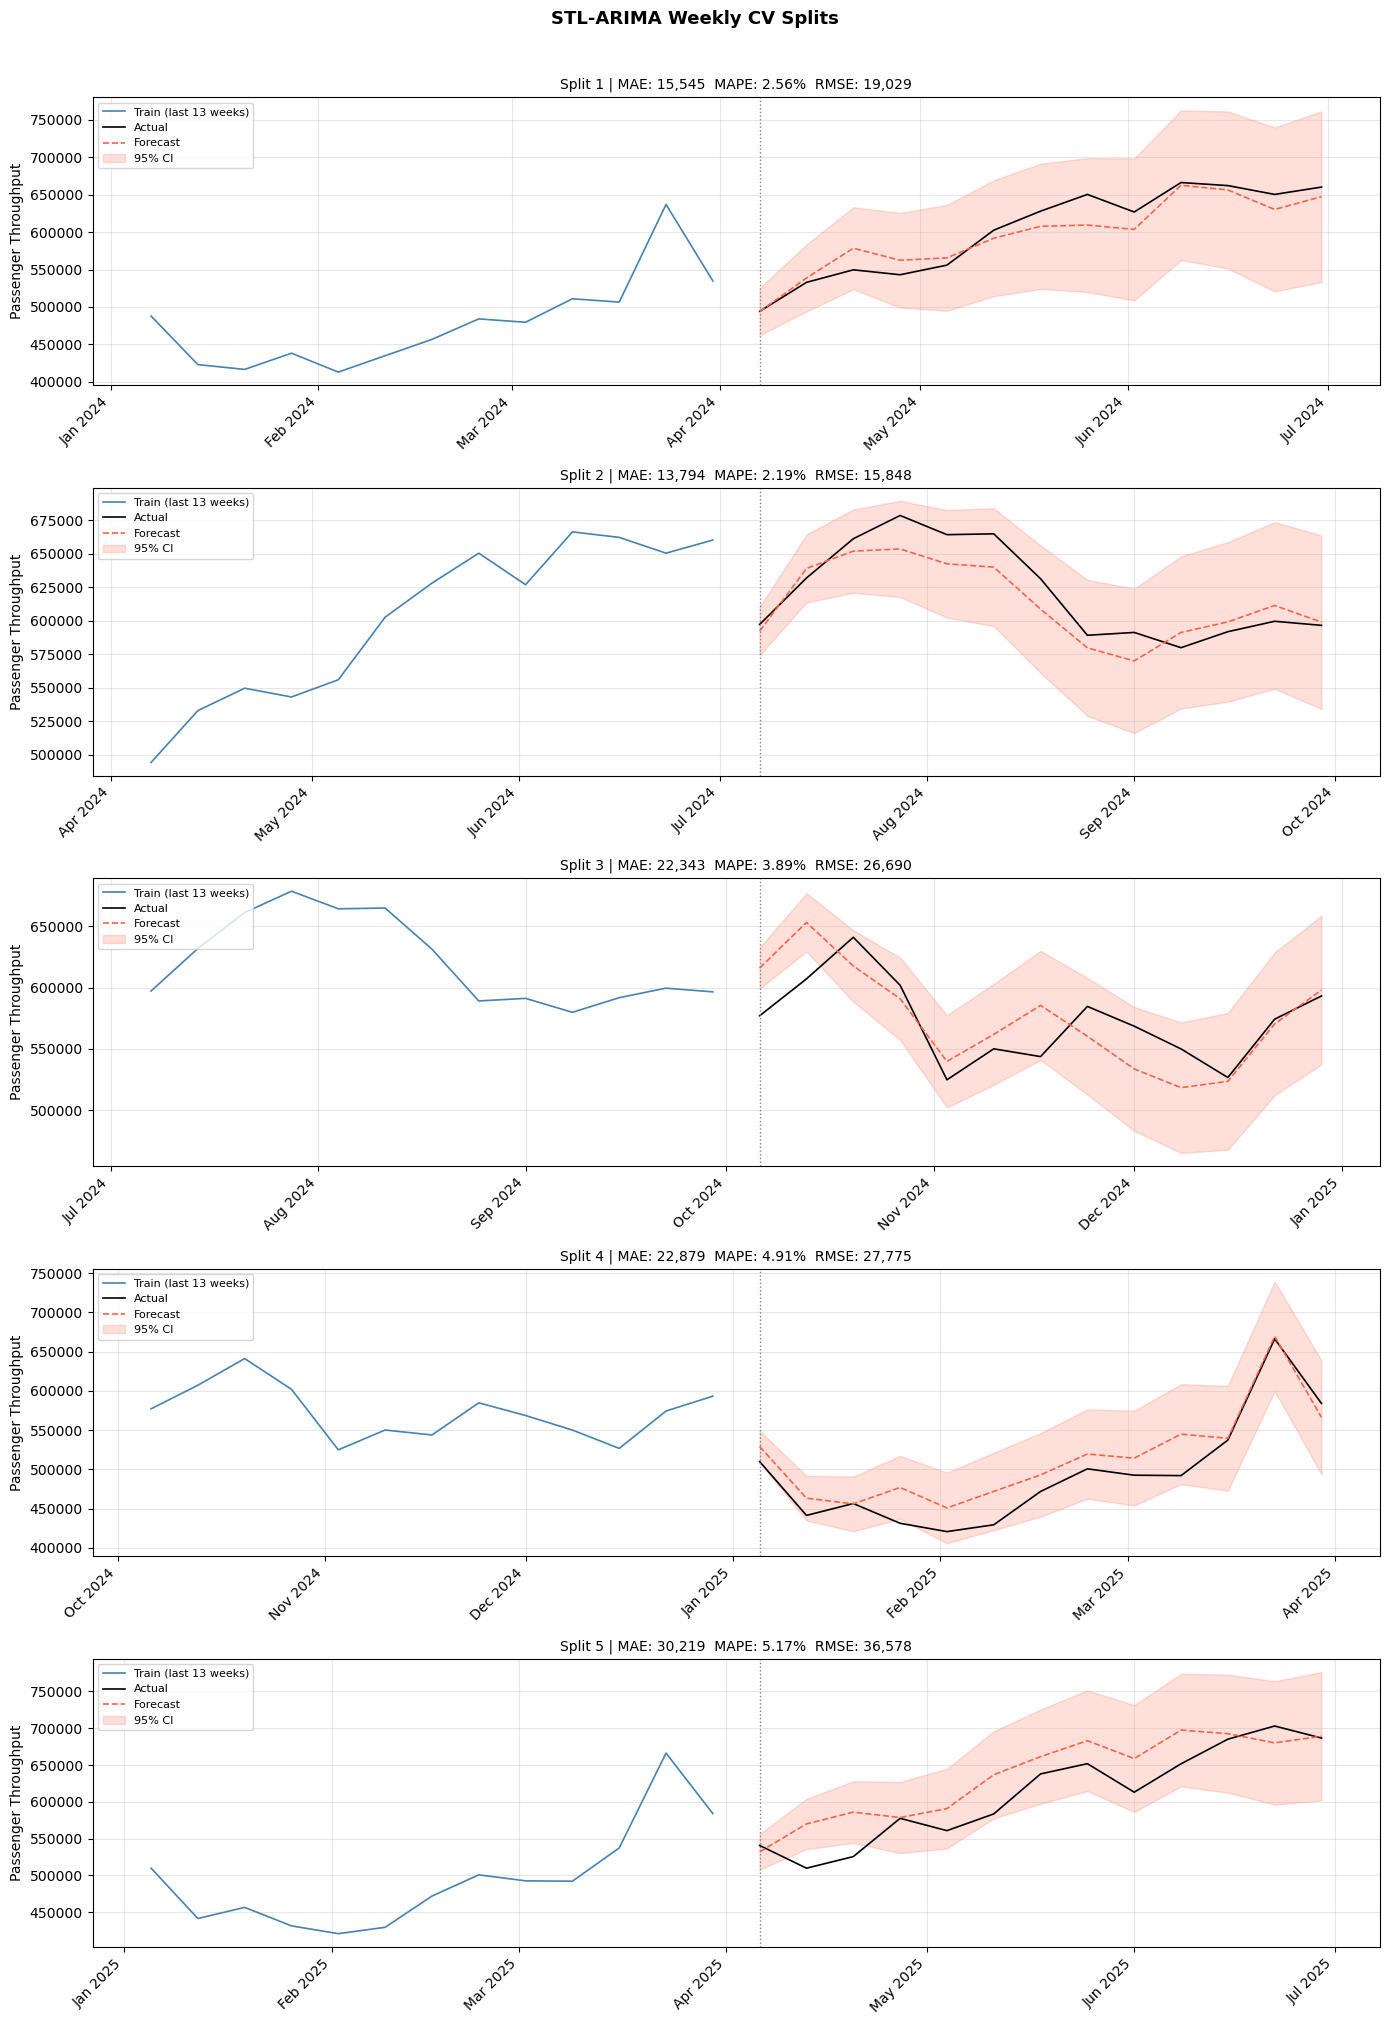

In [36]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(splits_w), 1, figsize=(14, 4 * len(splits_w)))
axes = axes if hasattr(axes, '__len__') else [axes]  # handle single split edge case

for i, (train_idx, test_idx) in enumerate(splits_w):
    ax = axes[i]

    train = ord_weekly.iloc[train_idx]
    test  = ord_weekly.iloc[test_idx]
    n_forecast = len(test_idx)

    model = STLArima(season_length=52, arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
    model.fit(train['total_passenger_throughput'])
    forecasts, lower_bound, upper_bound = model.forecast(n_forecast)

    actuals = test['total_passenger_throughput']
    metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")
    metrics['split'] = i + 1
    results_stl_w.append(metrics)

    # --- Plotting ---
    train_dates = train.datetime
    test_dates  = test.datetime

    # Plot last N days of training data for context
    context_window = min(13, len(train))
    ax.plot(train_dates.iloc[-context_window:],
            train['total_passenger_throughput'].iloc[-context_window:],
            color='steelblue', label='Train (last 13 weeks)', linewidth=1.2)

    # Actuals in test window
    ax.plot(test_dates, actuals,
            color='black', label='Actual', linewidth=1.2)

    # Forecast
    ax.plot(test_dates, forecasts,
            color='tomato', label='Forecast', linewidth=1.2, linestyle='--')

    # 95% Confidence interval
    ax.fill_between(test_dates, lower_bound, upper_bound,
                    color='tomato', alpha=0.2, label='95% CI')

    # Vertical line separating train/test
    ax.axvline(x=test_dates.iloc[0], color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f"Split {i+1} | MAE: {metrics['mae']:,.0f}  "
        f"MAPE: {100*metrics['mape']:.2f}%  "
        f"RMSE: {metrics['rmse']:,.0f}",
        fontsize=10
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Passenger Throughput')
    ax.grid(True, alpha=0.3)

plt.suptitle('STL-ARIMA Weekly CV Splits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Harmonic ARIMA - Weekly

For Harmonic ARIMA, first we must determine the optimal number of frequencies to use in the Harmonic part of the model. We do so by modeling the data using Linear Regression with the Fourier features.


Minimum metrics:
  MAE:  (2, 54,702)
  MAPE: (2, 0.09%)
  RMSE: (24, 60,970)


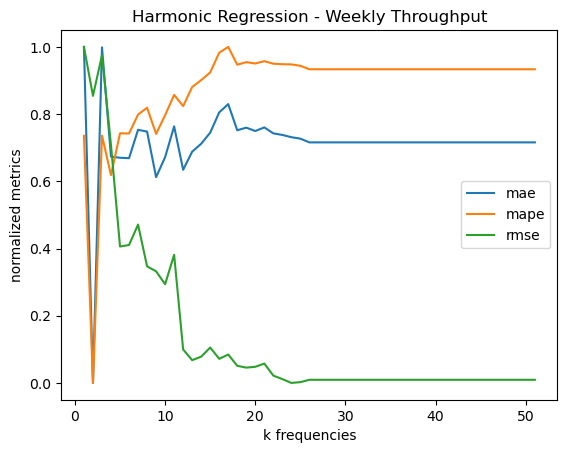

In [37]:
# Average the metrics over all folds for each choice of k_frequency
results = []

for k_freq in range(1, 52):
    # Determine Fourier features for the given number of frequencies
    ord_weekly_X = fourier_features(ord_weekly['week'], m=52, k=k_freq)
    
    k_metrics = []

    for i, (train_idx, test_idx) in enumerate(splits_w, start = 1):
        X_train = ord_weekly_X[train_idx]
        X_test  = ord_weekly_X[test_idx]
        y_train = ord_weekly.iloc[train_idx].total_passenger_throughput
        y_test  = ord_weekly.iloc[test_idx].total_passenger_throughput

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = evaluate_forecast(y_test, y_pred, f"Split {i}")
        metrics['split'] = i
        k_metrics.append(metrics)
    
    metrics_df = pd.DataFrame(k_metrics).set_index('split')
    mean_metrics = {}
    mean_metrics['k_freq'] = k_freq
    mean_metrics['mae']  = metrics_df['mae'].mean()
    mean_metrics['mape'] = metrics_df['mape'].mean()
    mean_metrics['rmse'] = metrics_df['rmse'].mean()
    results.append(mean_metrics)

results_df = pd.DataFrame(results).set_index('k_freq')

print(f"\nMinimum metrics:")
print(f"  MAE:  ({results_df['mae'].idxmin()}, {results_df['mae'].min():,.0f})")
print(f"  MAPE: ({results_df['mape'].idxmin()}, {results_df['mape'].min():.2f}%)")
print(f"  RMSE: ({results_df['rmse'].idxmin()}, {results_df['rmse'].min():,.0f})")

# Normalize all metrics between 0 and 1 for comparison
results_df = (results_df - results_df.min()) / (results_df.max() - results_df.min())
results_df.plot()
plt.title('Harmonic Regression - Weekly Throughput')
plt.xlabel('k frequencies')
plt.ylabel('normalized metrics')
plt.legend()
plt.show()

Unlike with the daily data, this model doesn't appear to attain a minimum in the number of harmonic features to use. Based on the plot above, it appears that the best choice is about k = 25.

We can now apply `autoarima` using the optimal number of Fourier features and the largest set of training data. This will allow us to determine the optimal SARIMA model to use to capture the weekly trend and the errors in the data.

In [41]:
# Create optimal number of Fourier features to model annual trend
ord_weekly_X = fourier_features(ord_weekly['week'], m=52, k=25)
# Take largest split for determining optimal SARIMA model
X_train = ord_weekly_X[splits_w[-1][0]]
X_test  = ord_weekly_X[splits_w[-1][1]]
y_train = ord_weekly.iloc[splits_w[-1][0]].total_passenger_throughput
y_test  = ord_weekly.iloc[splits_w[-1][1]].total_passenger_throughput

arima_model = auto_arima(
    y_train,
    X=X_train,
    seasonal=False,
    d=1, # d = 1 captures linear trend
    stepwise=True,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3826.251, Time=1.10 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3829.087, Time=0.40 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3831.022, Time=0.40 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3834.154, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=4521.596, Time=0.31 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=3837.616, Time=0.69 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=3836.838, Time=0.80 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=3830.669, Time=1.21 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=3836.933, Time=1.39 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3837.791, Time=0.60 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=3841.723, Time=1.00 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=3832.799, Time=0.90 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=2.00 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=inf, Time=1.60 sec

Best model:  ARIMA(2,1,2)(0,0,0)[0] interc

After running the `autoarima`, we find that the optimal ARIMA model is `ARIMA(2,1,2)(0,0,0)[0]` with intercept.

Finally, we can apply this model across all the splits and see what metrics we obtain.

In [38]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

results_harm_arima_w = []

for i, (train_idx, test_idx) in enumerate(splits_w, start=1):
        train = ord_weekly.iloc[train_idx]
        test  = ord_weekly.iloc[test_idx]

        model = HarmonicARIMA(harmonic_m=52,
                              harmonic_k=25,
                              arima_order=(2,1,2), 
                              seasonal_order=(0,0,0,0),
                              with_intercept=True)
        model.fit(train.week, train.total_passenger_throughput)
        forecasts, lower_bound, upper_bound = model.forecast(test.week)

        metrics = evaluate_forecast(test.total_passenger_throughput, forecasts, model_name=f"Split {i}")
        metrics['split'] = i
        results_harm_arima_w.append(metrics)
        print(f"Split {i} - MAE: {metrics['mae']:.0f}, MAPE: {100*metrics['mape']:.2f}%, RMSE: {metrics['rmse']:.0f}")
        
results_harm_arima_w_df = pd.DataFrame(results_harm_arima_w).set_index('split')
print("\nCV Average:")
print(f"  MAE:  {results_harm_arima_w_df['mae'].mean():,.0f}")
print(f"  MAPE: {results_harm_arima_w_df['mape'].mean()*100:.2f}%")
print(f"  RMSE: {results_harm_arima_w_df['rmse'].mean():,.0f}")

Split 1 - MAE: 18448, MAPE: 2.95%, RMSE: 22461
Split 2 - MAE: 19708, MAPE: 3.26%, RMSE: 23615
Split 3 - MAE: 23174, MAPE: 4.06%, RMSE: 26244
Split 4 - MAE: 32146, MAPE: 6.74%, RMSE: 39171
Split 5 - MAE: 29059, MAPE: 5.03%, RMSE: 36518

CV Average:
  MAE:  24,507
  MAPE: 4.41%
  RMSE: 29,602


Based on these metrics, this model doesn't appear to perform as well as the STL ARIMA model. It also doesn't beat one of the baselines.

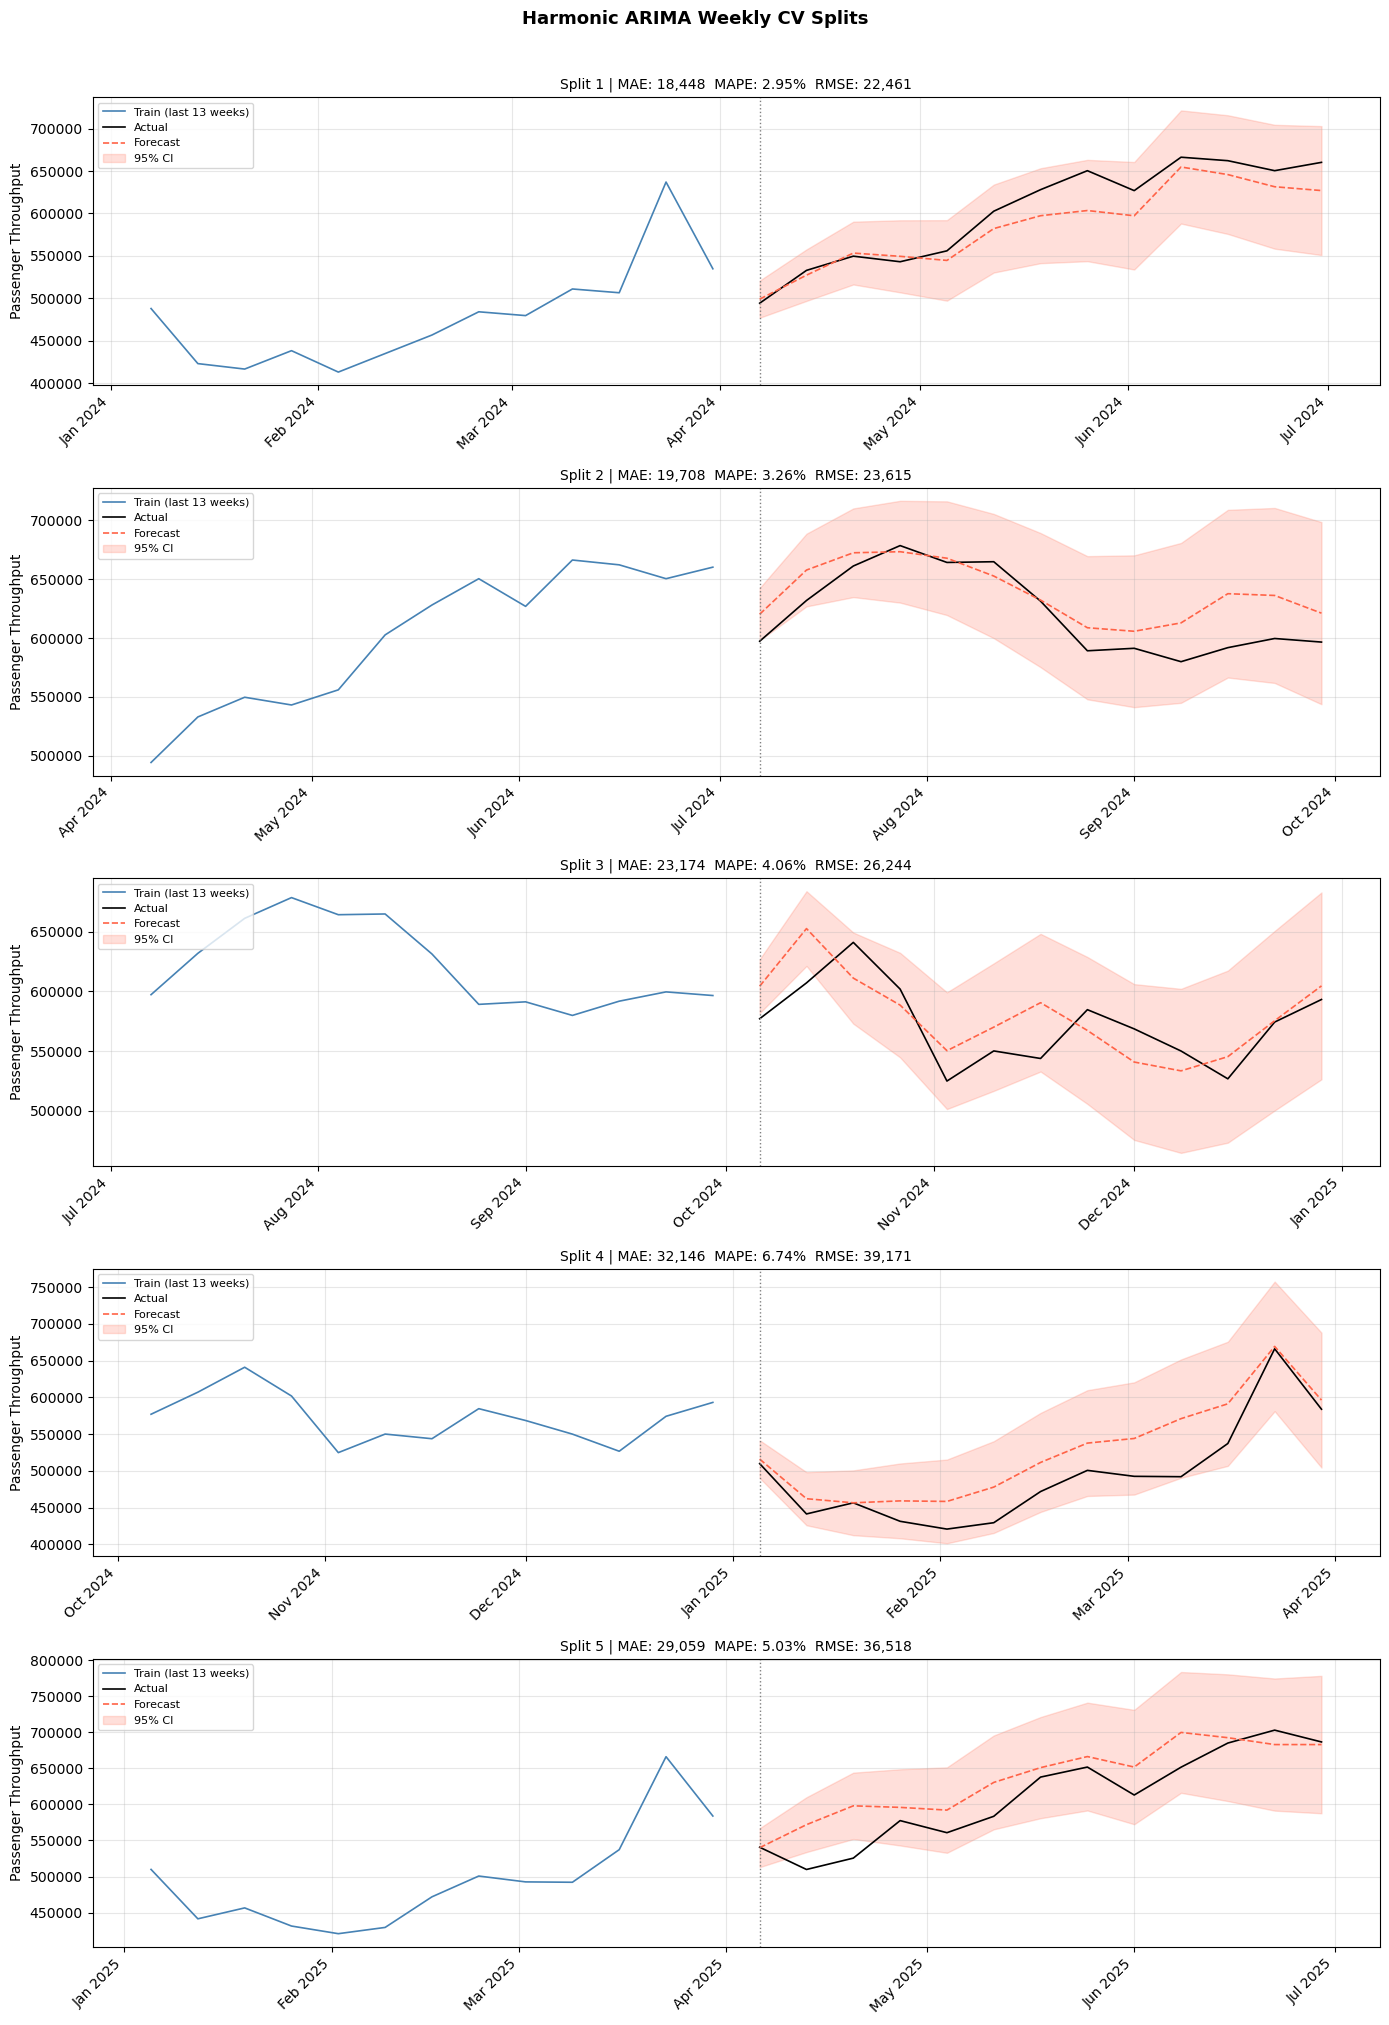

In [39]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(len(splits_w), 1, figsize=(14, 4 * len(splits_w)))
axes = axes if hasattr(axes, '__len__') else [axes]  # handle single split edge case

for i, (train_idx, test_idx) in enumerate(splits_w):
    ax = axes[i]

    train = ord_weekly.iloc[train_idx]
    test  = ord_weekly.iloc[test_idx]

    model = HarmonicARIMA(harmonic_m=52,
                          harmonic_k=25,
                          arima_order=(2,1,2), 
                          seasonal_order=(0,0,0,0),
                          with_intercept=True)
    model.fit(train.week, train.total_passenger_throughput)
    forecasts, lower_bound, upper_bound = model.forecast(test.week)

    actuals = test.total_passenger_throughput
    metrics = evaluate_forecast(actuals, forecasts, model_name=f"Split {i+1}")

    # --- Plotting ---
    train_dates = train.datetime
    test_dates  = test.datetime

    # Plot last N days of training data for context
    context_window = min(13, len(train))
    ax.plot(train_dates.iloc[-context_window:],
            train['total_passenger_throughput'].iloc[-context_window:],
            color='steelblue', label='Train (last 13 weeks)', linewidth=1.2)

    # Actuals in test window
    ax.plot(test_dates, actuals,
            color='black', label='Actual', linewidth=1.2)

    # Forecast
    ax.plot(test_dates, forecasts,
            color='tomato', label='Forecast', linewidth=1.2, linestyle='--')

    # 95% Confidence interval
    ax.fill_between(test_dates, lower_bound, upper_bound,
                    color='tomato', alpha=0.2, label='95% CI')

    # Vertical line separating train/test
    ax.axvline(x=test_dates.iloc[0], color='gray', linestyle=':', linewidth=1)

    ax.set_title(
        f"Split {i+1} | MAE: {metrics['mae']:,.0f}  "
        f"MAPE: {100*metrics['mape']:.2f}%  "
        f"RMSE: {metrics['rmse']:,.0f}",
        fontsize=10
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('Passenger Throughput')
    ax.grid(True, alpha=0.3)

plt.suptitle('Harmonic ARIMA Weekly CV Splits', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Evaluation

Let's see how our accurate our model predictions are on the testing data. We split the testing data (July 1, 2025 - Dec 31,2025) in two. So for the first set of predictions we will train on all the data upto June 30, 2025 and test it on the next 90 days. For the second set, we extend the training data by another 90 days, and test it on the remainder of 2025. 

Initialise all models

In [54]:
harmonic_model = HarmonicARIMA(harmonic_m=365,
                      harmonic_k=18,
                      arima_order=(4,1,2), 
                      seasonal_order=(1,0,1,7),
                      with_intercept=False)

stl_model = STLArima(season_length=365, arima_order=(5,1,5), seasonal_order=(2,0,2,7))
data = load_data("data/tsa-throughput-data-complete.csv")

In [55]:

ord_daily = retrieve_airport_data(data, airport="ORD", frequency="D")
JFK_daily = retrieve_airport_data(data, airport="JFK", frequency="D")
LAX_daily = retrieve_airport_data(data, airport="LAX", frequency="D")
DFW_daily = retrieve_airport_data(data, airport="DFW", frequency="D")
DEN_daily = retrieve_airport_data(data, airport="DEN", frequency="D")
DTW_daily = retrieve_airport_data(data, airport="DTW", frequency="D")

In [56]:
ORD_daily_train1 = ord_daily[ord_daily["datetime"] <= "2025-06-30"] #first training split is 2022-01-02 to 2025-06-30
ORD_daily_test1  = ord_daily[(ord_daily["datetime"] >= "2025-07-01") & (ord_daily["datetime"] < "2025-09-29")] #first test split is 2025-07-01 to 2025-09-28 (90 days)
ORD_daily_train2 = ord_daily[ord_daily["datetime"] < "2025-09-29"]#second training split is 2022-01-02 to 2025-09-28
ORD_daily_test2  =ord_daily[(ord_daily["datetime"] >= "2025-09-29")]#second test split is 2025-09-29 to 2025-12-31 (93 days)

JFK_daily_train1 = JFK_daily[JFK_daily["datetime"] <= "2025-06-30"] #first training split is 2022-01-02 to 2025-06-30
JFK_daily_test1  = JFK_daily[(JFK_daily["datetime"] >= "2025-07-01") & (JFK_daily["datetime"] < "2025-09-29")] #first test split is 2025-07-01 to 2025-09-28 (90 days)
JFK_daily_train2 = JFK_daily[JFK_daily["datetime"] < "2025-09-29"]#second training split is 2022-01-02 to 2025-09-28
JFK_daily_test2  = JFK_daily[(JFK_daily["datetime"] >= "2025-09-29")]#second test split is 2025-09-29 to 2025-12-31 (93 days)

LAX_daily_train1 = LAX_daily[LAX_daily["datetime"] <= "2025-06-30"] #first training split is 2022-01-02 to 2025-06-30
LAX_daily_test1  = LAX_daily[(LAX_daily["datetime"] >= "2025-07-01") & (LAX_daily["datetime"] < "2025-09-29")] #first test split is 2025-07-01 to 2025-09-28 (90 days)
LAX_daily_train2 = LAX_daily[LAX_daily["datetime"] < "2025-09-29"]#second training split is 2022-01-02 to 2025-09-28
LAX_daily_test2  = LAX_daily[(LAX_daily["datetime"] >= "2025-09-29")]#second test split is 2025-09-29 to 2025-12-31 (93 days)

DFW_daily_train1 = DFW_daily[DFW_daily["datetime"] <= "2025-06-30"] #first training split is 2022-01-02 to 2025-06-30
DFW_daily_test1  = DFW_daily[(DFW_daily["datetime"] >= "2025-07-01") & (DFW_daily["datetime"] < "2025-09-29")] #first test split is 2025-07-01 to 2025-09-28 (90 days)
DFW_daily_train2 = DFW_daily[DFW_daily["datetime"] < "2025-09-29"]#second training split is 2022-01-02 to 2025-09-28
DFW_daily_test2  = DFW_daily[(DFW_daily["datetime"] >= "2025-09-29")]#second test split is 2025-09-29 to 2025-12-31 (93 days)

DEN_daily_train1 = DEN_daily[DEN_daily["datetime"] <= "2025-06-30"] #first training split is 2022-01-02 to 2025-06-30
DEN_daily_test1  = DEN_daily[(DEN_daily["datetime"] >= "2025-07-01") & (DEN_daily["datetime"] < "2025-09-29")] #first test split is 2025-07-01 to 2025-09-28 (90 days)
DEN_daily_train2 = DEN_daily[DEN_daily["datetime"] < "2025-09-29"]#second training split is 2022-01-02 to 2025-09-28
DEN_daily_test2  = DEN_daily[(DEN_daily["datetime"] >= "2025-09-29")]#second test split is 2025-09-29 to 2025-12-31 (93 days)

DTW_daily_train1 = DTW_daily[DTW_daily["datetime"] <= "2025-06-30"] #first training split is 2022-01-02 to 2025-06-30
DTW_daily_test1  = DTW_daily[(DTW_daily["datetime"] >= "2025-07-01") & (DTW_daily["datetime"] < "2025-09-29")] #first test split is 2025-07-01 to 2025-09-28 (90 days)
DTW_daily_train2 = DTW_daily[DTW_daily["datetime"] < "2025-09-29"]#second training split is 2022-01-02 to 2025-09-28
DTW_daily_test2  = DTW_daily[(DTW_daily["datetime"] >= "2025-09-29")]#second test split is 2025-09-29 to 2025-12-31 (93 days)

### Harmonic ARIMA - Daily Data - ORD

First, we evaluate our HarmonicARIMA model for the daily passenger throughput. For each of the two quarters in the test set, we train our model on the entire passenger throughput data up to the first date of the quarter and obtain diagnostics of the model performance.

Final Harmonic ARIMA on Test Set from 2025-07-01 to 2025-09-28 - MAE: 5844, MAPE: 6.42%, RMSE: 7345
Final Harmonic ARIMA on Test Set from 2025-09-29 to 2025-12-30 - MAE: 6469, MAPE: 8.11%, RMSE: 8542


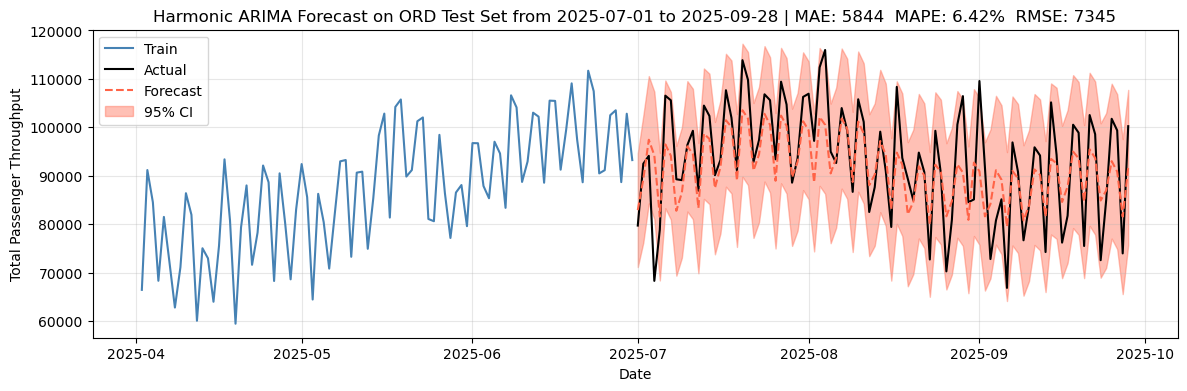

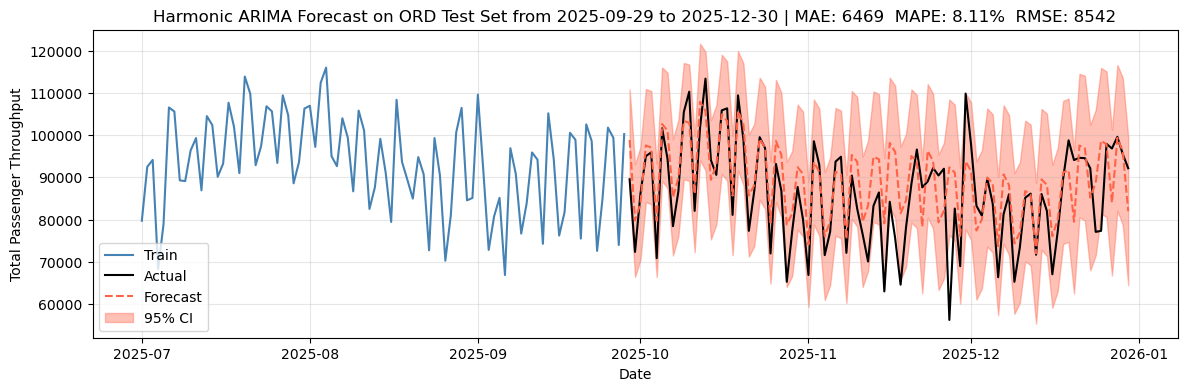

In [57]:
## Fitting the model on the first training set and evaluating on the first test set
harmonic_model.fit(ORD_daily_train1.day, ORD_daily_train1.total_passenger_throughput)
harmonic_ORD_forecasts1, harmonic_ORD_lower_bound1, harmonic_ORD_upper_bound1 = harmonic_model.forecast(ORD_daily_test1.day)

ORD_actuals1 = ORD_daily_test1.total_passenger_throughput
metrics1 = evaluate_forecast(ORD_actuals1, harmonic_ORD_forecasts1, model_name=f"Final Harmonic ARIMA on Test Set from {ORD_daily_test1.datetime.min().date()} to {ORD_daily_test1.datetime.max().date()}")
print(f"Final Harmonic ARIMA on Test Set from {ORD_daily_test1.datetime.min().date()} to {ORD_daily_test1.datetime.max().date()} - MAE: {metrics1['mae']:.0f}, MAPE: {100*metrics1['mape']:.2f}%, RMSE: {metrics1['rmse']:.0f}")

## Fitting the model on the second training set and evaluating on the second test set
harmonic_model.fit(ORD_daily_train2.day, ORD_daily_train2.total_passenger_throughput)
harmonic_ORD_forecasts2, harmonic_ORD_lower_bound2, harmonic_ORD_upper_bound2 = harmonic_model.forecast(ORD_daily_test2.day)

ORD_actuals2 = ORD_daily_test2.total_passenger_throughput
metrics2 = evaluate_forecast(ORD_actuals2, harmonic_ORD_forecasts2, model_name=f"Final Harmonic ARIMA on Test Set from {ORD_daily_test2.datetime.min().date()} to {ORD_daily_test2.datetime.max().date()}")
print(f"Final Harmonic ARIMA on Test Set from {ORD_daily_test2.datetime.min().date()} to {ORD_daily_test2.datetime.max().date()} - MAE: {metrics2['mae']:.0f}, MAPE: {100*metrics2['mape']:.2f}%, RMSE: {metrics2['rmse']:.0f}")


plt.figure(figsize=(14,4))
plt.plot(ORD_daily_train1.datetime.iloc[-90:], ORD_daily_train1.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(ORD_daily_test1.datetime, ORD_daily_test1.total_passenger_throughput, label='Actual', color='black')
plt.plot(ORD_daily_test1.datetime, harmonic_ORD_forecasts1, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(ORD_daily_test1.datetime, harmonic_ORD_lower_bound1, harmonic_ORD_upper_bound1, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"Harmonic ARIMA Forecast on ORD Test Set from {ORD_daily_test1.datetime.min().date()} to {ORD_daily_test1.datetime.max().date()} | MAE: {metrics1['mae']:.0f}  MAPE: {100*metrics1['mape']:.2f}%  RMSE: {metrics1['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/harmonic_arima_ord_daily_test1.png", bbox_inches='tight')
plt.show()



plt.figure(figsize=(14,4))
plt.plot(ORD_daily_train2.datetime.iloc[-90:], ORD_daily_train2.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(ORD_daily_test2.datetime, ORD_daily_test2.total_passenger_throughput, label='Actual', color='black')
plt.plot(ORD_daily_test2.datetime, harmonic_ORD_forecasts2, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(ORD_daily_test2.datetime, harmonic_ORD_lower_bound2, harmonic_ORD_upper_bound2, color='tomato', alpha=0.4,  label='95% CI')
plt.title(f"Harmonic ARIMA Forecast on ORD Test Set from {ORD_daily_test2.datetime.min().date()} to {ORD_daily_test2.datetime.max().date()} | MAE: {metrics2['mae']:.0f}  MAPE: {100*metrics2['mape']:.2f}%  RMSE: {metrics2['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/harmonic_arima_ord_daily_test2.png", bbox_inches='tight')
plt.show()

### STL ARIMA - Daily Data - ORD

Plots of our predictions for the two quarters of our test set obtained using the STLARIMA model

Final STL ARIMA on Test Set from 2025-07-01 to 2025-09-28 - MAE: 10776, MAPE: 11.86%, RMSE: 13435
Final STL ARIMA on Test Set from 2025-09-29 to 2025-12-30 - MAE: 11197, MAPE: 13.58%, RMSE: 13806


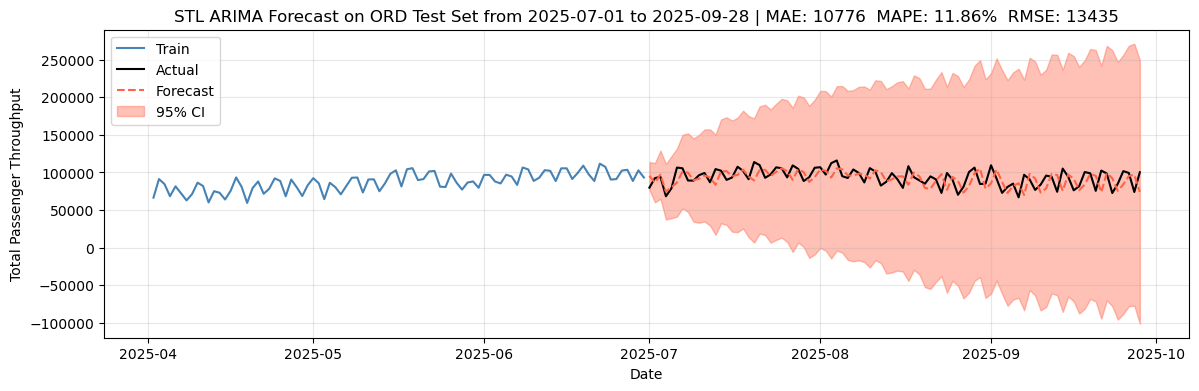

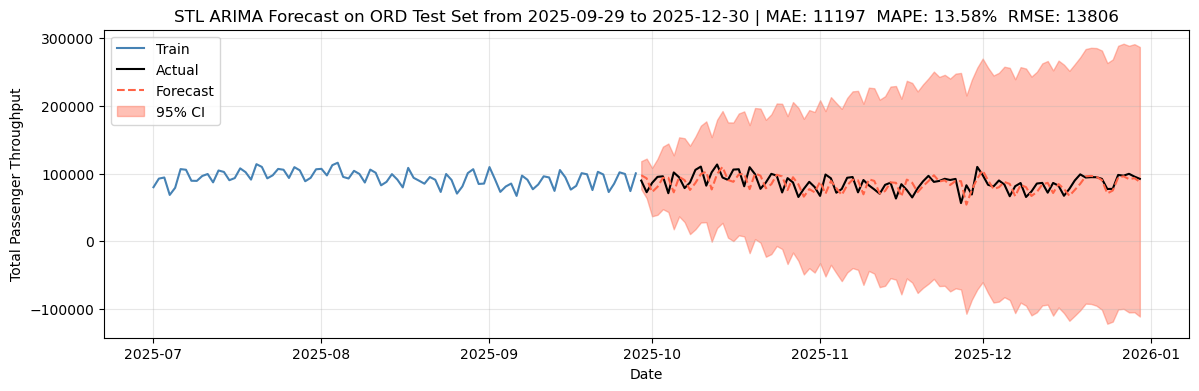

In [58]:
stl_model = STLArima(season_length=365, arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
stl_model.fit(ORD_daily_train1['total_passenger_throughput'])
stl_ORD_forecasts1, stl_ORD_lower_bound1, stl_ORD_upper_bound1 = stl_model.forecast(len(ORD_daily_test1))
ORD_actuals1 = ORD_daily_test1['total_passenger_throughput']
metrics1 = evaluate_forecast(ORD_actuals1, stl_ORD_forecasts1, model_name=f"Final STL ARIMA on Test Set from {ORD_daily_test1.datetime.min().date()} to {ORD_daily_test1.datetime.max().date()}")
print(f"Final STL ARIMA on Test Set from {ORD_daily_test1.datetime.min().date()} to {ORD_daily_test1.datetime.max().date()} - MAE: {metrics1['mae']:.0f}, MAPE: {100*metrics1['mape']:.2f}%, RMSE: {metrics1['rmse']:.0f}")

#model1 = STLArima(season_length=365, arima_order=(p,d,q), seasonal_order=(P,D,Q,s))
stl_model.fit(ORD_daily_train2['total_passenger_throughput'])
stl_ORD_forecasts2, stl_ORD_lower_bound2, stl_ORD_upper_bound2 = stl_model.forecast(len(ORD_daily_test2))
ORD_actuals2 = ORD_daily_test2['total_passenger_throughput']
metrics2 = evaluate_forecast(ORD_actuals2, stl_ORD_forecasts2, model_name=f"Final STL ARIMA on Test Set from {ORD_daily_test2.datetime.min().date()} to {ORD_daily_test2.datetime.max().date()}")
print(f"Final STL ARIMA on Test Set from {ORD_daily_test2.datetime.min().date()} to {ORD_daily_test2.datetime.max().date()} - MAE: {metrics2['mae']:.0f}, MAPE: {100*metrics2['mape']:.2f}%, RMSE: {metrics2['rmse']:.0f}") 

plt.figure(figsize=(14,4))
plt.plot(ORD_daily_train1.datetime.iloc[-90:], ORD_daily_train1.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(ORD_daily_test1.datetime, ORD_daily_test1.total_passenger_throughput, label='Actual', color='black')
plt.plot(ORD_daily_test1.datetime, stl_ORD_forecasts1, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(ORD_daily_test1.datetime, stl_ORD_lower_bound1, stl_ORD_upper_bound1, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"STL ARIMA Forecast on ORD Test Set from {ORD_daily_test1.datetime.min().date()} to {ORD_daily_test1.datetime.max().date()} | MAE: {metrics1['mae']:.0f}  MAPE: {100*metrics1['mape']:.2f}%  RMSE: {metrics1['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/stl_arima_ord_daily_test1.png", bbox_inches='tight')
plt.show()


plt.figure(figsize=(14,4))
plt.plot(ORD_daily_train2.datetime.iloc[-90:], ORD_daily_train2.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(ORD_daily_test2.datetime, ORD_daily_test2.total_passenger_throughput, label='Actual', color='black')
plt.plot(ORD_daily_test2.datetime, stl_ORD_forecasts2, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(ORD_daily_test2.datetime, stl_ORD_lower_bound2, stl_ORD_upper_bound2, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"STL ARIMA Forecast on ORD Test Set from {ORD_daily_test2.datetime.min().date()} to {ORD_daily_test2.datetime.max().date()} | MAE: {metrics2['mae']:.0f}  MAPE: {100*metrics2['mape']:.2f}%  RMSE: {metrics2['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/stl_arima_ord_daily_test2.png", bbox_inches='tight')
plt.show()

### Harmonic ARIMA - Daily Data - JFK

Final Harmonic ARIMA on JFK Test Set from 2025-07-01 to 2025-09-28 - MAE: 4033, MAPE: 4.29%, RMSE: 5784
Final Harmonic ARIMA on JFK Test Set from 2025-09-29 to 2025-12-30 - MAE: 5002, MAPE: 5.69%, RMSE: 6663


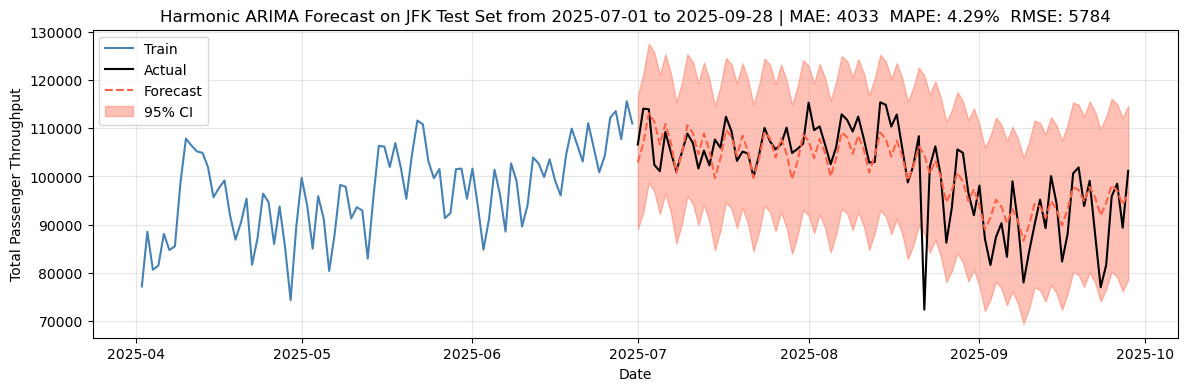

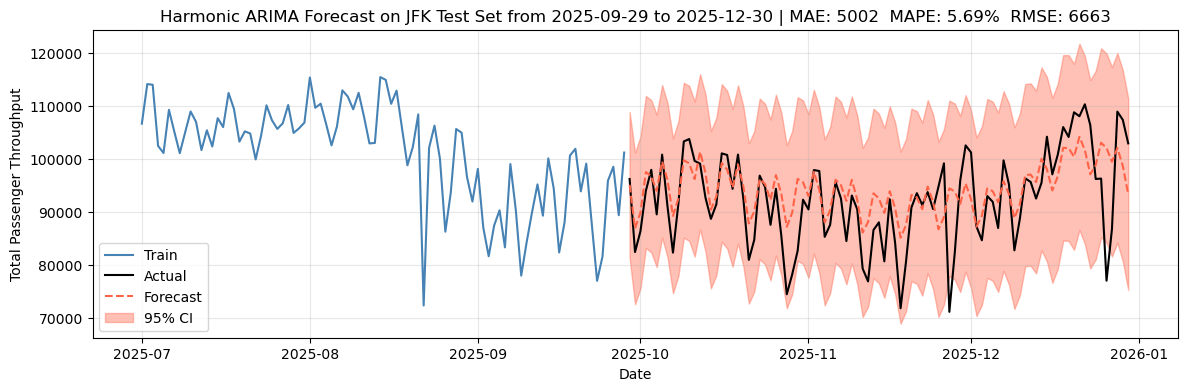

In [59]:
harmonic_model.fit(JFK_daily_train1.day, JFK_daily_train1.total_passenger_throughput)
harmonic_JFK_forecasts1, harmonic_JFK_lower_bound1, harmonic_JFK_upper_bound1 = harmonic_model.forecast(JFK_daily_test1.day)
JFK_actuals1 = JFK_daily_test1.total_passenger_throughput
metrics1 = evaluate_forecast(JFK_actuals1, harmonic_JFK_forecasts1, model_name=f"Final Harmonic ARIMA on JFK Test Set from {JFK_daily_test1.datetime.min().date()} to {JFK_daily_test1.datetime.max().date()}")
print(f"Final Harmonic ARIMA on JFK Test Set from {JFK_daily_test1.datetime.min().date()} to {JFK_daily_test1.datetime.max().date()} - MAE: {metrics1['mae']:.0f}, MAPE: {100*metrics1['mape']:.2f}%, RMSE: {metrics1['rmse']:.0f}")

harmonic_model.fit(JFK_daily_train2.day, JFK_daily_train2.total_passenger_throughput)
harmonic_JFK_forecasts2, harmonic_JFK_lower_bound2, harmonic_JFK_upper_bound2 = harmonic_model.forecast(JFK_daily_test2.day)
JFK_actuals2 = JFK_daily_test2.total_passenger_throughput
metrics2 = evaluate_forecast(JFK_actuals2, harmonic_JFK_forecasts2, model_name=f"Final Harmonic ARIMA on JFK Test Set from {JFK_daily_test2.datetime.min().date()} to {JFK_daily_test2.datetime.max().date()}")
print(f"Final Harmonic ARIMA on JFK Test Set from {JFK_daily_test2.datetime.min().date()} to {JFK_daily_test2.datetime.max().date()} - MAE: {metrics2['mae']:.0f}, MAPE: {100*metrics2['mape']:.2f}%, RMSE: {metrics2['rmse']:.0f}")

plt.figure(figsize=(14,4))
plt.plot(JFK_daily_train1.datetime.iloc[-90:], JFK_daily_train1.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(JFK_daily_test1.datetime, JFK_daily_test1.total_passenger_throughput, label='Actual', color='black')
plt.plot(JFK_daily_test1.datetime, harmonic_JFK_forecasts1, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(JFK_daily_test1.datetime, harmonic_JFK_lower_bound1, harmonic_JFK_upper_bound1, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"Harmonic ARIMA Forecast on JFK Test Set from {JFK_daily_test1.datetime.min().date()} to {JFK_daily_test1.datetime.max().date()} | MAE: {metrics1['mae']:.0f}  MAPE: {100*metrics1['mape']:.2f}%  RMSE: {metrics1['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/harmonic_arima_jfk_daily_test1.png", bbox_inches='tight')
plt.show()      

plt.figure(figsize=(14,4))
plt.plot(JFK_daily_train2.datetime.iloc[-90:], JFK_daily_train2.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(JFK_daily_test2.datetime, JFK_daily_test2.total_passenger_throughput, label='Actual', color='black')
plt.plot(JFK_daily_test2.datetime, harmonic_JFK_forecasts2, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(JFK_daily_test2.datetime, harmonic_JFK_lower_bound2, harmonic_JFK_upper_bound2, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"Harmonic ARIMA Forecast on JFK Test Set from {JFK_daily_test2.datetime.min().date()} to {JFK_daily_test2.datetime.max().date()} | MAE: {metrics2['mae']:.0f}  MAPE: {100*metrics2['mape']:.2f}%  RMSE: {metrics2['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/harmonic_arima_jfk_daily_test2.png", bbox_inches='tight')
plt.show()

### STL ARIMA - Daily Data - JFK

Final STL ARIMA on JFK Test Set from 2025-07-01 to 2025-09-28 - MAE: 6496, MAPE: 6.80%, RMSE: 9635
Final STL ARIMA on JFK Test Set from 2025-09-29 to 2025-12-30 - MAE: 7200, MAPE: 8.05%, RMSE: 9680


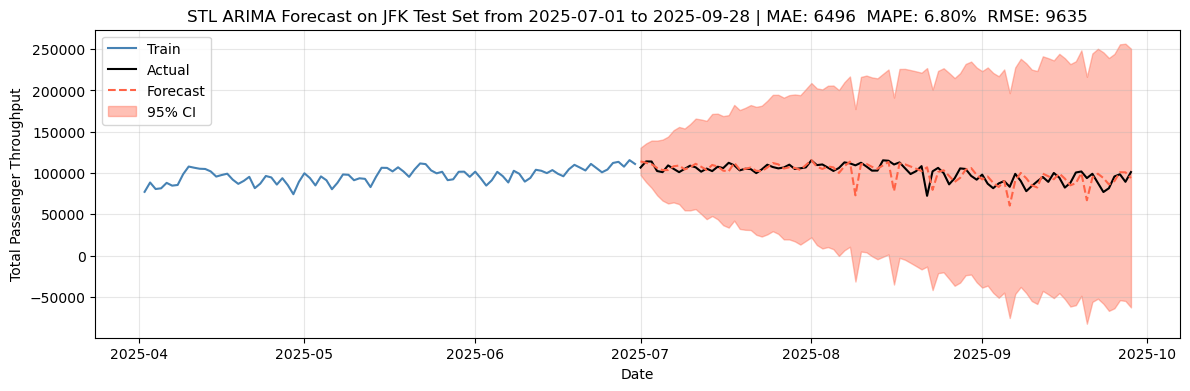

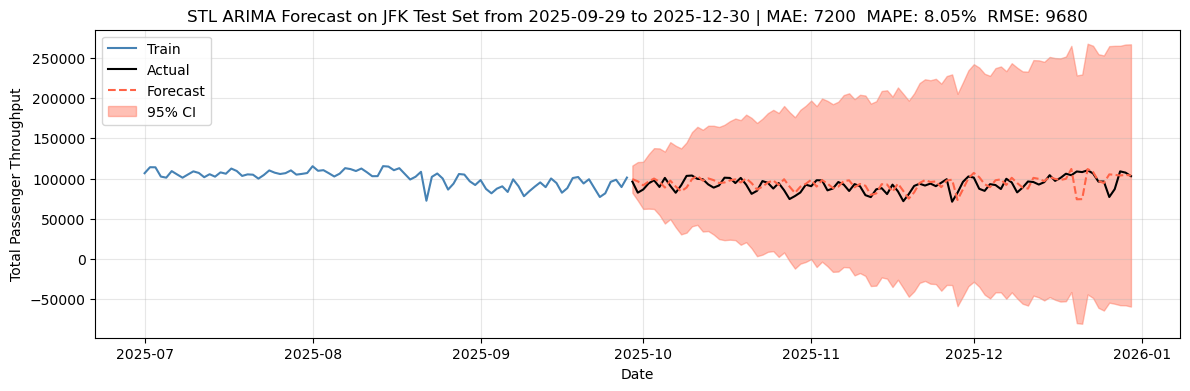

In [60]:
stl_model.fit(JFK_daily_train1['total_passenger_throughput'])
stl_JFK_forecasts1, stl_JFK_lower_bound1, stl_JFK_upper_bound1 = stl_model.forecast(len(JFK_daily_test1))
JFK_actuals1 = JFK_daily_test1['total_passenger_throughput']
metrics1 = evaluate_forecast(JFK_actuals1, stl_JFK_forecasts1, model_name=f"Final STL ARIMA on JFK Test Set from {JFK_daily_test1.datetime.min().date()} to {JFK_daily_test1.datetime.max().date()}")
print(f"Final STL ARIMA on JFK Test Set from {JFK_daily_test1.datetime.min().date()} to {JFK_daily_test1.datetime.max().date()} - MAE: {metrics1['mae']:.0f}, MAPE: {100*metrics1['mape']:.2f}%, RMSE: {metrics1['rmse']:.0f}")

stl_model.fit(JFK_daily_train2['total_passenger_throughput'])
stl_JFK_forecasts2, stl_JFK_lower_bound2, stl_JFK_upper_bound2 = stl_model.forecast(len(JFK_daily_test2))
JFK_actuals2 = JFK_daily_test2['total_passenger_throughput']
metrics2 = evaluate_forecast(JFK_actuals2, stl_JFK_forecasts2, model_name=f"Final STL ARIMA on JFK Test Set from {JFK_daily_test2.datetime.min().date()} to {JFK_daily_test2.datetime.max().date()}")
print(f"Final STL ARIMA on JFK Test Set from {JFK_daily_test2.datetime.min().date()} to {JFK_daily_test2.datetime.max().date()} - MAE: {metrics2['mae']:.0f}, MAPE: {100*metrics2['mape']:.2f}%, RMSE: {metrics2['rmse']:.0f}")

plt.figure(figsize=(14,4))
plt.plot(JFK_daily_train1.datetime.iloc[-90:], JFK_daily_train1.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(JFK_daily_test1.datetime, JFK_daily_test1.total_passenger_throughput, label='Actual', color='black')   
plt.plot(JFK_daily_test1.datetime, stl_JFK_forecasts1, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(JFK_daily_test1.datetime, stl_JFK_lower_bound1, stl_JFK_upper_bound1, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"STL ARIMA Forecast on JFK Test Set from {JFK_daily_test1.datetime.min().date()} to {JFK_daily_test1.datetime.max().date()} | MAE: {metrics1['mae']:.0f}  MAPE: {100*metrics1['mape']:.2f}%  RMSE: {metrics1['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/stl_arima_jfk_daily_test1.png", bbox_inches='tight')
plt.show()

plt.figure(figsize=(14,4))
plt.plot(JFK_daily_train2.datetime.iloc[-90:], JFK_daily_train2.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(JFK_daily_test2.datetime, JFK_daily_test2.total_passenger_throughput, label='Actual', color='black')
plt.plot(JFK_daily_test2.datetime, stl_JFK_forecasts2, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(JFK_daily_test2.datetime, stl_JFK_lower_bound2, stl_JFK_upper_bound2, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"STL ARIMA Forecast on JFK Test Set from {JFK_daily_test2.datetime.min().date()} to {JFK_daily_test2.datetime.max().date()} | MAE: {metrics2['mae']:.0f}  MAPE: {100*metrics2['mape']:.2f}%  RMSE: {metrics2['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/stl_arima_jfk_daily_test2.png", bbox_inches='tight')
plt.show()

### Harmonic ARIMA - Daily Data - LAX

Final Harmonic ARIMA on LAX Test Set from 2025-07-01 to 2025-09-28 - MAE: 4439, MAPE: 4.85%, RMSE: 6988
Final Harmonic ARIMA on LAX Test Set from 2025-09-29 to 2025-12-30 - MAE: 6661, MAPE: 7.36%, RMSE: 9303


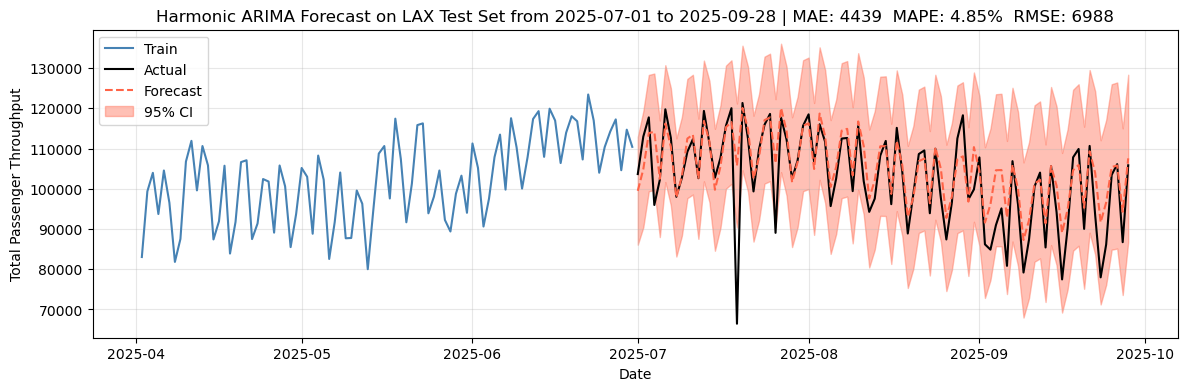

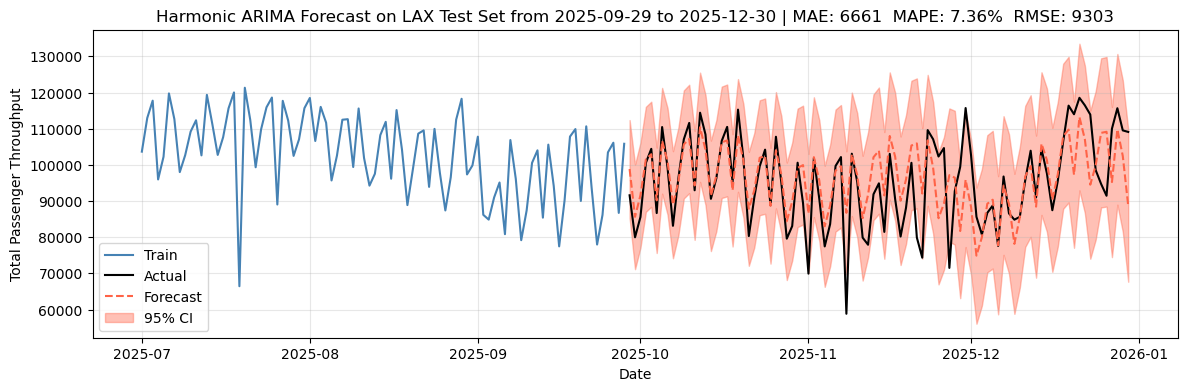

In [61]:
harmonic_model.fit(LAX_daily_train1.day, LAX_daily_train1.total_passenger_throughput)
harmonic_LAX_forecasts1, harmonic_LAX_lower_bound1, harmonic_LAX_upper_bound1 = harmonic_model.forecast(LAX_daily_test1.day)
LAX_actuals1 = LAX_daily_test1.total_passenger_throughput
metrics1 = evaluate_forecast(LAX_actuals1, harmonic_LAX_forecasts1, model_name=f"Final Harmonic ARIMA on LAX Test Set from {LAX_daily_test1.datetime.min().date()} to {LAX_daily_test1.datetime.max().date()}")
print(f"Final Harmonic ARIMA on LAX Test Set from {LAX_daily_test1.datetime.min().date()} to {LAX_daily_test1.datetime.max().date()} - MAE: {metrics1['mae']:.0f}, MAPE: {100*metrics1['mape']:.2f}%, RMSE: {metrics1['rmse']:.0f}")

harmonic_model.fit(LAX_daily_train2.day, LAX_daily_train2.total_passenger_throughput)
harmonic_LAX_forecasts2, harmonic_LAX_lower_bound2, harmonic_LAX_upper_bound2 = harmonic_model.forecast(LAX_daily_test2.day)
LAX_actuals2 = LAX_daily_test2.total_passenger_throughput
metrics2 = evaluate_forecast(LAX_actuals2, harmonic_LAX_forecasts2, model_name=f"Final Harmonic ARIMA on LAX Test Set from {LAX_daily_test2.datetime.min().date()} to {LAX_daily_test2.datetime.max().date()}")
print(f"Final Harmonic ARIMA on LAX Test Set from {LAX_daily_test2.datetime.min().date()} to {LAX_daily_test2.datetime.max().date()} - MAE: {metrics2['mae']:.0f}, MAPE: {100*metrics2['mape']:.2f}%, RMSE: {metrics2['rmse']:.0f}")

plt.figure(figsize=(14,4))
plt.plot(LAX_daily_train1.datetime.iloc[-90:], LAX_daily_train1.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(LAX_daily_test1.datetime, LAX_daily_test1.total_passenger_throughput, label='Actual', color='black')
plt.plot(LAX_daily_test1.datetime, harmonic_LAX_forecasts1, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(LAX_daily_test1.datetime, harmonic_LAX_lower_bound1, harmonic_LAX_upper_bound1, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"Harmonic ARIMA Forecast on LAX Test Set from {LAX_daily_test1.datetime.min().date()} to {LAX_daily_test1.datetime.max().date()} | MAE: {metrics1['mae']:.0f}  MAPE: {100*metrics1['mape']:.2f}%  RMSE: {metrics1['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/harmonic_arima_lax_daily_test1.png", bbox_inches='tight')
plt.show()

plt.figure(figsize=(14,4))
plt.plot(LAX_daily_train2.datetime.iloc[-90:], LAX_daily_train2.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(LAX_daily_test2.datetime, LAX_daily_test2.total_passenger_throughput, label='Actual', color='black')
plt.plot(LAX_daily_test2.datetime, harmonic_LAX_forecasts2, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(LAX_daily_test2.datetime, harmonic_LAX_lower_bound2, harmonic_LAX_upper_bound2, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"Harmonic ARIMA Forecast on LAX Test Set from {LAX_daily_test2.datetime.min().date()} to {LAX_daily_test2.datetime.max().date()} | MAE: {metrics2['mae']:.0f}  MAPE: {100*metrics2['mape']:.2f}%  RMSE: {metrics2['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/harmonic_arima_lax_daily_test2.png", bbox_inches='tight')
plt.show()




### STL ARIMA - Daily Data - LAX

Final STL ARIMA on LAX Test Set from 2025-07-01 to 2025-09-28 - MAE: 12663, MAPE: 13.26%, RMSE: 16087


Final STL ARIMA on LAX Test Set from 2025-09-29 to 2025-12-30 - MAE: 11989, MAPE: 13.49%, RMSE: 15605


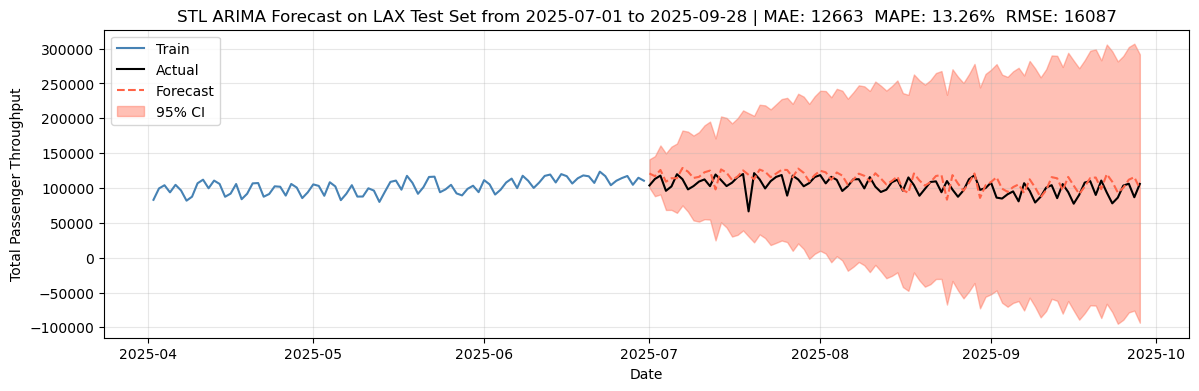

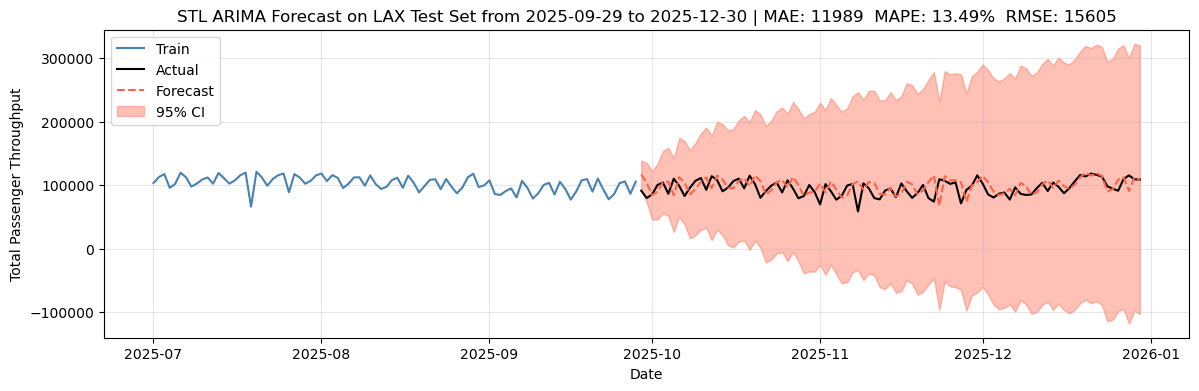

In [62]:
stl_model.fit(LAX_daily_train1['total_passenger_throughput'])
stl_LAX_forecasts1, stl_LAX_lower_bound1, stl_LAX_upper_bound1 = stl_model.forecast(len(LAX_daily_test1))
LAX_actuals1 = LAX_daily_test1['total_passenger_throughput']
metrics1 = evaluate_forecast(LAX_actuals1, stl_LAX_forecasts1, model_name=f"Final STL ARIMA on LAX Test Set from {LAX_daily_test1.datetime.min().date()} to {LAX_daily_test1.datetime.max().date()}")
print(f"Final STL ARIMA on LAX Test Set from {LAX_daily_test1.datetime.min().date()} to {LAX_daily_test1.datetime.max().date()} - MAE: {metrics1['mae']:.0f}, MAPE: {100*metrics1['mape']:.2f}%, RMSE: {metrics1['rmse']:.0f}")

stl_model.fit(LAX_daily_train2['total_passenger_throughput'])
stl_LAX_forecasts2, stl_LAX_lower_bound2, stl_LAX_upper_bound2 = stl_model.forecast(len(LAX_daily_test2))
LAX_actuals2 = LAX_daily_test2['total_passenger_throughput']
metrics2 = evaluate_forecast(LAX_actuals2, stl_LAX_forecasts2, model_name=f"Final STL ARIMA on LAX Test Set from {LAX_daily_test2.datetime.min().date()} to {LAX_daily_test2.datetime.max().date()}")
print(f"Final STL ARIMA on LAX Test Set from {LAX_daily_test2.datetime.min().date()} to {LAX_daily_test2.datetime.max().date()} - MAE: {metrics2['mae']:.0f}, MAPE: {100*metrics2['mape']:.2f}%, RMSE: {metrics2['rmse']:.0f}")

plt.figure(figsize=(14,4))
plt.plot(LAX_daily_train1.datetime.iloc[-90:], LAX_daily_train1.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(LAX_daily_test1.datetime, LAX_daily_test1.total_passenger_throughput, label='Actual', color='black')
plt.plot(LAX_daily_test1.datetime, stl_LAX_forecasts1, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(LAX_daily_test1.datetime, stl_LAX_lower_bound1, stl_LAX_upper_bound1, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"STL ARIMA Forecast on LAX Test Set from {LAX_daily_test1.datetime.min().date()} to {LAX_daily_test1.datetime.max().date()} | MAE: {metrics1['mae']:.0f}  MAPE: {100*metrics1['mape']:.2f}%  RMSE: {metrics1['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/stl_arima_lax_daily_test1.png", bbox_inches='tight')
plt.show()

plt.figure(figsize=(14,4))
plt.plot(LAX_daily_train2.datetime.iloc[-90:], LAX_daily_train2.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(LAX_daily_test2.datetime, LAX_daily_test2.total_passenger_throughput, label='Actual', color='black')
plt.plot(LAX_daily_test2.datetime, stl_LAX_forecasts2, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(LAX_daily_test2.datetime, stl_LAX_lower_bound2, stl_LAX_upper_bound2, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"STL ARIMA Forecast on LAX Test Set from {LAX_daily_test2.datetime.min().date()} to {LAX_daily_test2.datetime.max().date()} | MAE: {metrics2['mae']:.0f}  MAPE: {100*metrics2['mape']:.2f}%  RMSE: {metrics2['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/stl_arima_lax_daily_test2.png", bbox_inches='tight')
plt.show()



### Harmonic ARIMA - Daily Data - DFW

Final Harmonic ARIMA on Test Set from 2025-07-01 to 2025-09-28 - MAE: 4085, MAPE: 5.73%, RMSE: 5225
Final Harmonic ARIMA on Test Set from 2025-09-29 to 2025-12-30 - MAE: 6366, MAPE: 9.38%, RMSE: 8471


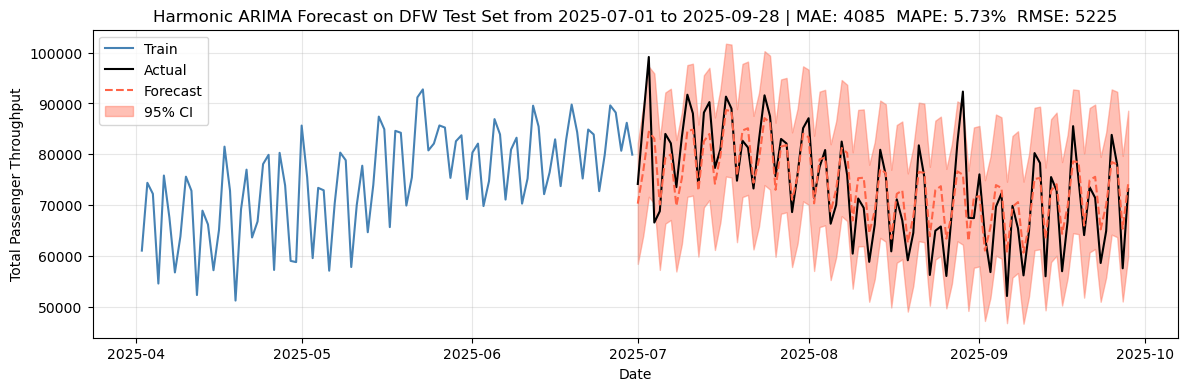

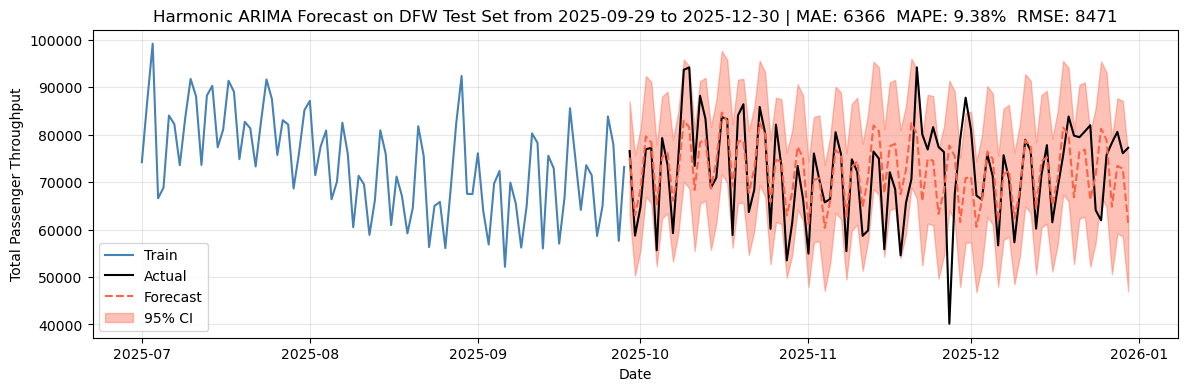

In [63]:
## Fitting the model on the first training set and evaluating on the first test set
harmonic_model.fit(DFW_daily_train1.day, DFW_daily_train1.total_passenger_throughput)
forecasts1, lower_bound1, upper_bound1 = harmonic_model.forecast(DFW_daily_test1.day)

actuals = DFW_daily_test1.total_passenger_throughput
metrics1 = evaluate_forecast(actuals, forecasts1, model_name=f"Final Harmonic ARIMA on Test Set from {DFW_daily_test1.datetime.min().date()} to {DFW_daily_test1.datetime.max().date()}")
print(f"Final Harmonic ARIMA on Test Set from {DFW_daily_test1.datetime.min().date()} to {DFW_daily_test1.datetime.max().date()} - MAE: {metrics1['mae']:.0f}, MAPE: {100*metrics1['mape']:.2f}%, RMSE: {metrics1['rmse']:.0f}")

## Fitting the model on the second training set and evaluating on the second test set
harmonic_model.fit(DFW_daily_train2.day, DFW_daily_train2.total_passenger_throughput)
forecasts2, lower_bound2, upper_bound2 = harmonic_model.forecast(DFW_daily_test2.day)

actuals = DFW_daily_test2.total_passenger_throughput
metrics2 = evaluate_forecast(actuals, forecasts2, model_name=f"Final Harmonic ARIMA on Test Set from {DFW_daily_test2.datetime.min().date()} to {DFW_daily_test2.datetime.max().date()}")
print(f"Final Harmonic ARIMA on Test Set from {DFW_daily_test2.datetime.min().date()} to {DFW_daily_test2.datetime.max().date()} - MAE: {metrics2['mae']:.0f}, MAPE: {100*metrics2['mape']:.2f}%, RMSE: {metrics2['rmse']:.0f}")

## Plot the first test set
plt.figure(figsize=(14,4))
plt.plot(DFW_daily_train1.datetime.iloc[-90:], DFW_daily_train1.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(DFW_daily_test1.datetime, DFW_daily_test1.total_passenger_throughput, label='Actual', color='black')
plt.plot(DFW_daily_test1.datetime, forecasts1, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(DFW_daily_test1.datetime, lower_bound1, upper_bound1, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"Harmonic ARIMA Forecast on DFW Test Set from {DFW_daily_test1.datetime.min().date()} to {DFW_daily_test1.datetime.max().date()} | MAE: {metrics1['mae']:.0f}  MAPE: {100*metrics1['mape']:.2f}%  RMSE: {metrics1['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/harmonic_arima_dfw_daily_test1.png", bbox_inches='tight')
plt.show()

## Plot the second test set
plt.figure(figsize=(14,4))
plt.plot(DFW_daily_train2.datetime.iloc[-90:], DFW_daily_train2.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(DFW_daily_test2.datetime, DFW_daily_test2.total_passenger_throughput, label='Actual', color='black')
plt.plot(DFW_daily_test2.datetime, forecasts2, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(DFW_daily_test2.datetime, lower_bound2, upper_bound2, color='tomato', alpha=0.4,  label='95% CI')
plt.title(f"Harmonic ARIMA Forecast on DFW Test Set from {DFW_daily_test2.datetime.min().date()} to {DFW_daily_test2.datetime.max().date()} | MAE: {metrics2['mae']:.0f}  MAPE: {100*metrics2['mape']:.2f}%  RMSE: {metrics2['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/harmonic_arima_dfw_daily_test2.png", bbox_inches='tight')
plt.show()

### Harmonic ARIMA - Daily Data - DEN

Final Harmonic ARIMA on Test Set from 2025-07-01 to 2025-09-28 - MAE: 4958, MAPE: 7.80%, RMSE: 6860
Final Harmonic ARIMA on Test Set from 2025-09-29 to 2025-12-30 - MAE: 7887, MAPE: 13.94%, RMSE: 10021


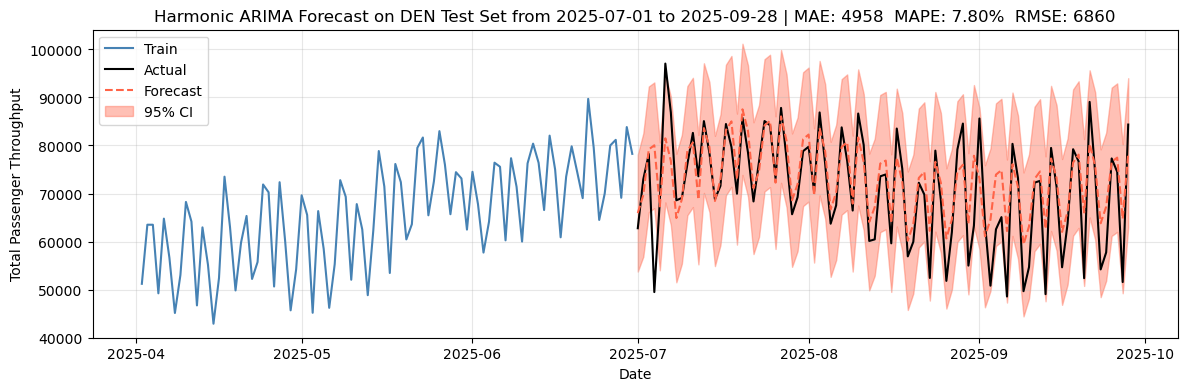

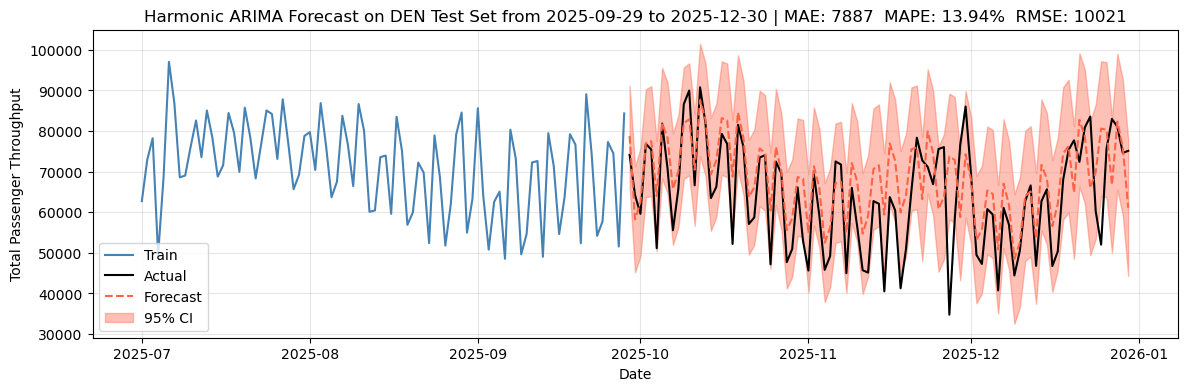

In [64]:
## Fitting the model on the first training set and evaluating on the first test set
harmonic_model.fit(DEN_daily_train1.day, DEN_daily_train1.total_passenger_throughput)
forecasts1, lower_bound1, upper_bound1 = harmonic_model.forecast(DEN_daily_test1.day)

actuals = DEN_daily_test1.total_passenger_throughput
metrics1 = evaluate_forecast(actuals, forecasts1, model_name=f"Final Harmonic ARIMA on Test Set from {DEN_daily_test1.datetime.min().date()} to {DEN_daily_test1.datetime.max().date()}")
print(f"Final Harmonic ARIMA on Test Set from {DEN_daily_test1.datetime.min().date()} to {DEN_daily_test1.datetime.max().date()} - MAE: {metrics1['mae']:.0f}, MAPE: {100*metrics1['mape']:.2f}%, RMSE: {metrics1['rmse']:.0f}")

## Fitting the model on the second training set and evaluating on the second test set
harmonic_model.fit(DEN_daily_train2.day, DEN_daily_train2.total_passenger_throughput)
forecasts2, lower_bound2, upper_bound2 = harmonic_model.forecast(DEN_daily_test2.day)

actuals = DEN_daily_test2.total_passenger_throughput
metrics2 = evaluate_forecast(actuals, forecasts2, model_name=f"Final Harmonic ARIMA on Test Set from {DEN_daily_test2.datetime.min().date()} to {DEN_daily_test2.datetime.max().date()}")
print(f"Final Harmonic ARIMA on Test Set from {DEN_daily_test2.datetime.min().date()} to {DEN_daily_test2.datetime.max().date()} - MAE: {metrics2['mae']:.0f}, MAPE: {100*metrics2['mape']:.2f}%, RMSE: {metrics2['rmse']:.0f}")

## Plot the first test set
plt.figure(figsize=(14,4))
plt.plot(DEN_daily_train1.datetime.iloc[-90:], DEN_daily_train1.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(DEN_daily_test1.datetime, DEN_daily_test1.total_passenger_throughput, label='Actual', color='black')
plt.plot(DEN_daily_test1.datetime, forecasts1, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(DEN_daily_test1.datetime, lower_bound1, upper_bound1, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"Harmonic ARIMA Forecast on DEN Test Set from {DEN_daily_test1.datetime.min().date()} to {DEN_daily_test1.datetime.max().date()} | MAE: {metrics1['mae']:.0f}  MAPE: {100*metrics1['mape']:.2f}%  RMSE: {metrics1['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/harmonic_arima_den_daily_test1.png", bbox_inches='tight')
plt.show()

## Plot the second test set
plt.figure(figsize=(14,4))
plt.plot(DEN_daily_train2.datetime.iloc[-90:], DEN_daily_train2.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(DEN_daily_test2.datetime, DEN_daily_test2.total_passenger_throughput, label='Actual', color='black')
plt.plot(DEN_daily_test2.datetime, forecasts2, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(DEN_daily_test2.datetime, lower_bound2, upper_bound2, color='tomato', alpha=0.4,  label='95% CI')
plt.title(f"Harmonic ARIMA Forecast on DEN Test Set from {DEN_daily_test2.datetime.min().date()} to {DEN_daily_test2.datetime.max().date()} | MAE: {metrics2['mae']:.0f}  MAPE: {100*metrics2['mape']:.2f}%  RMSE: {metrics2['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/harmonic_arima_den_daily_test2.png", bbox_inches='tight')
plt.show()

### Harmonic ARIMA - Daily Data - DTW

Final Harmonic ARIMA on Test Set from 2025-07-01 to 2025-09-28 - MAE: 2648, MAPE: 7.22%, RMSE: 3414
Final Harmonic ARIMA on Test Set from 2025-09-29 to 2025-12-30 - MAE: 3747, MAPE: 10.88%, RMSE: 4802


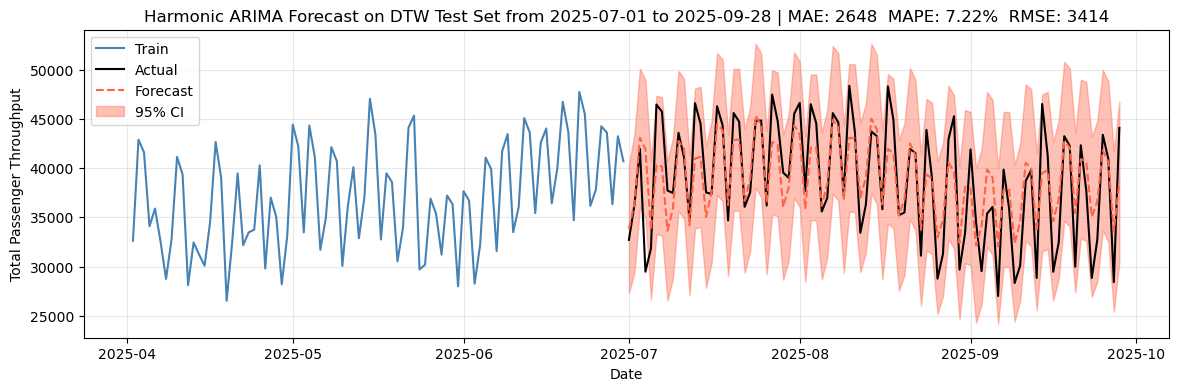

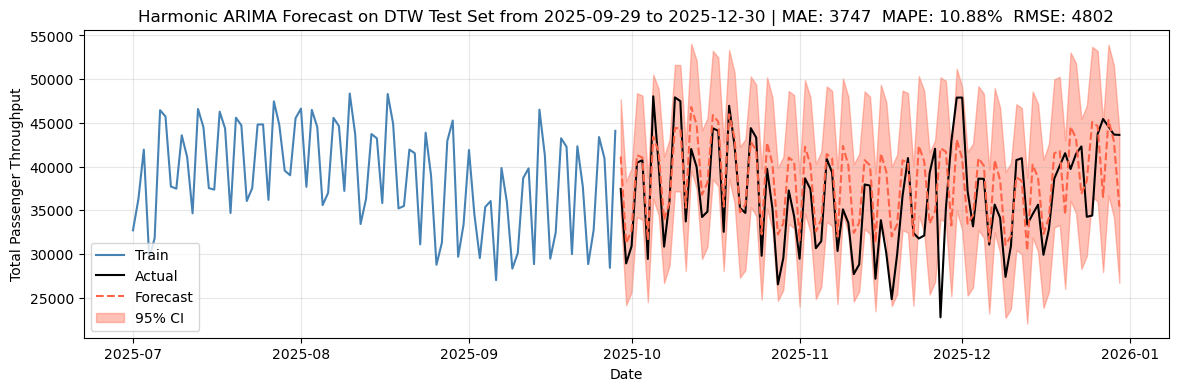

In [65]:
## Fitting the model on the first training set and evaluating on the first test set
harmonic_model.fit(DTW_daily_train1.day, DTW_daily_train1.total_passenger_throughput)
forecasts1, lower_bound1, upper_bound1 = harmonic_model.forecast(DTW_daily_test1.day)

actuals = DTW_daily_test1.total_passenger_throughput
metrics1 = evaluate_forecast(actuals, forecasts1, model_name=f"Final Harmonic ARIMA on Test Set from {DTW_daily_test1.datetime.min().date()} to {DTW_daily_test1.datetime.max().date()}")
print(f"Final Harmonic ARIMA on Test Set from {DTW_daily_test1.datetime.min().date()} to {DTW_daily_test1.datetime.max().date()} - MAE: {metrics1['mae']:.0f}, MAPE: {100*metrics1['mape']:.2f}%, RMSE: {metrics1['rmse']:.0f}")

## Fitting the model on the second training set and evaluating on the second test set
harmonic_model.fit(DTW_daily_train2.day, DTW_daily_train2.total_passenger_throughput)
forecasts2, lower_bound2, upper_bound2 = harmonic_model.forecast(DTW_daily_test2.day)

actuals = DTW_daily_test2.total_passenger_throughput
metrics2 = evaluate_forecast(actuals, forecasts2, model_name=f"Final Harmonic ARIMA on Test Set from {DTW_daily_test2.datetime.min().date()} to {DTW_daily_test2.datetime.max().date()}")
print(f"Final Harmonic ARIMA on Test Set from {DTW_daily_test2.datetime.min().date()} to {DTW_daily_test2.datetime.max().date()} - MAE: {metrics2['mae']:.0f}, MAPE: {100*metrics2['mape']:.2f}%, RMSE: {metrics2['rmse']:.0f}")

## Plot the first test set
plt.figure(figsize=(14,4))
plt.plot(DTW_daily_train1.datetime.iloc[-90:], DTW_daily_train1.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(DTW_daily_test1.datetime, DTW_daily_test1.total_passenger_throughput, label='Actual', color='black')
plt.plot(DTW_daily_test1.datetime, forecasts1, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(DTW_daily_test1.datetime, lower_bound1, upper_bound1, color='tomato', alpha=0.4, label='95% CI')
plt.title(f"Harmonic ARIMA Forecast on DTW Test Set from {DTW_daily_test1.datetime.min().date()} to {DTW_daily_test1.datetime.max().date()} | MAE: {metrics1['mae']:.0f}  MAPE: {100*metrics1['mape']:.2f}%  RMSE: {metrics1['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/harmonic_arima_dtw_daily_test1.png", bbox_inches='tight')
plt.show()

## Plot the second test set
plt.figure(figsize=(14,4))
plt.plot(DTW_daily_train2.datetime.iloc[-90:], DTW_daily_train2.total_passenger_throughput.iloc[-90:], label='Train', color='steelblue')
plt.plot(DTW_daily_test2.datetime, DTW_daily_test2.total_passenger_throughput, label='Actual', color='black')
plt.plot(DTW_daily_test2.datetime, forecasts2, label='Forecast', color='tomato', linestyle='--')
plt.fill_between(DTW_daily_test2.datetime, lower_bound2, upper_bound2, color='tomato', alpha=0.4,  label='95% CI')
plt.title(f"Harmonic ARIMA Forecast on DTW Test Set from {DTW_daily_test2.datetime.min().date()} to {DTW_daily_test2.datetime.max().date()} | MAE: {metrics2['mae']:.0f}  MAPE: {100*metrics2['mape']:.2f}%  RMSE: {metrics2['rmse']:.0f}")
plt.xlabel('Date')
plt.ylabel('Total Passenger Throughput')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("images/harmonic_arima_dtw_daily_test2.png", bbox_inches='tight')
plt.show()

### Baseline Models - Daily Data - ORD

For comparison, let's also look at what happens with the two Baseline models.

In [ ]:
#Naive Seasonal with Drift

nswd_test.fit(ORD_daily_train1['total_passenger_throughput'])
nswd_forecast=nswd_test.forecast(len(ORD_daily_test1))
metrics1 = evaluate_forecast(ORD_daily_test1['total_passenger_throughput'].values, nswd_forecast,
                  model_name="Naive Seasonal With Drift") #error evaluation
print(f"NSWD Forecast on ORD Test Set from {ORD_daily_test1.datetime.min().date()} to {ORD_daily_test1.datetime.max().date()} -  MAE: {metrics1['mae']:.0f}, MAPE: {100*metrics1['mape']:.2f}%, RMSE: {metrics1['rmse']:.0f}")

nswd_test.fit(ORD_daily_train2['total_passenger_throughput'])
nswd_forecast=nswd_test.forecast(len(ORD_daily_test2))
metrics2 = evaluate_forecast(ORD_daily_test2['total_passenger_throughput'].values, nswd_forecast,
                  model_name="Naive Seasonal With Drift") #error evaluation
print(f"NSWD Forecast on ORD Test Set from {ORD_daily_test2.datetime.min().date()} to {ORD_daily_test2.datetime.max().date()} -  MAE: {metrics2['mae']:.0f}, MAPE: {100*metrics2['mape']:.2f}%, RMSE: {metrics2['rmse']:.0f}")


NSWD Forecast on ORD Test Set from 2025-07-01 to 2025-09-28 -  MAE: 11579, MAPE: 12.41%, RMSE: 14443
NSWD Forecast on ORD Test Set from 2025-09-29 to 2025-12-30 -  MAE: 24814, MAPE: 30.91%, RMSE: 28062


In [ ]:
#Triple Exponential Smoothing
es.fit(ORD_daily_train1['total_passenger_throughput'])
es_forecast = es.forecast(len(ORD_daily_test1))  
metrics1 = evaluate_forecast(ORD_daily_test1['total_passenger_throughput'].values, es_forecast,
                  model_name="Triple Exponential Smoothing ") #error evaluation
print(f"TES Forecast on ORD Test Set from {ORD_daily_test1.datetime.min().date()} to {ORD_daily_test1.datetime.max().date()} -  MAE: {metrics1['mae']:.0f}, MAPE: {100*metrics1['mape']:.2f}%, RMSE: {metrics1['rmse']:.0f}")

es.fit(ORD_daily_train2['total_passenger_throughput'])
es_forecast = es.forecast(len(ORD_daily_test2))  
metrics2 = evaluate_forecast(ORD_daily_test2['total_passenger_throughput'].values, es_forecast,
                  model_name="Triple Exponential Smoothing") #error evaluation
print(f"TES Forecast on ORD Test Set from {ORD_daily_test2.datetime.min().date()} to {ORD_daily_test2.datetime.max().date()} -  MAE: {metrics2['mae']:.0f}, MAPE: {100*metrics2['mape']:.2f}%, RMSE: {metrics2['rmse']:.0f}")


TES Forecast on ORD Test Set from 2025-07-01 to 2025-09-28 -  MAE: 10898, MAPE: 11.81%, RMSE: 12173
TES Forecast on ORD Test Set from 2025-09-29 to 2025-12-30 -  MAE: 10072, MAPE: 12.42%, RMSE: 12155
